# Explorador parametrico de recompensas

Este notebook permite observar curvas teoricas de recompensa antes de correr simulaciones largas.

La idea es comparar configuraciones de parametros y escenarios de entrada en una sola pasada:

- `principal_reward`
- `coordination_global_reward`
- `coordination_progress_reward`
- `coordination_debt_penalty`
- `coordination_module_reward`
- `final_reward` sin `extra_rewards`

El notebook no carga resultados historicos. Usa la configuracion real de `config/config_CartPole.yaml` como punto de partida y luego deja cajas editables para probar variantes.

## 0. Entradas globales

Estas variables controlan el contexto general del notebook.

| Variable | Significado | Relacion con la config |
|---|---|---|
| `CONFIG_PATH` | Archivo YAML base desde donde se copian parametros reales. | `config/config_CartPole.yaml` |
| `VAR_OBJS` | Lazos/variables controladas disponibles. | `controller_base.controllers.*.params.name_objective_var` |
| `NAME_OBJECTIVE_VAR_FOCUS` | Lazo que se observa con mas detalle en mapas y cortes. | Debe coincidir con algun `name_objective_var` |
| `N_POINTS` | Resolucion de las curvas teoricas. | No existe en config; solo controla el notebook |
| `EXPORT_FIGURES` | Guarda las figuras en disco si es `True`. | No afecta la simulacion |

In [1]:
from pathlib import Path

CONFIG_PATH = Path("config/config_CartPole.yaml")
VAR_OBJS = ["pendulum_angle", "cart_position"]
NAME_OBJECTIVE_VAR_FOCUS = "pendulum_angle"

N_POINTS = 401
EXPORT_FIGURES = False
FIGURE_OUTPUT_DIR = Path("reward_curve_explorer_figures")

## 0.1 Setup y carga de configuracion

Esta celda no define escenarios. Solo carga el YAML, fija el estilo visual y prepara copias de los bloques reales de configuracion.

In [6]:
import copy
import math

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from IPython.display import display, Markdown


def set_project_plot_style(dpi=140):
    plt.rcParams.update({
        "figure.dpi": dpi,
        "savefig.dpi": dpi,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.constrained_layout.use": True,
    })


def format_axis(ax, title=None, xlabel=None, ylabel=None, zero_line=False):
    if title is not None:
        ax.set_title(title)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)
    if zero_line:
        ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.45)
    return ax


def save_figure(filename):
    if EXPORT_FIGURES:
        FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        plt.savefig(FIGURE_OUTPUT_DIR / filename, bbox_inches="tight")


set_project_plot_style()

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config_main = yaml.safe_load(f)

reward_config = config_main["reward_base"]["reward_config"]
reward_calculation = config_main["reward_base"]["reward_calculation"]

principal_reward_config = copy.deepcopy(reward_calculation["principal_reward"])
coordination_reward_config = copy.deepcopy(reward_calculation["coordination_reward"])
reward_composition_config = copy.deepcopy(reward_config["reward_composition"])

weighted_exponential_params_base = copy.deepcopy(principal_reward_config["weighted_exponential_params"])
coordination_reward_config_base = copy.deepcopy(coordination_reward_config)
block_weights_base = copy.deepcopy(reward_composition_config["block_weights"])

COLORS = {
    "principal": "#1f77b4",
    "coordination": "#009E73",
    "progress": "#0072B2",
    "debt": "#D55E00",
    "module": "#CC79A7",
    "final": "#111111",
    "pendulum_angle": "#0072B2",
    "cart_position": "#E69F00",
}

FEATURE_COLORS = {
    "L_e": "#0072B2",
    "L_edot": "#009E73",
    "L_I": "#CC79A7",
    "L_u": "#D55E00",
    "L_delta_u": "#E69F00",
}

pd.set_option("display.max_columns", 90)
pd.set_option("display.width", 150)

display(Markdown("### Bloques cargados desde config"))
display(pd.DataFrame([
    {"bloque": "principal_reward.method", "valor": principal_reward_config["method"]},
    {"bloque": "principal_reward.normalized_reward_mode", "valor": principal_reward_config["normalized_reward_mode"]},
    {"bloque": "coordination_reward.normalized_reward_mode", "valor": coordination_reward_config["normalized_reward_mode"]},
    {"bloque": "reward_composition.enabled", "valor": reward_composition_config["enabled"]},
    {"bloque": "block_weights.principal_reward", "valor": block_weights_base["principal_reward"]},
    {"bloque": "block_weights.coordination_reward", "valor": block_weights_base["coordination_reward"]},
    {"bloque": "block_weights.extra_rewards", "valor": block_weights_base["extra_rewards"]},
]))

### Bloques cargados desde config

,bloque,valor
0,principal_reward.method,weighted_exponential
1,principal_reward.normalized_reward_mode,True
2,coordination_reward.normalized_reward_mode,True
3,reward_composition.enabled,True
4,block_weights.principal_reward,0.7
5,block_weights.coordination_reward,0.3
6,block_weights.extra_rewards,0.0


## 0.2 Funciones de calculo

No editar esta celda para cambiar parametros. Las cajas editables estan al inicio de cada seccion.

In [7]:
def clip01(values):
    return np.clip(np.asarray(values, dtype=float), 0.0, 1.0)


def scenario_color(index):
    return plt.get_cmap("tab10")(index % 10)


def feature_weight_sum(features):
    return sum(max(0.0, cfg["weight"]) for cfg in features.values())


def effective_feature_weights(features, normalized_reward_mode):
    denom = feature_weight_sum(features) if normalized_reward_mode else 1.0
    return {
        feature: (max(0.0, cfg["weight"]) / denom if normalized_reward_mode else cfg["weight"])
        for feature, cfg in features.items()
    }


def exponential_cost_01(values, scaled, setpoint):
    values = clip01(np.abs(values))
    raw_cost = 1.0 - np.exp(-scaled * ((values - setpoint) ** 2))
    bound_0 = 1.0 - math.exp(-scaled * ((0.0 - setpoint) ** 2))
    bound_1 = 1.0 - math.exp(-scaled * ((1.0 - setpoint) ** 2))
    raw_bound = max(bound_0, bound_1, 1.0e-12)
    return clip01(raw_cost / raw_bound)


def resolve_gate_config(feature_gates, feature_name, name_objective_var):
    gate_cfg = copy.deepcopy(feature_gates.get(feature_name, {}))
    if not gate_cfg.get("enabled", False):
        return None

    per_var = gate_cfg.pop("per_var", {})
    gate_cfg.update(per_var.get(name_objective_var, {}))
    gate_cfg["source"] = gate_cfg.get("source", "L_e_{var_obj}").format(var_obj=name_objective_var)
    gate_cfg.setdefault("type", "exp")
    gate_cfg.setdefault("scaled", gate_cfg.get("strength", 1.0))
    gate_cfg.setdefault("setpoint", gate_cfg.get("x_sp", 0.0))
    gate_cfg.setdefault("use_sqrt", False)
    gate_cfg.setdefault("use_abs", True)
    gate_cfg.setdefault("invert", False)
    gate_cfg.setdefault("min_factor", 0.0)
    gate_cfg.setdefault("max_factor", 1.0)
    return gate_cfg


def compute_gate_factor(values_by_key, gate_cfg):
    if gate_cfg is None:
        sample = next(iter(values_by_key.values()))
        return np.ones_like(sample, dtype=float)

    value = np.asarray(values_by_key[gate_cfg["source"]], dtype=float)
    if gate_cfg["use_abs"]:
        value = np.abs(value)
    if gate_cfg["use_sqrt"]:
        value = np.sqrt(np.maximum(value, 0.0))

    gain = gate_cfg.get("strength", gate_cfg["scaled"])
    setpoint = gate_cfg.get("x_sp", gate_cfg["setpoint"])

    if gate_cfg["type"] == "exp":
        factor = np.exp(-(((value - setpoint) / gain) ** 2)) if gain > 0 else np.zeros_like(value)
    else:
        factor = np.tanh(gain * np.abs(value - setpoint))

    if gate_cfg["invert"]:
        factor = 1.0 - factor

    return np.clip(factor, gate_cfg["min_factor"], gate_cfg["max_factor"])


def build_principal_reward_profile(scenario_name, profile_axis, weighted_exponential_params, normalized_reward_mode):
    name_objective_var = profile_axis["name_objective_var"]
    feature_axis_name = profile_axis["feature_axis_name"]
    feature_axis_values = np.linspace(
        profile_axis["feature_axis_min"],
        profile_axis["feature_axis_max"],
        profile_axis["n_points"],
    )

    features = weighted_exponential_params["features"]
    feature_gates = weighted_exponential_params.get("feature_gates", {})
    fixed_feature_values = profile_axis["fixed_feature_values"]

    values_by_key = {}
    feature_values = {}
    for feature_name in features.keys():
        values = np.full_like(feature_axis_values, fixed_feature_values.get(feature_name, 0.0), dtype=float)
        if feature_name == feature_axis_name:
            values = feature_axis_values.copy()
        feature_values[feature_name] = values
        values_by_key[f"{feature_name}_{name_objective_var}"] = values

    weights = effective_feature_weights(features, normalized_reward_mode)
    frame = pd.DataFrame({
        "scenario_name": scenario_name,
        "feature_axis_value": feature_axis_values,
        feature_axis_name: feature_axis_values,
    })
    principal_reward = np.zeros_like(feature_axis_values, dtype=float)
    principal_cost_01 = np.zeros_like(feature_axis_values, dtype=float)

    for feature_name, feature_cfg in features.items():
        values = feature_values[feature_name]
        gate_cfg = resolve_gate_config(feature_gates, feature_name, name_objective_var)
        gate = compute_gate_factor(values_by_key, gate_cfg)
        cost_01 = exponential_cost_01(values, feature_cfg["scaled"], feature_cfg.get("setpoint", 0.0))
        raw_cost = 1.0 - np.exp(-feature_cfg["scaled"] * ((values - feature_cfg.get("setpoint", 0.0)) ** 2))
        contribution = -weights[feature_name] * gate * (cost_01 if normalized_reward_mode else raw_cost)

        frame[f"value_{feature_name}"] = values
        frame[f"cost_01_{feature_name}"] = cost_01
        frame[f"gate_{feature_name}"] = gate
        frame[f"principal_contribution_{feature_name}"] = contribution
        principal_reward += contribution
        principal_cost_01 += weights[feature_name] * gate * cost_01

    frame["principal_reward"] = principal_reward
    frame["principal_cost_01"] = principal_cost_01
    frame["principal_score_01"] = 1.0 - principal_cost_01
    return frame


def coordination_progress_components(task_progress_delta, coordination_cfg):
    task_progress_delta = np.asarray(task_progress_delta, dtype=float)
    rewardable = np.maximum(0.0, task_progress_delta) if coordination_cfg["progress_positive_only"] else task_progress_delta.copy()
    clip_cfg = coordination_cfg.get("coordination_bonus_clip", {})
    progress_max = clip_cfg.get("progress_max", coordination_cfg["progress_clip_max"])
    if clip_cfg.get("enabled", True):
        rewardable = np.minimum(rewardable, progress_max)
    progress_01 = np.clip(rewardable / progress_max, 0.0, 1.0)
    bonus_total = progress_01 if coordination_cfg["normalized_reward_mode"] else coordination_cfg["global_weight"] * rewardable
    return rewardable, progress_01, bonus_total


def credit_share_from_raw(coordination_credit_raw_by_var, coordination_cfg, var_objs):
    credit_total = sum(coordination_credit_raw_by_var[var_obj] for var_obj in var_objs)
    return {
        var_obj: coordination_credit_raw_by_var[var_obj] / (coordination_cfg["epsilon_credit"] + credit_total)
        for var_obj in var_objs
    }


def error_decay_curve(local_error_abs, coordination_cfg, name_objective_var):
    local_error_decay = coordination_cfg["local_error_decay"]
    threshold = local_error_decay["thresholds"][name_objective_var]
    ratio = np.asarray(local_error_abs, dtype=float) / threshold

    if local_error_decay["method"] == "linear":
        factor = np.maximum(0.0, 1.0 - ratio)
    elif local_error_decay["method"] == "exponential":
        factor = np.exp(-local_error_decay["lambdas"][name_objective_var] * (ratio ** 2))
    else:
        factor = (ratio <= 1.0).astype(float)

    if local_error_decay.get("hard_zero_above_threshold", False):
        factor = np.where(ratio > 1.0, 0.0, factor)
    return np.clip(factor, 0.0, 1.0)


def build_coordination_reward_profile(scenario_name, scenario_inputs, coordination_cfg, var_objs):
    task_progress_delta = np.linspace(
        scenario_inputs["task_progress_delta_min"],
        scenario_inputs["task_progress_delta_max"],
        scenario_inputs["n_points"],
    )
    rewardable, progress_01, bonus_total = coordination_progress_components(task_progress_delta, coordination_cfg)
    credit_share = credit_share_from_raw(scenario_inputs["coordination_credit_raw_by_var"], coordination_cfg, var_objs)

    frame = pd.DataFrame({
        "scenario_name": scenario_name,
        "coordination_task_progress_delta": task_progress_delta,
        "coordination_task_progress_positive": rewardable,
        "coordination_task_progress_01": progress_01,
        "coordination_bonus_total": bonus_total,
    })

    total = np.zeros_like(task_progress_delta, dtype=float)
    for var_obj in var_objs:
        decay = float(error_decay_curve([scenario_inputs["local_error_abs_by_var"][var_obj]], coordination_cfg, var_obj)[0])
        reward = credit_share[var_obj] * bonus_total * decay
        frame[f"coordination_credit_share_{var_obj}"] = credit_share[var_obj]
        frame[f"coordination_error_decay_{var_obj}"] = decay
        frame[f"coordination_global_reward_{var_obj}"] = reward
        total += reward

    frame["coordination_global_reward_total"] = total
    return frame


def resolve_var_param(value, var_obj):
    if isinstance(value, dict):
        return value[var_obj]
    return value


def local_progress_condition(delta, local_progress_cfg, task_progress_delta, name_objective_var, other_local_progress_delta_by_var):
    mode = local_progress_cfg["condition_mode"]
    if mode == "always":
        return np.ones_like(delta, dtype=float)
    if mode == "global_progress_positive":
        return np.full_like(delta, 1.0 if task_progress_delta > 0.0 else 0.0, dtype=float)
    if mode == "all_local_progress_positive":
        other_positive = all(value > 0.0 for key, value in other_local_progress_delta_by_var.items() if key != name_objective_var)
        return ((delta > 0.0) & other_positive).astype(float)
    other_positive = all(value > 0.0 for key, value in other_local_progress_delta_by_var.items() if key != name_objective_var)
    return ((delta > 0.0) & other_positive & (task_progress_delta > 0.0)).astype(float)


def build_local_progress_profile(scenario_name, scenario_inputs, coordination_cfg, var_objs):
    delta = np.linspace(
        scenario_inputs["local_progress_delta_min"],
        scenario_inputs["local_progress_delta_max"],
        scenario_inputs["n_points"],
    )
    local_progress_cfg = coordination_cfg["local_progress"]
    frame = pd.DataFrame({
        "scenario_name": scenario_name,
        "coordination_local_progress_delta": delta,
    })
    total = np.zeros_like(delta, dtype=float)

    for var_obj in var_objs:
        rewardable = np.maximum(0.0, delta) if local_progress_cfg["positive_only"] else delta.copy()
        if local_progress_cfg["clip_enabled"]:
            rewardable = np.minimum(rewardable, local_progress_cfg["clip_max"])
        condition = local_progress_condition(
            delta,
            local_progress_cfg,
            scenario_inputs["coordination_task_progress_delta"],
            var_obj,
            scenario_inputs["other_local_progress_delta_by_var"],
        )
        reward = resolve_var_param(local_progress_cfg["weight"], var_obj) * rewardable * condition
        frame[f"coordination_progress_condition_{var_obj}"] = condition
        frame[f"coordination_progress_reward_{var_obj}"] = reward
        total += reward

    frame["coordination_progress_reward_total"] = total
    return frame


def build_debt_profile(scenario_name, local_potential_values, coordination_cfg, name_objective_var):
    local_debt_cfg = coordination_cfg["local_debt"]
    eta = resolve_var_param(local_debt_cfg["penalty_weight"], name_objective_var)
    debt = 0.0
    rows = []

    for interval_id, coordination_local_potential in enumerate(np.asarray(local_potential_values, dtype=float)):
        debt = local_debt_cfg["persistence"] * debt + coordination_local_potential
        if local_debt_cfg["clip_enabled"]:
            debt = min(debt, local_debt_cfg["clip_max"])
        rows.append({
            "scenario_name": scenario_name,
            "interval_id": interval_id,
            "coordination_local_potential": coordination_local_potential,
            "coordination_debt": debt,
            "coordination_debt_penalty": eta * debt,
        })

    return pd.DataFrame(rows)

In [28]:
# ---------------------------------------------------------------------
# 1.0 Helpers especificos de principal_reward sin redistribucion
# ---------------------------------------------------------------------

PRINCIPAL_FEATURE_ORDER = ["L_e", "L_edot", "L_I", "L_u", "L_delta_u"]


def principal_features(params):
    return [
        feature_name
        for feature_name in PRINCIPAL_FEATURE_ORDER
        if feature_name in params["features"]
    ]


def disable_principal_gates(params):
    params["feature_gates"] = {
        feature_name: {"enabled": False}
        for feature_name in params["features"].keys()
    }
    return params


def set_principal_feature(params, feature_name, weight=None, scaled=None, setpoint=None):
    if feature_name not in params["features"]:
        return params

    if weight is not None:
        params["features"][feature_name]["weight"] = weight
    if scaled is not None:
        params["features"][feature_name]["scaled"] = scaled
    if setpoint is not None:
        params["features"][feature_name]["setpoint"] = setpoint

    return params


def multiply_principal_weight(params, feature_name, factor):
    if feature_name not in params["features"]:
        return params

    params["features"][feature_name]["weight"] *= factor
    return params


def set_principal_gate(
    params,
    feature_name,
    source="L_e_{var_obj}",
    kind="exp",
    strength=0.5,
    x_sp=0.0,
    min_factor=0.0,
    max_factor=1.0,
    invert=False,
    use_abs=True,
    use_sqrt=False,
    per_var=None,
):
    if feature_name not in params["features"]:
        return params

    params.setdefault("feature_gates", {})
    params["feature_gates"][feature_name] = {
        "enabled": True,
        "source": source,
        "type": kind,
        "strength": strength,
        "x_sp": x_sp,
        "scaled": strength,
        "setpoint": x_sp,
        "min_factor": min_factor,
        "max_factor": max_factor,
        "invert": invert,
        "use_abs": use_abs,
        "use_sqrt": use_sqrt,
    }

    if per_var is not None:
        params["feature_gates"][feature_name]["per_var"] = per_var

    return params


def build_values_by_key(feature_values, name_objective_var):
    values_by_key = {}

    for feature_name, values in feature_values.items():
        values_by_key[f"{feature_name}_{name_objective_var}"] = values

    alias_by_feature = {
        "L_e": [
            f"error_{name_objective_var}_mean_squared",
            f"error_{name_objective_var}",
        ],
        "L_edot": [
            f"derivative_error_{name_objective_var}_mean_squared",
            f"derivative_error_{name_objective_var}",
        ],
        "L_I": [
            f"integral_error_{name_objective_var}_mean_squared",
            f"integral_error_{name_objective_var}",
        ],
        "L_u": [
            f"u_alloc_{name_objective_var}_mean_squared",
            f"u_alloc_{name_objective_var}",
        ],
        "L_delta_u": [
            f"delta_u_alloc_{name_objective_var}_mean_squared",
            f"delta_u_alloc_{name_objective_var}",
        ],
    }

    for feature_name, aliases in alias_by_feature.items():
        if feature_name not in feature_values:
            continue

        for alias in aliases:
            values_by_key.setdefault(alias, feature_values[feature_name])

    return values_by_key


def build_principal_reward_profile_no_redistribution(
    scenario_name,
    regime_name,
    profile_axis,
    weighted_exponential_params,
    normalized_reward_mode,
):
    name_objective_var = profile_axis["name_objective_var"]
    feature_axis_name = profile_axis["feature_axis_name"]
    feature_axis_values = np.linspace(
        profile_axis["feature_axis_min"],
        profile_axis["feature_axis_max"],
        profile_axis["n_points"],
    )

    features = weighted_exponential_params["features"]
    feature_gates = weighted_exponential_params.get("feature_gates", {})
    active_features = principal_features(weighted_exponential_params)

    if feature_axis_name not in active_features:
        raise ValueError(f"Feature axis no activa en principal_reward: {feature_axis_name}")

    fixed_feature_values = {
        feature_name: profile_axis["fixed_feature_values"].get(feature_name, 0.0)
        for feature_name in active_features
    }

    feature_values = {}
    for feature_name in active_features:
        values = np.full_like(
            feature_axis_values,
            fixed_feature_values.get(feature_name, 0.0),
            dtype=float,
        )
        if feature_name == feature_axis_name:
            values = feature_axis_values.copy()
        feature_values[feature_name] = values

    values_by_key = build_values_by_key(feature_values, name_objective_var)
    weights = effective_feature_weights(features, normalized_reward_mode)

    frame = pd.DataFrame({
        "scenario_name": scenario_name,
        "regime_name": regime_name,
        "name_objective_var": name_objective_var,
        "feature_axis_name": feature_axis_name,
        "feature_axis_value": feature_axis_values,
        feature_axis_name: feature_axis_values,
    })

    principal_reward = np.zeros_like(feature_axis_values, dtype=float)
    principal_cost_01 = np.zeros_like(feature_axis_values, dtype=float)
    effective_weight_sum = np.zeros_like(feature_axis_values, dtype=float)
    residual_weight_sum = np.zeros_like(feature_axis_values, dtype=float)

    for feature_name in active_features:
        cfg = features[feature_name]
        values = feature_values[feature_name]

        gate_cfg = resolve_gate_config(feature_gates, feature_name, name_objective_var)

        if gate_cfg is not None and gate_cfg["source"] not in values_by_key:
            gate = np.ones_like(feature_axis_values, dtype=float)
        else:
            gate = compute_gate_factor(values_by_key, gate_cfg)

        scaled = cfg.get("scaled", 1.0)
        setpoint = cfg.get("setpoint", 0.0)

        cost_01 = exponential_cost_01(values, scaled, setpoint)
        raw_cost = 1.0 - np.exp(-scaled * ((values - setpoint) ** 2))

        base_weight = weights[feature_name]
        effective_weight = base_weight * gate
        residual_weight = base_weight - effective_weight

        reward_cost = cost_01 if normalized_reward_mode else raw_cost
        contribution = -effective_weight * reward_cost

        frame[f"value_{feature_name}"] = values
        frame[f"cost_01_{feature_name}"] = cost_01
        frame[f"gate_{feature_name}"] = gate
        frame[f"base_weight_{feature_name}"] = base_weight
        frame[f"effective_weight_{feature_name}"] = effective_weight
        frame[f"residual_weight_{feature_name}"] = residual_weight
        frame[f"principal_contribution_{feature_name}"] = contribution

        principal_reward += contribution
        principal_cost_01 += effective_weight * cost_01
        effective_weight_sum += effective_weight
        residual_weight_sum += residual_weight

    frame["principal_reward"] = principal_reward
    frame["principal_loop_reward"] = principal_reward
    frame["principal_cost_01"] = principal_cost_01
    frame["principal_loop_cost_01"] = principal_cost_01
    frame["principal_score_01"] = 1.0 - principal_cost_01
    frame["principal_effective_weight_sum"] = effective_weight_sum
    frame["principal_residual_weight_sum"] = residual_weight_sum

    return frame

In [29]:
# ---------------------------------------------------------------------
# 1.1 Parametros editables de principal_reward con gates
# ---------------------------------------------------------------------

SECTION_1_FEATURES = principal_features(weighted_exponential_params_base)
SECTION_1_VAR_OBJS = VAR_OBJS
SECTION_1_AXIS_FEATURES = SECTION_1_FEATURES
SECTION_1_N_POINTS = N_POINTS


def regime_values(**values):
    return {
        feature_name: float(values.get(feature_name, 0.0))
        for feature_name in SECTION_1_FEATURES
    }


principal_physical_regimes = {
    "equilibrio_fino": regime_values(
        L_e=0.03,
        L_edot=0.03,
        L_I=0.08,
        L_u=0.04,
        L_delta_u=0.03,
    ),
    "captura_transitoria": regime_values(
        L_e=0.55,
        L_edot=0.45,
        L_I=0.08,
        L_u=0.45,
        L_delta_u=0.30,
    ),
    "asentamiento_con_memoria": regime_values(
        L_e=0.20,
        L_edot=0.10,
        L_I=0.35,
        L_u=0.22,
        L_delta_u=0.14,
    ),
    "estres_actuador": regime_values(
        L_e=0.28,
        L_edot=0.35,
        L_I=0.12,
        L_u=0.85,
        L_delta_u=0.80,
    ),
    "sobreimpulso_rapido": regime_values(
        L_e=0.15,
        L_edot=0.75,
        L_I=0.12,
        L_u=0.50,
        L_delta_u=0.45,
    ),
}


weighted_exponential_params_by_scenario = {}

# 0) Referencia: misma recompensa, sin gates.
scenario = copy.deepcopy(weighted_exponential_params_base)
disable_principal_gates(scenario)
weighted_exponential_params_by_scenario["sin_gates_referencia"] = scenario

# 1) Config real del YAML.
weighted_exponential_params_by_scenario["base_config"] = copy.deepcopy(
    weighted_exponential_params_base
)

# 2) Gates suaves: reducen esfuerzo/control progresivamente cuando el error crece.
scenario = copy.deepcopy(weighted_exponential_params_base)
disable_principal_gates(scenario)
set_principal_gate(scenario, "L_edot", source="L_e_{var_obj}", strength=0.75, min_factor=0.10)
set_principal_gate(scenario, "L_I", source="L_e_{var_obj}", strength=0.45, min_factor=0.00)
set_principal_gate(scenario, "L_u", source="L_e_{var_obj}", strength=0.70, min_factor=0.15)
set_principal_gate(scenario, "L_delta_u", source="L_e_{var_obj}", strength=0.65, min_factor=0.15)
weighted_exponential_params_by_scenario["gates_suaves"] = scenario

# 3) Gates agresivas: esfuerzo y suavidad casi desaparecen durante captura.
scenario = copy.deepcopy(weighted_exponential_params_base)
disable_principal_gates(scenario)
set_principal_gate(scenario, "L_edot", source="L_e_{var_obj}", strength=0.35, min_factor=0.00)
set_principal_gate(scenario, "L_I", source="L_e_{var_obj}", strength=0.25, min_factor=0.00)
set_principal_gate(scenario, "L_u", source="L_e_{var_obj}", strength=0.25, min_factor=0.00)
set_principal_gate(scenario, "L_delta_u", source="L_e_{var_obj}", strength=0.30, min_factor=0.00)
weighted_exponential_params_by_scenario["gates_agresivas"] = scenario

# 4) Gates con piso: ninguna penalizacion desaparece completamente.
scenario = copy.deepcopy(weighted_exponential_params_base)
disable_principal_gates(scenario)
set_principal_gate(scenario, "L_edot", source="L_e_{var_obj}", strength=0.45, min_factor=0.25)
set_principal_gate(scenario, "L_I", source="L_e_{var_obj}", strength=0.35, min_factor=0.15)
set_principal_gate(scenario, "L_u", source="L_e_{var_obj}", strength=0.35, min_factor=0.25)
set_principal_gate(scenario, "L_delta_u", source="L_e_{var_obj}", strength=0.35, min_factor=0.25)
weighted_exponential_params_by_scenario["gates_piso_25"] = scenario

# 5) Precision cerca del setpoint: mas sensibilidad a tracking y damping.
scenario = copy.deepcopy(weighted_exponential_params_base)
disable_principal_gates(scenario)
multiply_principal_weight(scenario, "L_e", 1.25)
multiply_principal_weight(scenario, "L_edot", 1.15)
multiply_principal_weight(scenario, "L_u", 0.85)
set_principal_feature(scenario, "L_e", scaled=8.0)
set_principal_feature(scenario, "L_edot", scaled=6.0)
set_principal_gate(scenario, "L_edot", source="L_e_{var_obj}", strength=0.60, min_factor=0.20)
set_principal_gate(scenario, "L_I", source="L_e_{var_obj}", strength=0.35, min_factor=0.10)
set_principal_gate(scenario, "L_u", source="L_e_{var_obj}", strength=0.45, min_factor=0.20)
set_principal_gate(scenario, "L_delta_u", source="L_e_{var_obj}", strength=0.45, min_factor=0.20)
weighted_exponential_params_by_scenario["precision_setpoint"] = scenario

# 6) Control suave: mas costo a esfuerzo/suavidad, pero gateado para no bloquear captura.
scenario = copy.deepcopy(weighted_exponential_params_base)
disable_principal_gates(scenario)
multiply_principal_weight(scenario, "L_u", 1.25)
multiply_principal_weight(scenario, "L_delta_u", 1.50)
set_principal_gate(scenario, "L_edot", source="L_e_{var_obj}", strength=0.70, min_factor=0.15)
set_principal_gate(scenario, "L_I", source="L_e_{var_obj}", strength=0.45, min_factor=0.10)
set_principal_gate(scenario, "L_u", source="L_e_{var_obj}", strength=0.60, min_factor=0.25)
set_principal_gate(scenario, "L_delta_u", source="L_e_{var_obj}", strength=0.55, min_factor=0.25)
weighted_exponential_params_by_scenario["control_suave"] = scenario


SECTION_1_SCENARIOS_TO_SHOW = [
    "sin_gates_referencia",
    "base_config",
    "gates_suaves",
    "gates_agresivas",
    "gates_piso_25",
    "precision_setpoint",
    "control_suave",
]

In [30]:
# ---------------------------------------------------------------------
# 1.2 Construccion de perfiles por escenario, regimen, lazo y feature
# ---------------------------------------------------------------------

principal_profile_rows = []

for scenario_name in SECTION_1_SCENARIOS_TO_SHOW:
    params = weighted_exponential_params_by_scenario[scenario_name]

    for regime_name, fixed_feature_values in principal_physical_regimes.items():
        for name_objective_var in SECTION_1_VAR_OBJS:
            for feature_axis_name in SECTION_1_AXIS_FEATURES:
                profile_axis = {
                    "name_objective_var": name_objective_var,
                    "feature_axis_name": feature_axis_name,
                    "feature_axis_min": 0.0,
                    "feature_axis_max": 1.0,
                    "n_points": SECTION_1_N_POINTS,
                    "fixed_feature_values": fixed_feature_values,
                }

                principal_profile_rows.append(
                    build_principal_reward_profile_no_redistribution(
                        scenario_name=scenario_name,
                        regime_name=regime_name,
                        profile_axis=profile_axis,
                        weighted_exponential_params=params,
                        normalized_reward_mode=principal_reward_config["normalized_reward_mode"],
                    )
                )

principal_profile_df = pd.concat(principal_profile_rows, ignore_index=True)

display(Markdown("### Seccion 1 - Perfiles generados"))
display(pd.DataFrame([
    {"item": "features activas", "valor": ", ".join(SECTION_1_FEATURES)},
    {"item": "lazos", "valor": ", ".join(SECTION_1_VAR_OBJS)},
    {"item": "regimenes fisicos", "valor": ", ".join(principal_physical_regimes.keys())},
    {"item": "escenarios", "valor": ", ".join(SECTION_1_SCENARIOS_TO_SHOW)},
    {"item": "redistribucion", "valor": "OFF"},
    {"item": "n_filas", "valor": len(principal_profile_df)},
]))

display(
    principal_profile_df
    .groupby(["scenario_name", "regime_name", "name_objective_var", "feature_axis_name"], sort=False)
    .agg(
        area_cost=("principal_loop_cost_01", lambda s: np.trapz(s.to_numpy(), dx=1.0 / max(len(s) - 1, 1))),
        max_cost=("principal_loop_cost_01", "max"),
        min_score=("principal_score_01", "min"),
        max_residual_weight=("principal_residual_weight_sum", "max"),
        min_effective_weight=("principal_effective_weight_sum", "min"),
    )
    .reset_index()
    .round(5)
    .head(30)
)

### Seccion 1 - Perfiles generados

,item,valor
0,features activas,"L_e, L_edot, L_I, L_u"
1,lazos,"pendulum_angle, cart_position"
2,regimenes fisicos,"equilibrio_fino, captura_transitoria, asentami..."
3,escenarios,"sin_gates_referencia, base_config, gates_suave..."
4,redistribucion,OFF
5,n_filas,112280


,scenario_name,regime_name,name_objective_var,feature_axis_name,area_cost,max_cost,min_score,max_residual_weight,min_effective_weight
0,sin_gates_referencia,equilibrio_fino,pendulum_angle,L_e,0.39631,0.65086,0.34914,0.0,1.0
1,sin_gates_referencia,equilibrio_fino,pendulum_angle,L_edot,0.15135,0.30306,0.69694,0.0,1.0
2,sin_gates_referencia,equilibrio_fino,pendulum_angle,L_I,0.00380,0.00380,0.99620,0.0,1.0
3,sin_gates_referencia,equilibrio_fino,pendulum_angle,L_u,0.02370,0.05367,0.94633,0.0,1.0
4,sin_gates_referencia,equilibrio_fino,cart_position,L_e,0.39631,0.65086,0.34914,0.0,1.0
5,sin_gates_referencia,equilibrio_fino,cart_position,L_edot,0.15135,0.30306,0.69694,0.0,1.0
6,sin_gates_referencia,equilibrio_fino,cart_position,L_I,0.00380,0.00380,0.99620,0.0,1.0
7,sin_gates_referencia,equilibrio_fino,cart_position,L_u,0.02370,0.05367,0.94633,0.0,1.0
8,sin_gates_referencia,captura_transitoria,pendulum_angle,L_e,0.53978,0.79433,0.20567,0.0,1.0
9,sin_gates_referencia,captura_transitoria,pendulum_angle,L_edot,0.67299,0.82470,0.17530,0.0,1.0


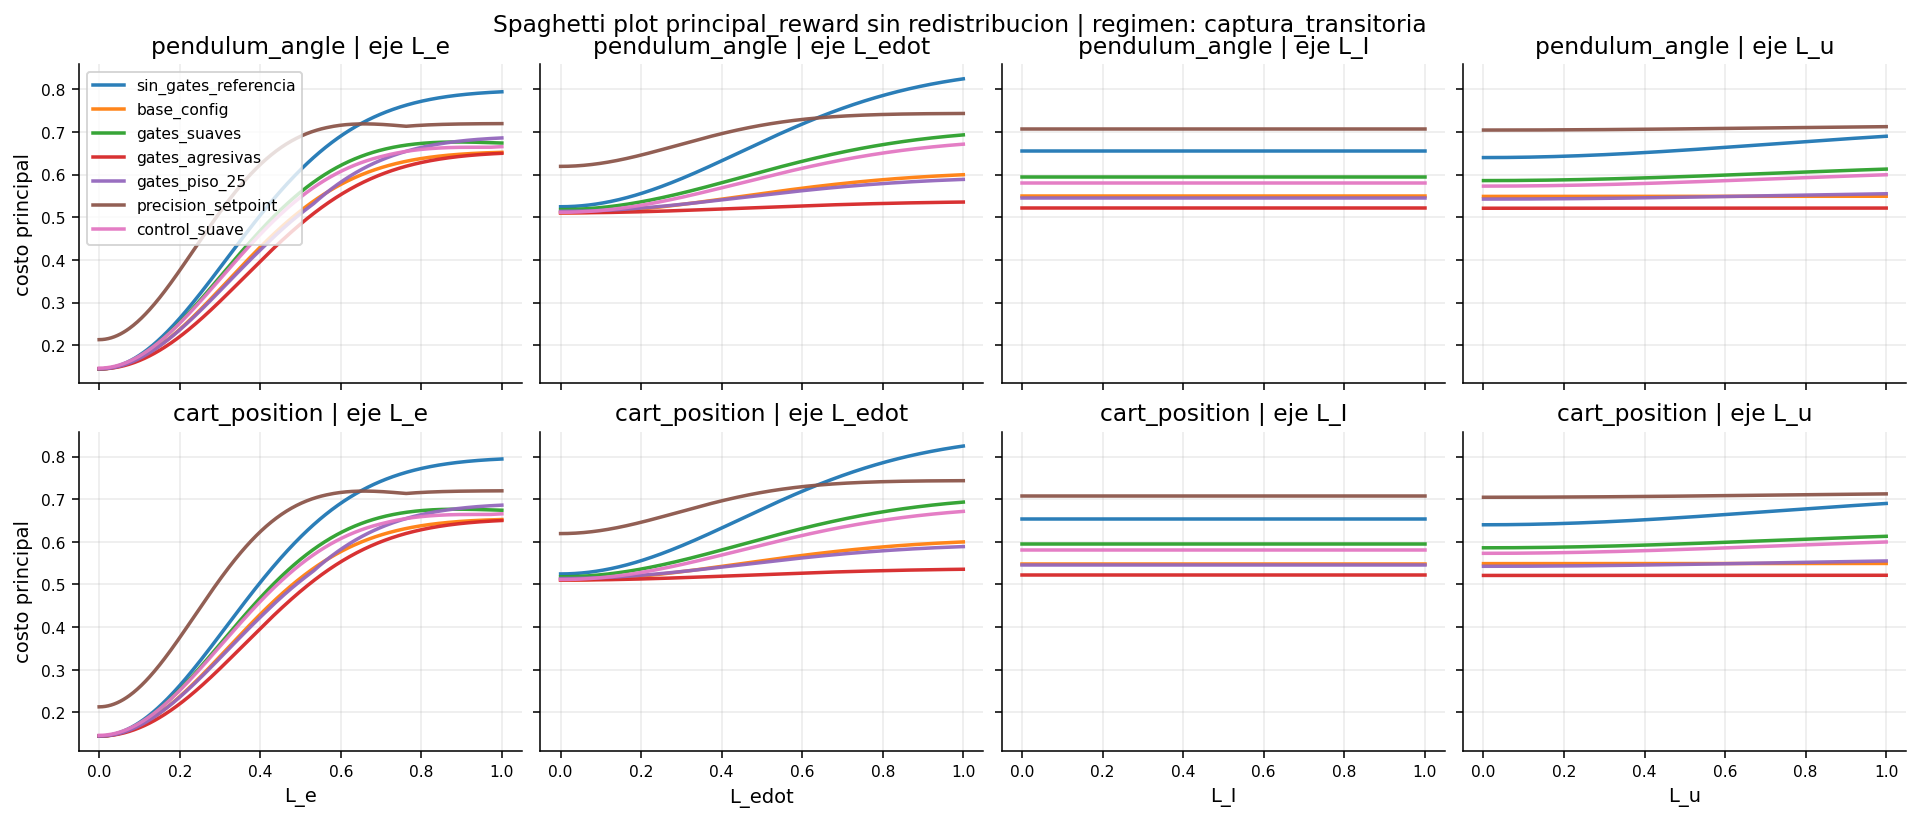

In [32]:
# ---------------------------------------------------------------------
# 1.3 Spaghetti plot constitutivo de principal_reward
# ---------------------------------------------------------------------

SECTION_1_PLOT_REGIME = "captura_transitoria"
SECTION_1_PLOT_Y = "principal_loop_cost_01"   # usar costo positivo para leer severidad
SECTION_1_SHARE_Y = True

plot_df = principal_profile_df.loc[
    principal_profile_df["regime_name"].eq(SECTION_1_PLOT_REGIME)
    & principal_profile_df["scenario_name"].isin(SECTION_1_SCENARIOS_TO_SHOW)
].copy()

n_rows = len(SECTION_1_VAR_OBJS)
n_cols = len(SECTION_1_AXIS_FEATURES)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.4 * n_cols, 2.8 * n_rows),
    sharex=True,
    sharey=SECTION_1_SHARE_Y,
)

axes = np.asarray(axes).reshape(n_rows, n_cols)

for row_idx, name_objective_var in enumerate(SECTION_1_VAR_OBJS):
    for col_idx, feature_axis_name in enumerate(SECTION_1_AXIS_FEATURES):
        ax = axes[row_idx, col_idx]

        frame_axis = plot_df.loc[
            plot_df["name_objective_var"].eq(name_objective_var)
            & plot_df["feature_axis_name"].eq(feature_axis_name)
        ]

        for scenario_idx, scenario_name in enumerate(SECTION_1_SCENARIOS_TO_SHOW):
            frame = frame_axis.loc[frame_axis["scenario_name"].eq(scenario_name)]
            if frame.empty:
                continue

            ax.plot(
                frame["feature_axis_value"],
                frame[SECTION_1_PLOT_Y],
                label=scenario_name if row_idx == 0 and col_idx == 0 else None,
                color=scenario_color(scenario_idx),
                linewidth=1.8,
                alpha=0.95,
            )

        format_axis(
            ax,
            title=f"{name_objective_var} | eje {feature_axis_name}",
            xlabel=feature_axis_name if row_idx == n_rows - 1 else None,
            ylabel="costo principal" if col_idx == 0 else None,
            zero_line=False,
        )

fig.suptitle(
    f"Spaghetti plot principal_reward sin redistribucion | regimen: {SECTION_1_PLOT_REGIME}",
    y=1.02,
)

axes[0, 0].legend(loc="upper left", ncol=1)
save_figure(f"fig_01_principal_spaghetti_{SECTION_1_PLOT_REGIME}.png")
plt.show()

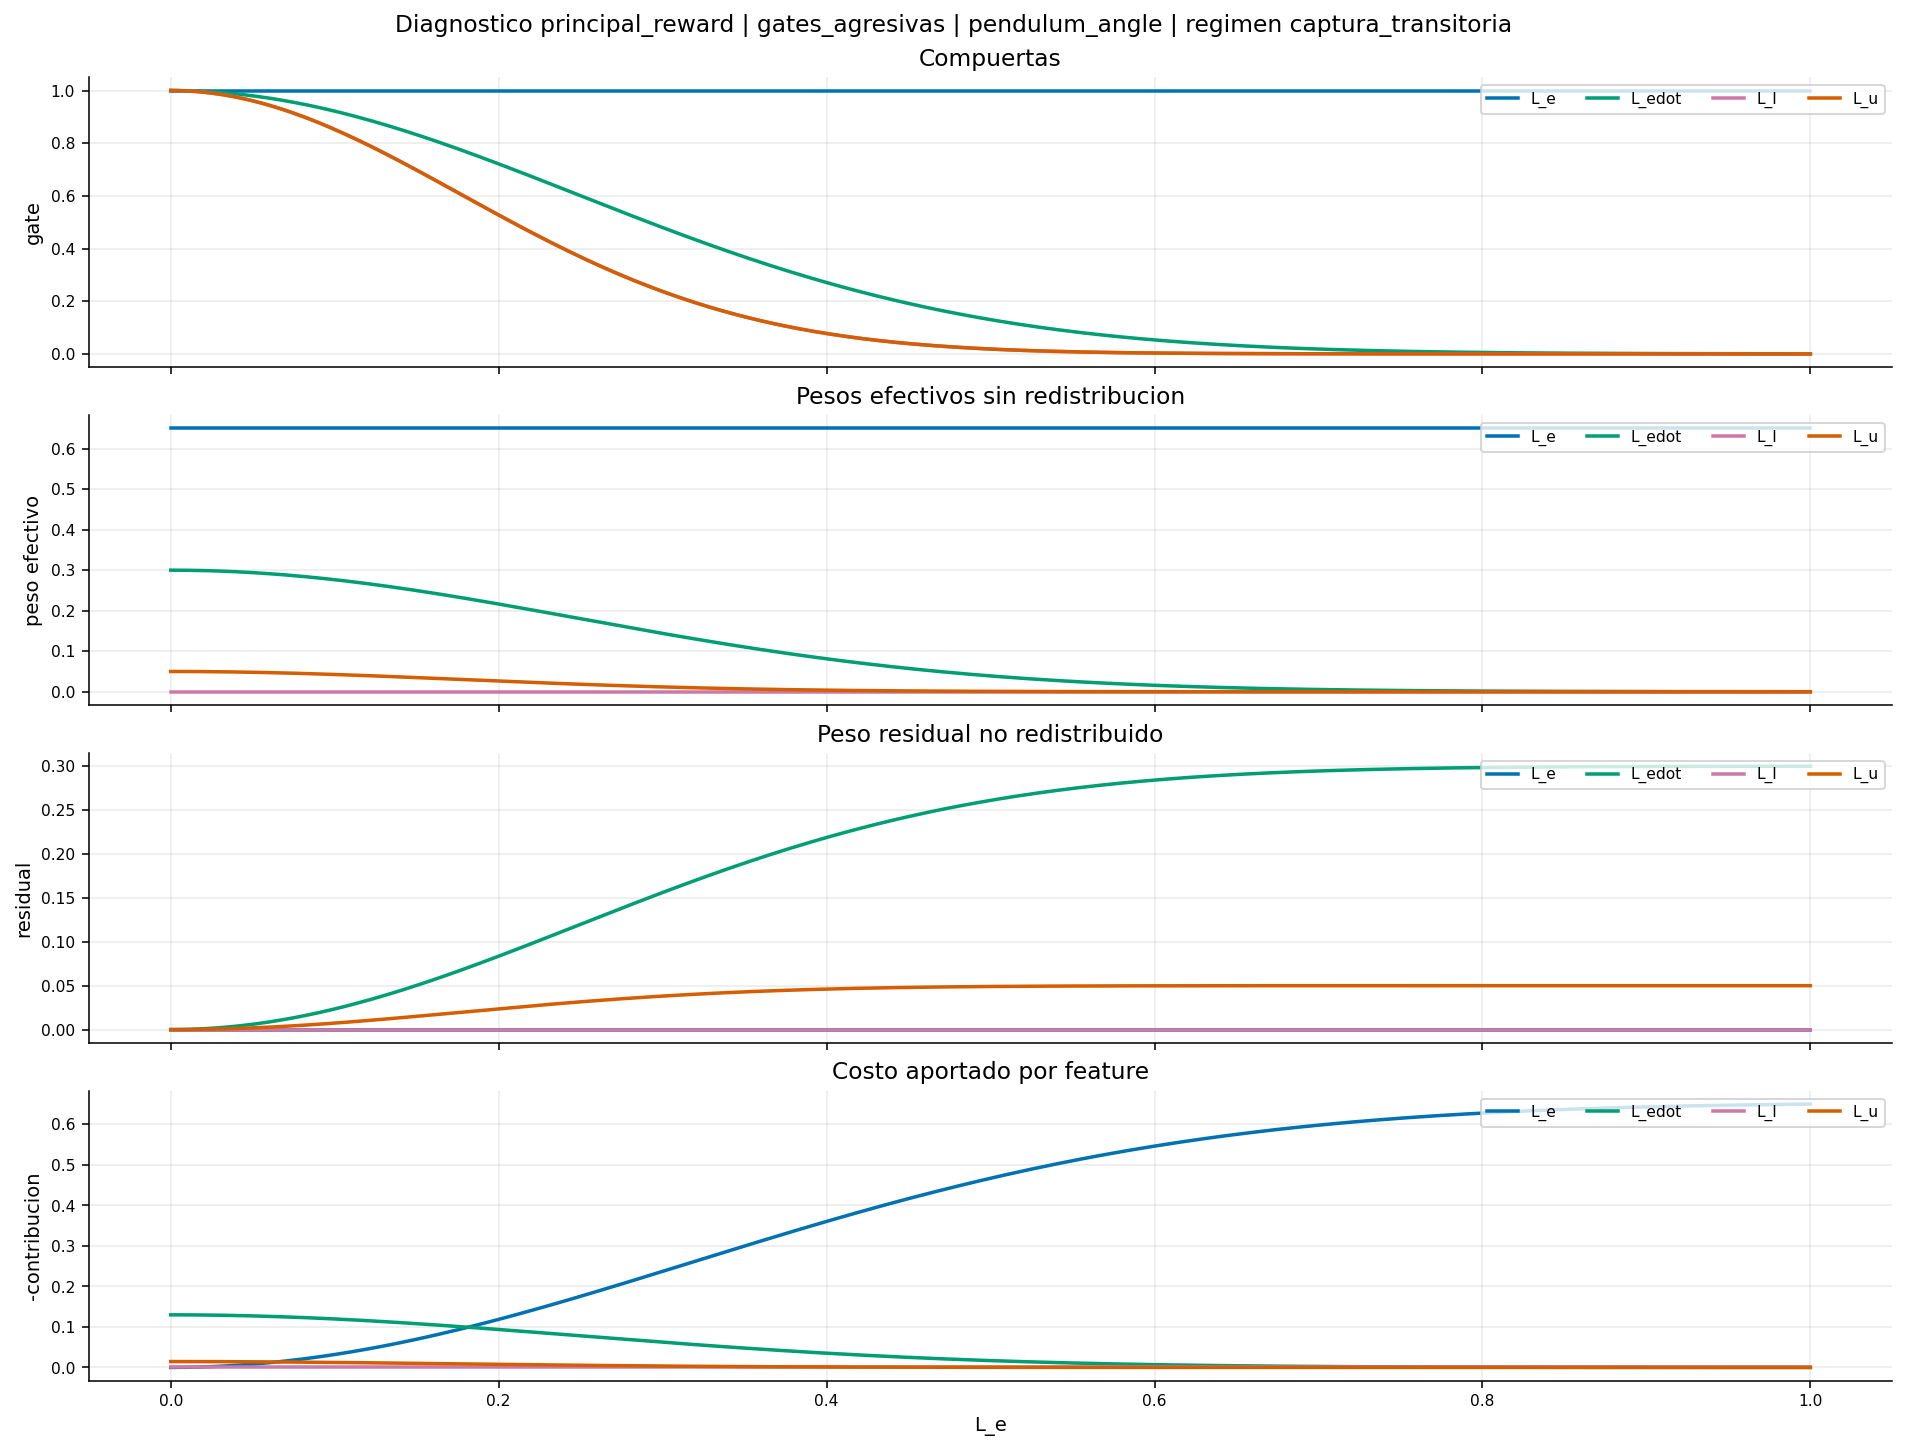

In [33]:
# ---------------------------------------------------------------------
# 1.4 Diagnostico interno: gate, peso efectivo y contribucion
# ---------------------------------------------------------------------

SECTION_1_DIAGNOSTIC_REGIME = "captura_transitoria"
SECTION_1_DIAGNOSTIC_VAR = NAME_OBJECTIVE_VAR_FOCUS
SECTION_1_DIAGNOSTIC_AXIS = "L_e"
SECTION_1_DIAGNOSTIC_SCENARIO = "gates_agresivas"

diag_df = principal_profile_df.loc[
    principal_profile_df["scenario_name"].eq(SECTION_1_DIAGNOSTIC_SCENARIO)
    & principal_profile_df["regime_name"].eq(SECTION_1_DIAGNOSTIC_REGIME)
    & principal_profile_df["name_objective_var"].eq(SECTION_1_DIAGNOSTIC_VAR)
    & principal_profile_df["feature_axis_name"].eq(SECTION_1_DIAGNOSTIC_AXIS)
].copy()

fig, axes = plt.subplots(4, 1, figsize=(13.5, 10.0), sharex=True)

for feature_name in SECTION_1_FEATURES:
    color = FEATURE_COLORS.get(feature_name)

    axes[0].plot(
        diag_df["feature_axis_value"],
        diag_df[f"gate_{feature_name}"],
        label=feature_name,
        color=color,
        linewidth=1.8,
    )

    axes[1].plot(
        diag_df["feature_axis_value"],
        diag_df[f"effective_weight_{feature_name}"],
        label=feature_name,
        color=color,
        linewidth=1.8,
    )

    axes[2].plot(
        diag_df["feature_axis_value"],
        diag_df[f"residual_weight_{feature_name}"],
        label=feature_name,
        color=color,
        linewidth=1.8,
    )

    axes[3].plot(
        diag_df["feature_axis_value"],
        -diag_df[f"principal_contribution_{feature_name}"],
        label=feature_name,
        color=color,
        linewidth=1.8,
    )

format_axis(axes[0], "Compuertas", ylabel="gate")
format_axis(axes[1], "Pesos efectivos sin redistribucion", ylabel="peso efectivo")
format_axis(axes[2], "Peso residual no redistribuido", ylabel="residual")
format_axis(axes[3], "Costo aportado por feature", xlabel=SECTION_1_DIAGNOSTIC_AXIS, ylabel="-contribucion")

for ax in axes:
    ax.legend(ncol=min(5, len(SECTION_1_FEATURES)), loc="upper right")

fig.suptitle(
    f"Diagnostico principal_reward | {SECTION_1_DIAGNOSTIC_SCENARIO} | "
    f"{SECTION_1_DIAGNOSTIC_VAR} | regimen {SECTION_1_DIAGNOSTIC_REGIME}",
    y=1.02,
)

save_figure("fig_01b_principal_gate_diagnostic.png")
plt.show()

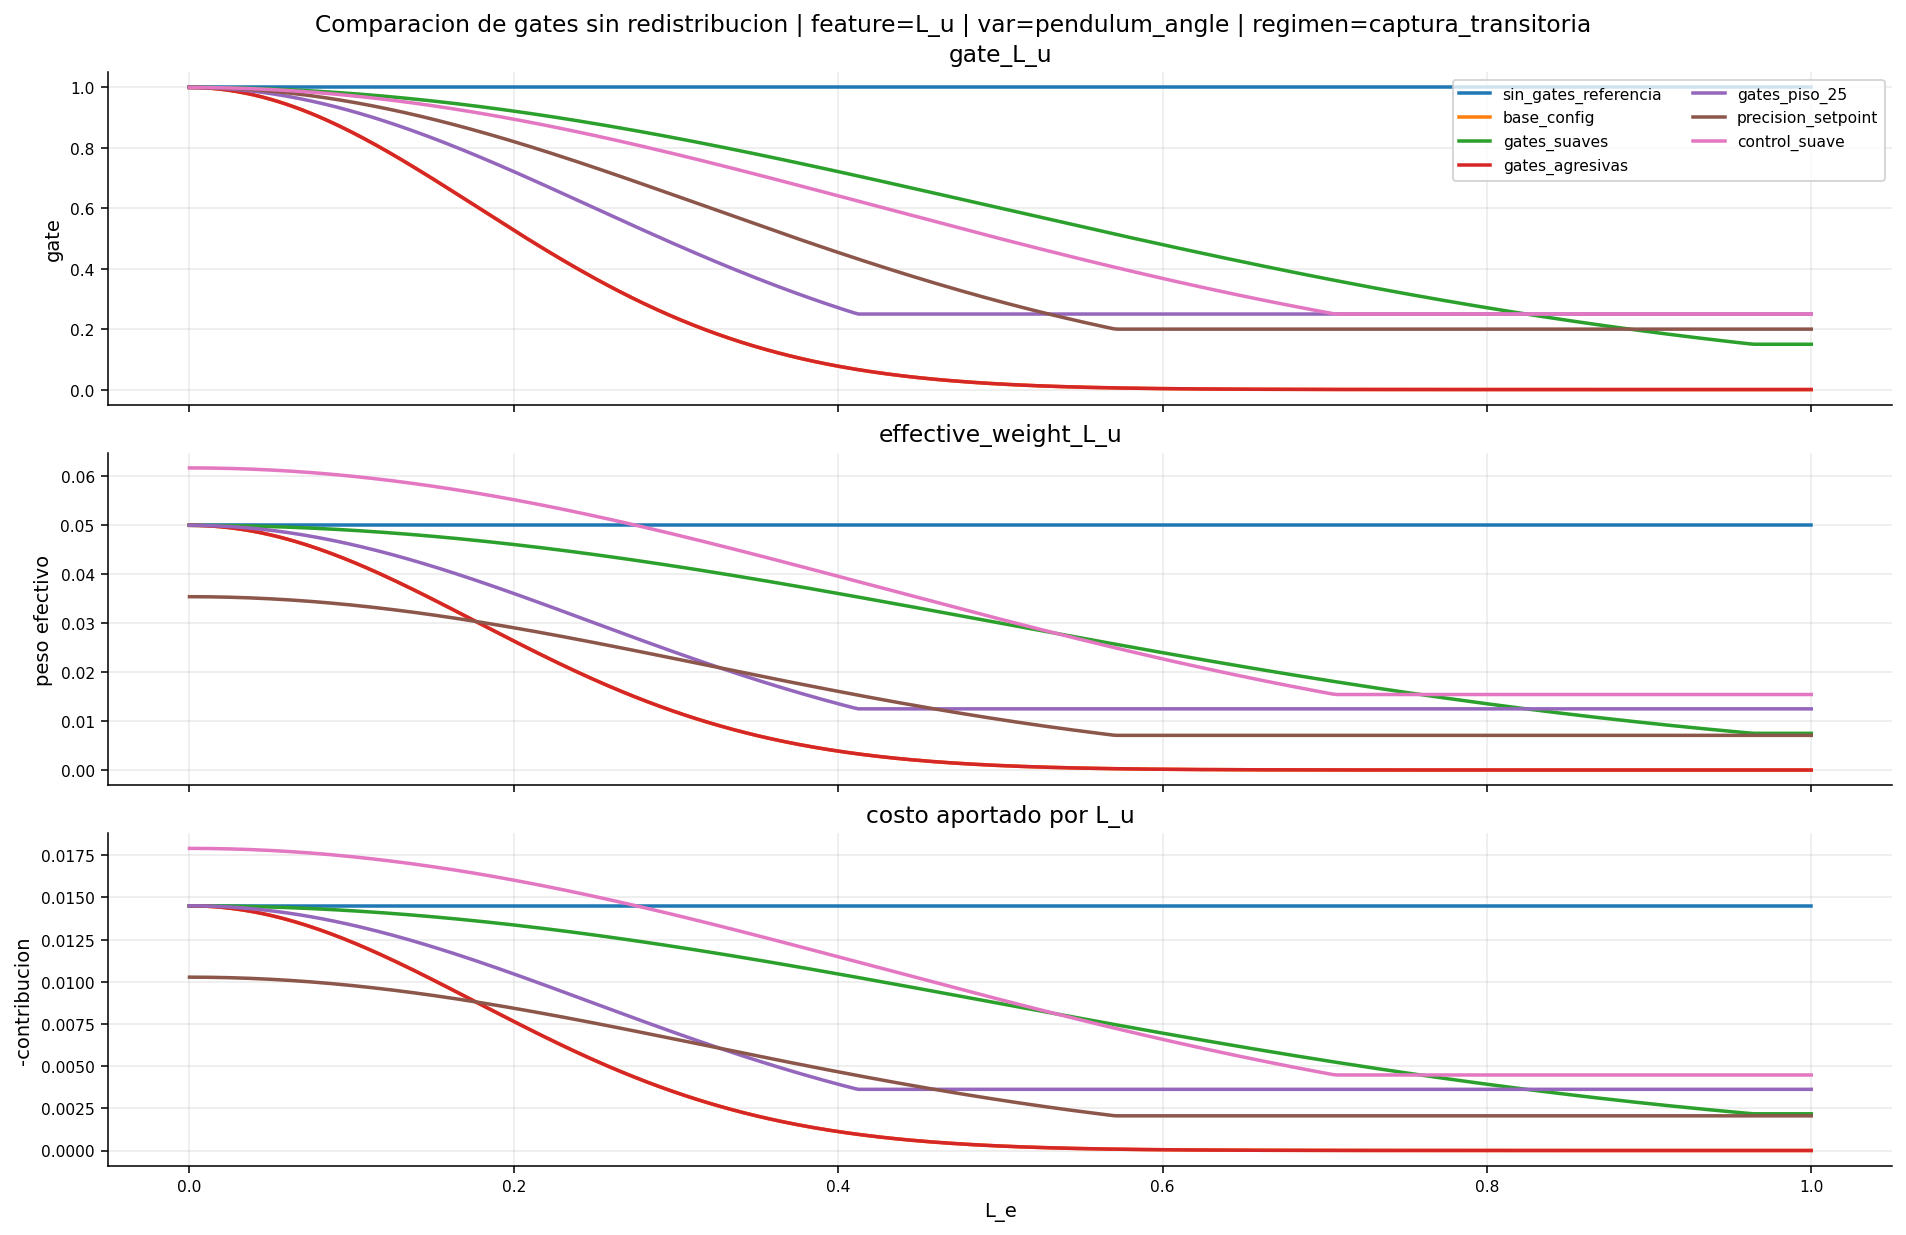

In [34]:
# ---------------------------------------------------------------------
# 1.5 Comparacion directa de una feature gateada entre escenarios
# ---------------------------------------------------------------------

SECTION_1_GATE_COMPARE_FEATURE = "L_u"
SECTION_1_GATE_COMPARE_AXIS = "L_e"
SECTION_1_GATE_COMPARE_VAR = NAME_OBJECTIVE_VAR_FOCUS
SECTION_1_GATE_COMPARE_REGIME = "captura_transitoria"

compare_df = principal_profile_df.loc[
    principal_profile_df["regime_name"].eq(SECTION_1_GATE_COMPARE_REGIME)
    & principal_profile_df["name_objective_var"].eq(SECTION_1_GATE_COMPARE_VAR)
    & principal_profile_df["feature_axis_name"].eq(SECTION_1_GATE_COMPARE_AXIS)
    & principal_profile_df["scenario_name"].isin(SECTION_1_SCENARIOS_TO_SHOW)
].copy()

fig, axes = plt.subplots(3, 1, figsize=(13.5, 8.5), sharex=True)

for scenario_idx, scenario_name in enumerate(SECTION_1_SCENARIOS_TO_SHOW):
    frame = compare_df.loc[compare_df["scenario_name"].eq(scenario_name)]
    if frame.empty:
        continue

    color = scenario_color(scenario_idx)

    axes[0].plot(
        frame["feature_axis_value"],
        frame[f"gate_{SECTION_1_GATE_COMPARE_FEATURE}"],
        label=scenario_name,
        color=color,
        linewidth=1.8,
    )

    axes[1].plot(
        frame["feature_axis_value"],
        frame[f"effective_weight_{SECTION_1_GATE_COMPARE_FEATURE}"],
        label=scenario_name,
        color=color,
        linewidth=1.8,
    )

    axes[2].plot(
        frame["feature_axis_value"],
        -frame[f"principal_contribution_{SECTION_1_GATE_COMPARE_FEATURE}"],
        label=scenario_name,
        color=color,
        linewidth=1.8,
    )

format_axis(axes[0], f"gate_{SECTION_1_GATE_COMPARE_FEATURE}", ylabel="gate")
format_axis(axes[1], f"effective_weight_{SECTION_1_GATE_COMPARE_FEATURE}", ylabel="peso efectivo")
format_axis(axes[2], f"costo aportado por {SECTION_1_GATE_COMPARE_FEATURE}", xlabel=SECTION_1_GATE_COMPARE_AXIS, ylabel="-contribucion")

axes[0].legend(loc="upper right", ncol=2)

fig.suptitle(
    f"Comparacion de gates sin redistribucion | feature={SECTION_1_GATE_COMPARE_FEATURE} | "
    f"var={SECTION_1_GATE_COMPARE_VAR} | regimen={SECTION_1_GATE_COMPARE_REGIME}",
    y=1.02,
)

save_figure("fig_01c_principal_gate_compare.png")
plt.show()

In [35]:
# ---------------------------------------------------------------------
# 1.1 Configuracion editable: ejes fisicos y regimenes
# ---------------------------------------------------------------------

section1_var_objs = ["pendulum_angle", "cart_position"]

section1_feature_names = [
    "L_e",
    "L_edot",
    "L_I",
    "L_u",
    "L_delta_u",
]

section1_feature_axis_names = [
    "L_e",
    "L_edot",
    "L_I",
    "L_u",
    "L_delta_u",
]

# Recomendado para diagnostico:
# - "principal_loop_cost_01" permite leer costo positivo.
# - "L_var_obj" permite leer reward del lazo con signo negativo.
section1_profile_y_name = "principal_loop_cost_01"

section1_physical_regimes = {
    # Sistema casi estabilizado. Aqui deben activarse esfuerzo, suavidad e integral.
    "near_setpoint": {
        "L_e": 0.03,
        "L_edot": 0.05,
        "L_I": 0.12,
        "L_u": 0.08,
        "L_delta_u": 0.04,
    },

    # Recuperacion fuerte. Aqui NO conviene castigar demasiado L_u ni L_delta_u.
    "capture_transient": {
        "L_e": 0.75,
        "L_edot": 0.55,
        "L_I": 0.08,
        "L_u": 0.60,
        "L_delta_u": 0.35,
    },

    # Alta energia cinetica. Sirve para ver si L_edot controla amortiguamiento.
    "energetic_swing": {
        "L_e": 0.55,
        "L_edot": 0.85,
        "L_I": 0.05,
        "L_u": 0.75,
        "L_delta_u": 0.55,
    },

    # Error moderado/bajo con memoria acumulada. Sirve para evaluar L_I.
    "settling_with_memory": {
        "L_e": 0.18,
        "L_edot": 0.15,
        "L_I": 0.65,
        "L_u": 0.30,
        "L_delta_u": 0.18,
    },

    # Riesgo de saturacion/chattering. Sirve para evaluar esfuerzo y suavidad.
    "actuator_stress": {
        "L_e": 0.30,
        "L_edot": 0.35,
        "L_I": 0.15,
        "L_u": 0.90,
        "L_delta_u": 0.85,
    },
}

section1_regimes_to_plot = [
    "near_setpoint",
    "capture_transient",
    "energetic_swing",
    "settling_with_memory",
    "actuator_stress",
]

In [36]:
# ---------------------------------------------------------------------
# 1.2 Configuracion editable: escenarios de principal_reward + gates
# ---------------------------------------------------------------------

def section1_gate(
    source,
    gate_type="exp",
    scaled=0.5,
    setpoint=0.0,
    min_factor=0.0,
    max_factor=1.0,
    invert=False,
    use_sqrt=False,
    use_abs=True,
    per_var=None,
):
    return {
        "enabled": True,
        "source": source,
        "type": gate_type,
        "scaled": scaled,
        "setpoint": setpoint,
        "use_sqrt": use_sqrt,
        "use_abs": use_abs,
        "invert": invert,
        "min_factor": min_factor,
        "max_factor": max_factor,
        "per_var": per_var or {},
    }


def section1_make_params(feature_cfg):
    params = section1_complete_weighted_exponential_params(
        copy.deepcopy(weighted_exponential_params_base),
        section1_feature_names,
    )
    params["features"] = copy.deepcopy(feature_cfg)
    params["feature_gates"] = {}
    return params


def section1_apply_nominal_gates(params):
    params = copy.deepcopy(params)

    # Logica:
    # - L_e no se compuerta: siempre debe castigar error.
    # - L_edot queda parcialmente activa siempre, especialmente en pendulum_angle.
    # - L_I se activa cerca del setpoint.
    # - L_u y L_delta_u se relajan cuando L_e es alto, para permitir captura.
    params["feature_gates"] = {
        "L_edot": section1_gate(
            source="L_e_{var_obj}",
            gate_type="exp",
            scaled=0.55,
            min_factor=0.35,
            max_factor=1.0,
            per_var={
                "pendulum_angle": {"scaled": 0.70, "min_factor": 0.50},
                "cart_position": {"scaled": 0.45, "min_factor": 0.25},
            },
        ),
        "L_I": section1_gate(
            source="L_e_{var_obj}",
            gate_type="exp",
            scaled=0.22,
            min_factor=0.00,
            max_factor=1.0,
            per_var={
                "pendulum_angle": {"scaled": 0.20, "min_factor": 0.00},
                "cart_position": {"scaled": 0.30, "min_factor": 0.05},
            },
        ),
        "L_u": section1_gate(
            source="L_e_{var_obj}",
            gate_type="exp",
            scaled=0.38,
            min_factor=0.10,
            max_factor=1.0,
            per_var={
                "pendulum_angle": {"scaled": 0.42, "min_factor": 0.08},
                "cart_position": {"scaled": 0.50, "min_factor": 0.12},
            },
        ),
        "L_delta_u": section1_gate(
            source="L_e_{var_obj}",
            gate_type="exp",
            scaled=0.35,
            min_factor=0.15,
            max_factor=1.0,
            per_var={
                "pendulum_angle": {"scaled": 0.38, "min_factor": 0.18},
                "cart_position": {"scaled": 0.42, "min_factor": 0.15},
            },
        ),
    }

    return params


section1_feature_cfg_balanced = {
    "L_e": {
        "weight": 0.45,
        "scaled": 6.0,
        "setpoint": 0.0,
    },
    "L_edot": {
        "weight": 0.20,
        "scaled": 3.5,
        "setpoint": 0.0,
    },
    "L_I": {
        "weight": 0.07,
        "scaled": 2.0,
        "setpoint": 0.0,
    },
    "L_u": {
        "weight": 0.18,
        "scaled": 2.2,
        "setpoint": 0.0,
    },
    "L_delta_u": {
        "weight": 0.10,
        "scaled": 2.8,
        "setpoint": 0.0,
    },
}

section1_feature_cfg_actuator_restrictivo = {
    "L_e": {
        "weight": 0.36,
        "scaled": 5.5,
        "setpoint": 0.0,
    },
    "L_edot": {
        "weight": 0.16,
        "scaled": 3.0,
        "setpoint": 0.0,
    },
    "L_I": {
        "weight": 0.06,
        "scaled": 2.0,
        "setpoint": 0.0,
    },
    "L_u": {
        "weight": 0.25,
        "scaled": 3.2,
        "setpoint": 0.0,
    },
    "L_delta_u": {
        "weight": 0.17,
        "scaled": 3.5,
        "setpoint": 0.0,
    },
}

section1_feature_cfg_damping = {
    "L_e": {
        "weight": 0.35,
        "scaled": 5.5,
        "setpoint": 0.0,
    },
    "L_edot": {
        "weight": 0.35,
        "scaled": 5.0,
        "setpoint": 0.0,
    },
    "L_I": {
        "weight": 0.06,
        "scaled": 2.0,
        "setpoint": 0.0,
    },
    "L_u": {
        "weight": 0.10,
        "scaled": 1.8,
        "setpoint": 0.0,
    },
    "L_delta_u": {
        "weight": 0.14,
        "scaled": 3.0,
        "setpoint": 0.0,
    },
}

section1_feature_cfg_precision_final = {
    "L_e": {
        "weight": 0.55,
        "scaled": 8.0,
        "setpoint": 0.0,
    },
    "L_edot": {
        "weight": 0.16,
        "scaled": 3.0,
        "setpoint": 0.0,
    },
    "L_I": {
        "weight": 0.14,
        "scaled": 3.0,
        "setpoint": 0.0,
    },
    "L_u": {
        "weight": 0.10,
        "scaled": 1.8,
        "setpoint": 0.0,
    },
    "L_delta_u": {
        "weight": 0.05,
        "scaled": 2.0,
        "setpoint": 0.0,
    },
}

section1_feature_cfg_suavidad = {
    "L_e": {
        "weight": 0.34,
        "scaled": 5.5,
        "setpoint": 0.0,
    },
    "L_edot": {
        "weight": 0.18,
        "scaled": 3.2,
        "setpoint": 0.0,
    },
    "L_I": {
        "weight": 0.06,
        "scaled": 2.0,
        "setpoint": 0.0,
    },
    "L_u": {
        "weight": 0.16,
        "scaled": 2.0,
        "setpoint": 0.0,
    },
    "L_delta_u": {
        "weight": 0.26,
        "scaled": 4.2,
        "setpoint": 0.0,
    },
}


section1_weighted_exponential_params_by_scenario = {}

# S00: control sin gates. Sirve como referencia pura de pesos + curvaturas.
section1_weighted_exponential_params_by_scenario["S00_sin_gates"] = section1_make_params(
    section1_feature_cfg_balanced
)

# S01: escenario nominal recomendado.
section1_weighted_exponential_params_by_scenario["S01_gates_nominal"] = section1_apply_nominal_gates(
    section1_make_params(section1_feature_cfg_balanced)
)

# S02: gates permisivas en captura. L_u y L_delta_u se apagan mas cuando L_e es alto.
tmp = section1_apply_nominal_gates(section1_make_params(section1_feature_cfg_balanced))
tmp["feature_gates"]["L_u"] = section1_gate(
    source="L_e_{var_obj}",
    gate_type="exp",
    scaled=0.24,
    min_factor=0.03,
    max_factor=1.0,
    per_var={
        "pendulum_angle": {"scaled": 0.28, "min_factor": 0.04},
        "cart_position": {"scaled": 0.32, "min_factor": 0.05},
    },
)
tmp["feature_gates"]["L_delta_u"] = section1_gate(
    source="L_e_{var_obj}",
    gate_type="exp",
    scaled=0.28,
    min_factor=0.08,
    max_factor=1.0,
    per_var={
        "pendulum_angle": {"scaled": 0.30, "min_factor": 0.10},
        "cart_position": {"scaled": 0.35, "min_factor": 0.08},
    },
)
section1_weighted_exponential_params_by_scenario["S02_capture_permisiva"] = tmp

# S03: actuador restrictivo. Sirve para ver si se sofoca la recuperacion.
tmp = section1_apply_nominal_gates(section1_make_params(section1_feature_cfg_actuator_restrictivo))
tmp["feature_gates"]["L_u"] = section1_gate(
    source="L_e_{var_obj}",
    gate_type="exp",
    scaled=0.90,
    min_factor=0.35,
    max_factor=1.0,
    per_var={
        "pendulum_angle": {"scaled": 0.80, "min_factor": 0.30},
        "cart_position": {"scaled": 1.00, "min_factor": 0.40},
    },
)
tmp["feature_gates"]["L_delta_u"] = section1_gate(
    source="L_e_{var_obj}",
    gate_type="exp",
    scaled=0.75,
    min_factor=0.28,
    max_factor=1.0,
)
section1_weighted_exponential_params_by_scenario["S03_actuador_restrictivo"] = tmp

# S04: amortiguamiento dominante. Penaliza mas L_edot y lo mantiene activo.
tmp = section1_apply_nominal_gates(section1_make_params(section1_feature_cfg_damping))
tmp["feature_gates"]["L_edot"] = section1_gate(
    source="L_e_{var_obj}",
    gate_type="exp",
    scaled=0.95,
    min_factor=0.55,
    max_factor=1.0,
    per_var={
        "pendulum_angle": {"scaled": 1.05, "min_factor": 0.65},
        "cart_position": {"scaled": 0.80, "min_factor": 0.45},
    },
)
section1_weighted_exponential_params_by_scenario["S04_damping_dominante"] = tmp

# S05: precision final. Error e integral dominan cerca del setpoint.
tmp = section1_apply_nominal_gates(section1_make_params(section1_feature_cfg_precision_final))
tmp["feature_gates"]["L_I"] = section1_gate(
    source="L_e_{var_obj}",
    gate_type="exp",
    scaled=0.20,
    min_factor=0.00,
    max_factor=1.0,
    per_var={
        "pendulum_angle": {"scaled": 0.18, "min_factor": 0.00},
        "cart_position": {"scaled": 0.28, "min_factor": 0.05},
    },
)
section1_weighted_exponential_params_by_scenario["S05_precision_final"] = tmp

# S06: suavidad/chattering. Penaliza mas cambios bruscos de accion.
tmp = section1_apply_nominal_gates(section1_make_params(section1_feature_cfg_suavidad))
tmp["feature_gates"]["L_delta_u"] = section1_gate(
    source="L_e_{var_obj}",
    gate_type="exp",
    scaled=0.55,
    min_factor=0.25,
    max_factor=1.0,
    per_var={
        "pendulum_angle": {"scaled": 0.60, "min_factor": 0.30},
        "cart_position": {"scaled": 0.50, "min_factor": 0.22},
    },
)
section1_weighted_exponential_params_by_scenario["S06_suavidad_chattering"] = tmp

In [37]:
# ---------------------------------------------------------------------
# 1.3 Configuracion editable: sin redistribucion
# ---------------------------------------------------------------------
# Mantener el nombre "redistribution_off" porque las funciones de ploteo
# ya tienen estilos definidos para ese nombre.
#
# En este modo:
# effective_weight = base_weight * gate
# residual_weight = base_weight - effective_weight
# El residual NO se reasigna.

section1_budget_mode_configs = {
    "redistribution_off": copy.deepcopy(
        principal_reward_config.get("feature_budget_conservation", {})
    )
}

section1_budget_mode_configs["redistribution_off"]["enabled"] = False
section1_budget_mode_configs["redistribution_off"]["strict_weight_sum"] = False
section1_budget_mode_configs["redistribution_off"]["redistribution"] = {}

section1_budget_modes = ["redistribution_off"]

In [38]:
section1_profiles_df = section1_build_profiles(
    var_objs=section1_var_objs,
    feature_axis_names=section1_feature_axis_names,
    physical_regimes=section1_physical_regimes,
    weighted_exponential_params_by_scenario=section1_weighted_exponential_params_by_scenario,
    budget_mode_configs=section1_budget_mode_configs,
    feature_names=section1_feature_names,
    n_points=N_POINTS,
    normalized_reward_mode=principal_reward_config["normalized_reward_mode"],
)

section1_regime_state_df = section1_build_regime_state_records(
    profiles_df=section1_profiles_df,
    feature_names=section1_feature_names,
)

section1_sensitivity_df = section1_sensitivity_metrics(
    profiles_df=section1_profiles_df,
    feature_names=section1_feature_names,
)

weighted_exponential_params_by_scenario = section1_weighted_exponential_params_by_scenario

principal_reward_profile_axis = {
    "name_objective_var": NAME_OBJECTIVE_VAR_FOCUS,
    "feature_axis_name": "L_e",
    "feature_axis_min": 0.0,
    "feature_axis_max": 1.0,
    "n_points": N_POINTS,
    "fixed_feature_values": copy.deepcopy(section1_physical_regimes["near_setpoint"]),
}

principal_profile_df = section1_profiles_df.loc[
    section1_profiles_df["physical_regime"].eq("near_setpoint")
    & section1_profiles_df["scenario_name"].eq("S01_gates_nominal")
    & section1_profiles_df["budget_mode"].eq("redistribution_off")
    & section1_profiles_df["var_obj"].eq(NAME_OBJECTIVE_VAR_FOCUS)
    & section1_profiles_df["feature_axis_name"].eq("L_e")
].reset_index(drop=True)

display(Markdown("### Tamano de perfiles generados"))
display(pd.DataFrame([
    {"objeto": "section1_profiles_df", "filas": len(section1_profiles_df), "columnas": len(section1_profiles_df.columns)},
    {"objeto": "section1_regime_state_df", "filas": len(section1_regime_state_df), "columnas": len(section1_regime_state_df.columns)},
    {"objeto": "section1_sensitivity_df", "filas": len(section1_sensitivity_df), "columnas": len(section1_sensitivity_df.columns)},
]))

### Tamano de perfiles generados

,objeto,filas,columnas
0,section1_profiles_df,140350,80
1,section1_regime_state_df,70,21
2,section1_sensitivity_df,350,9


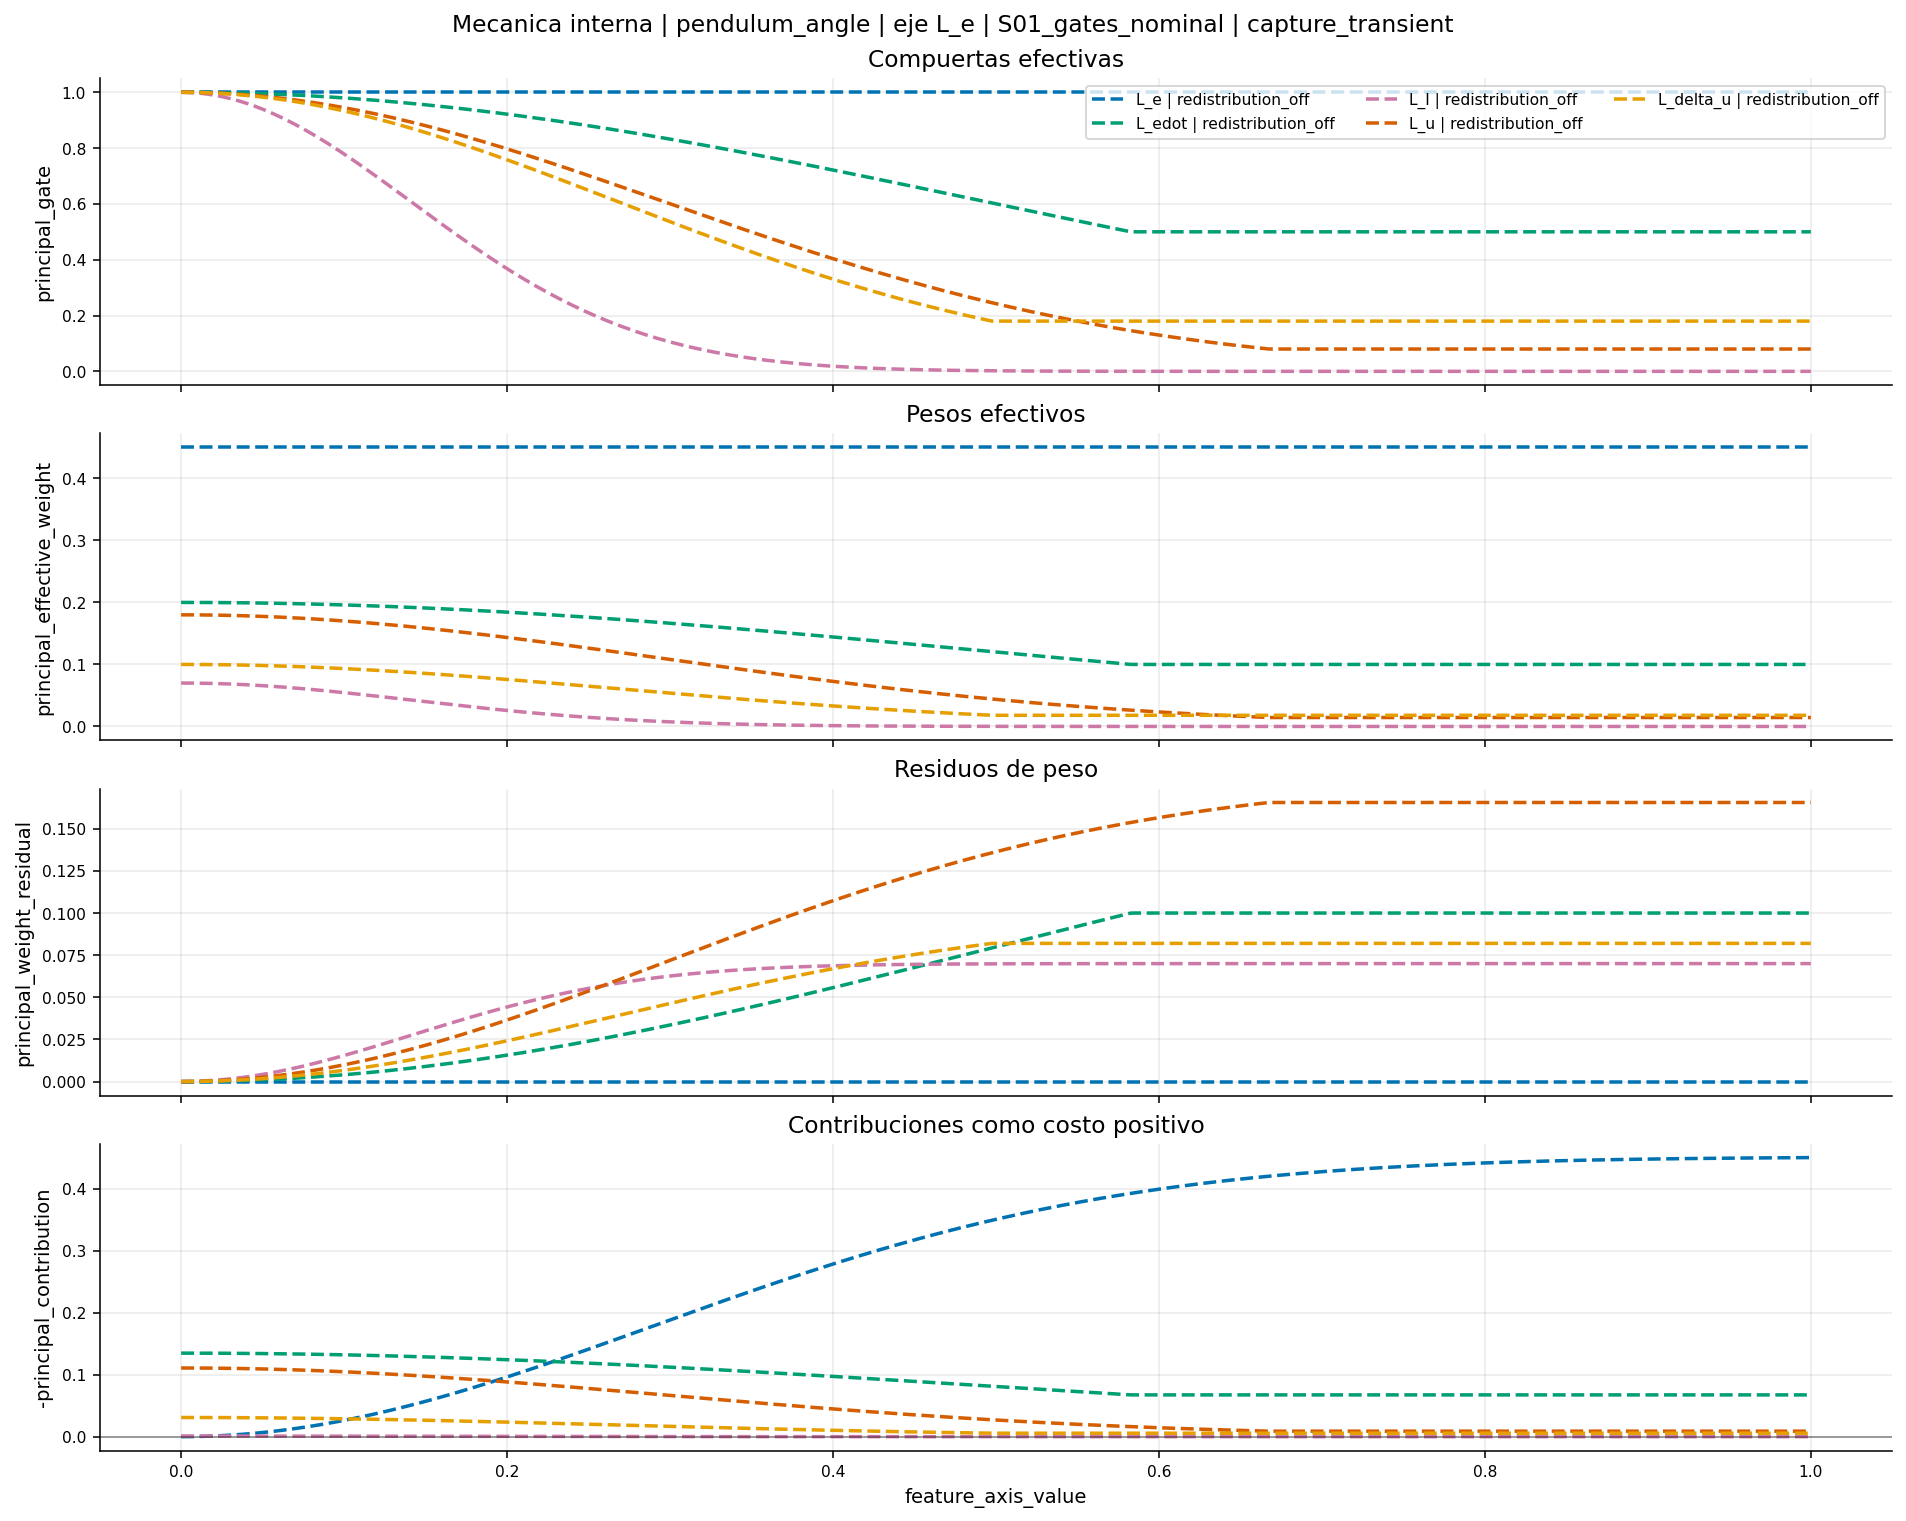

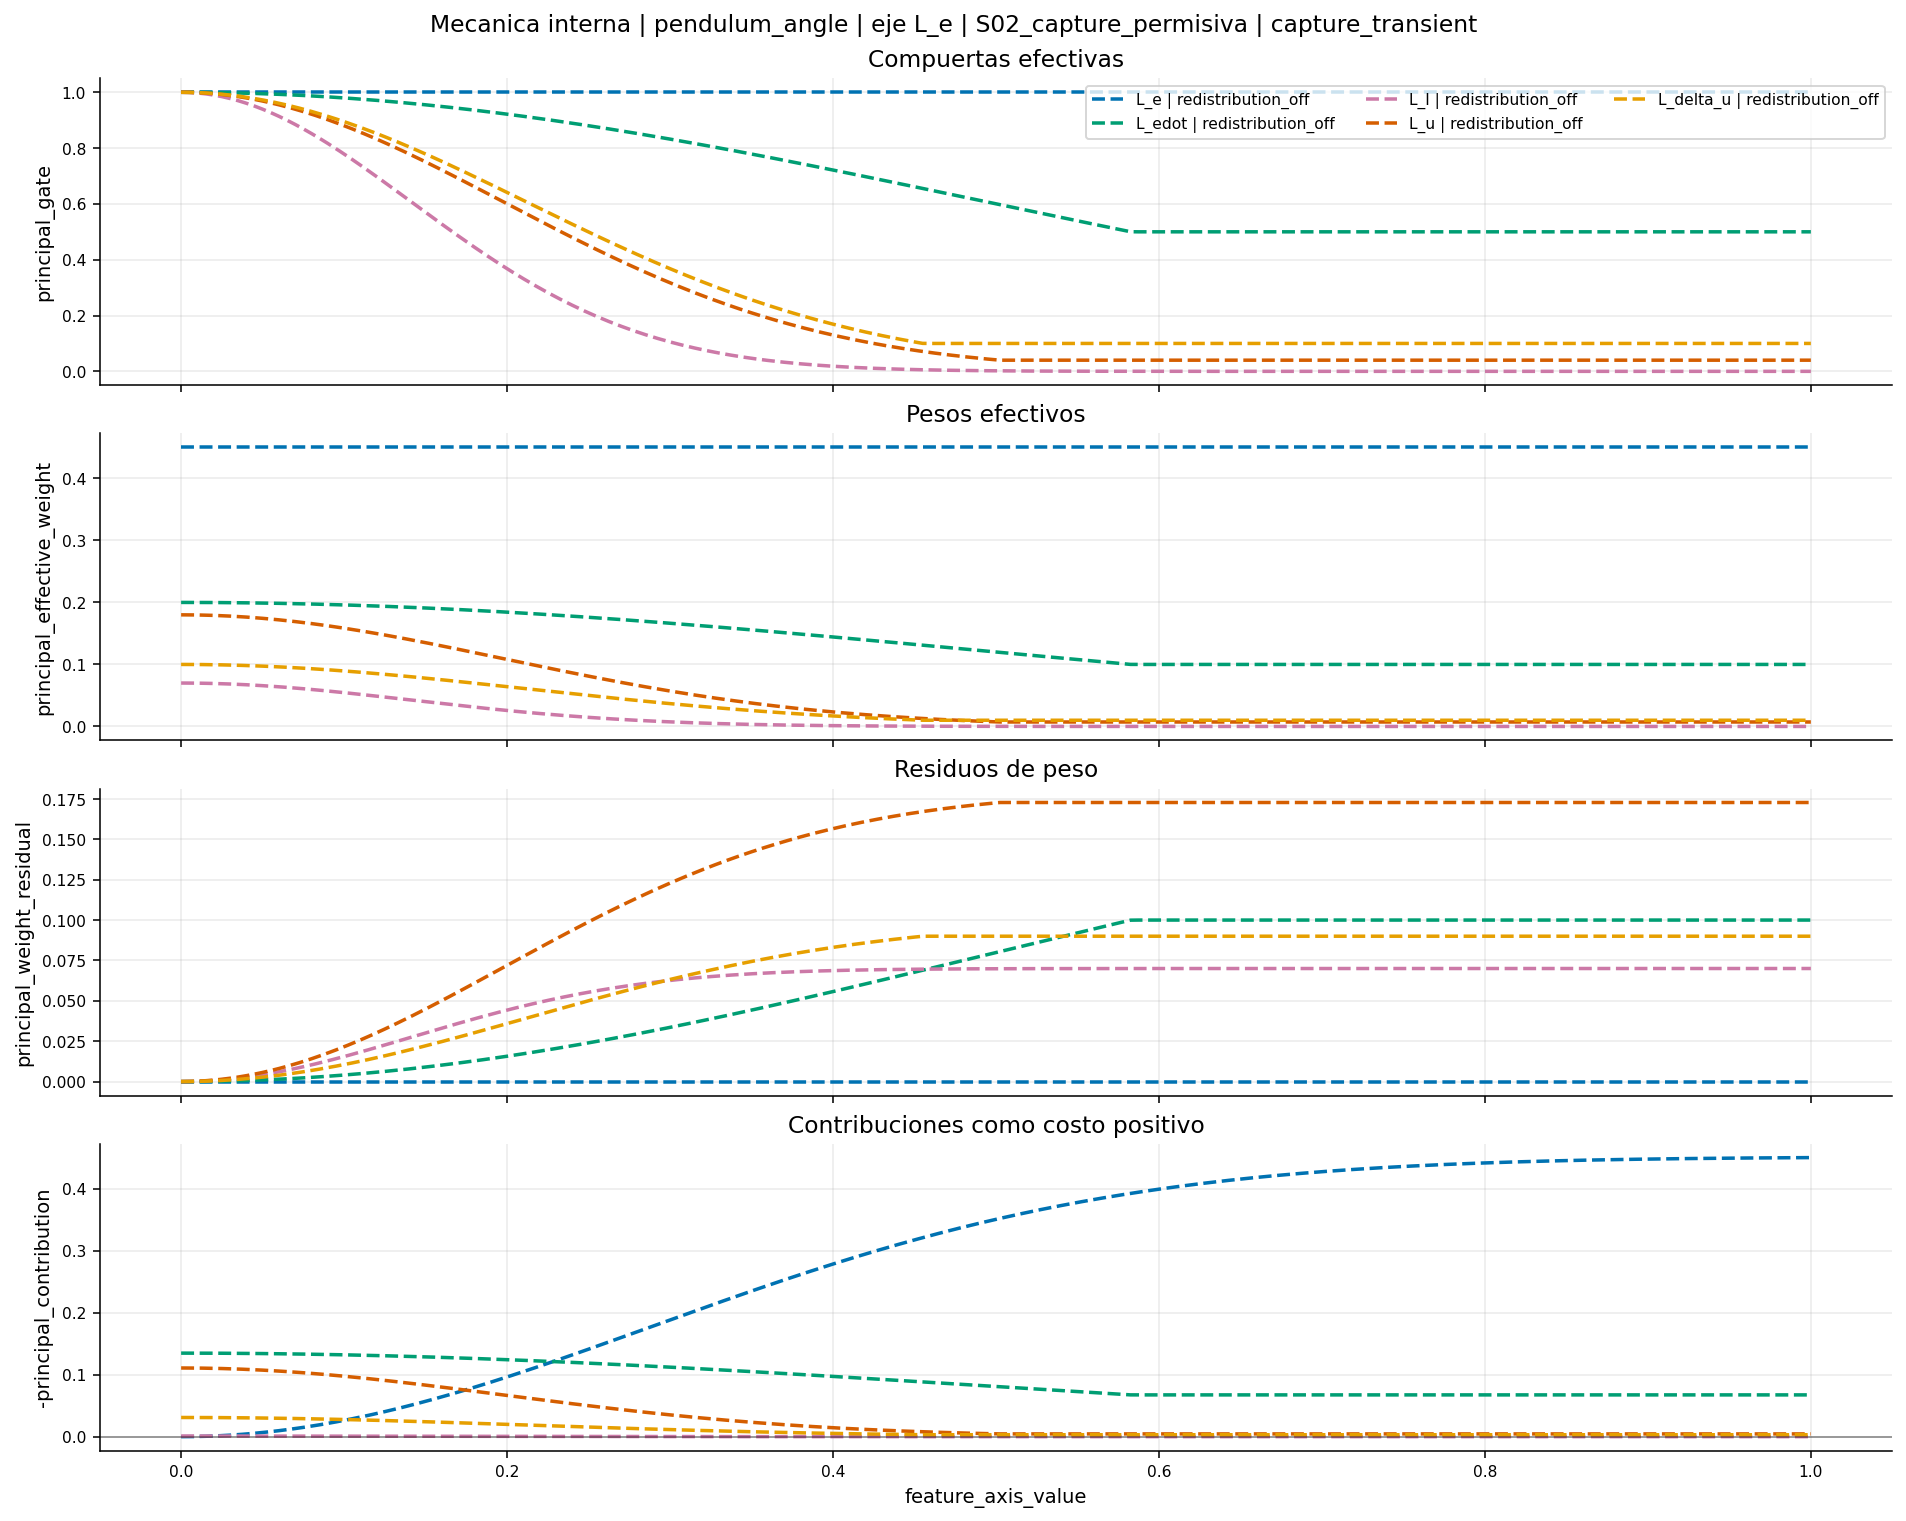

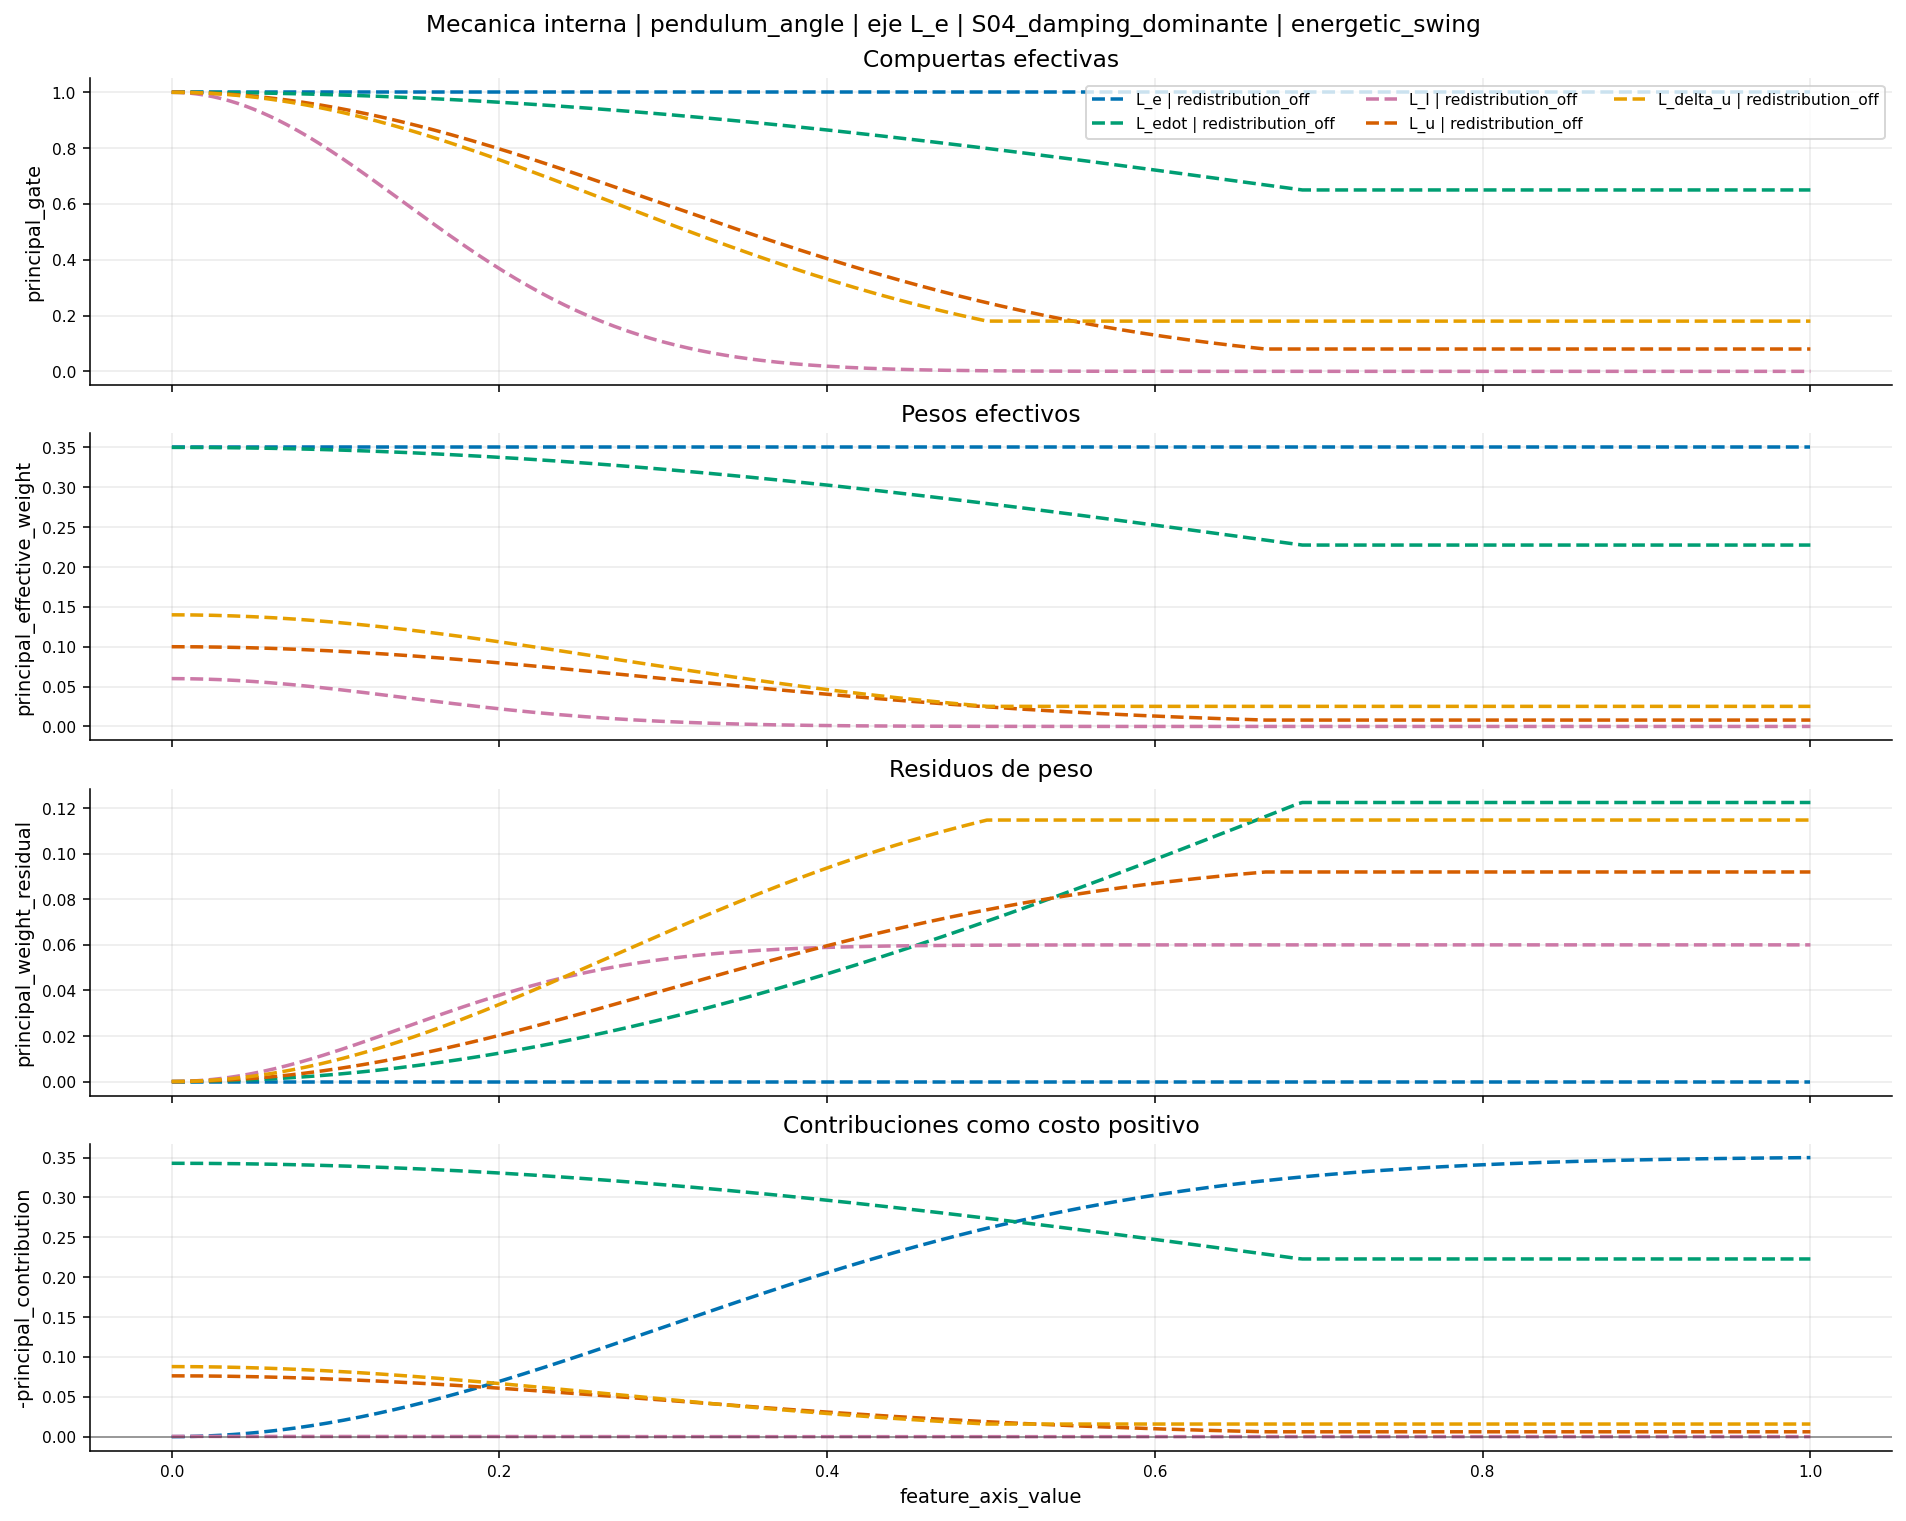

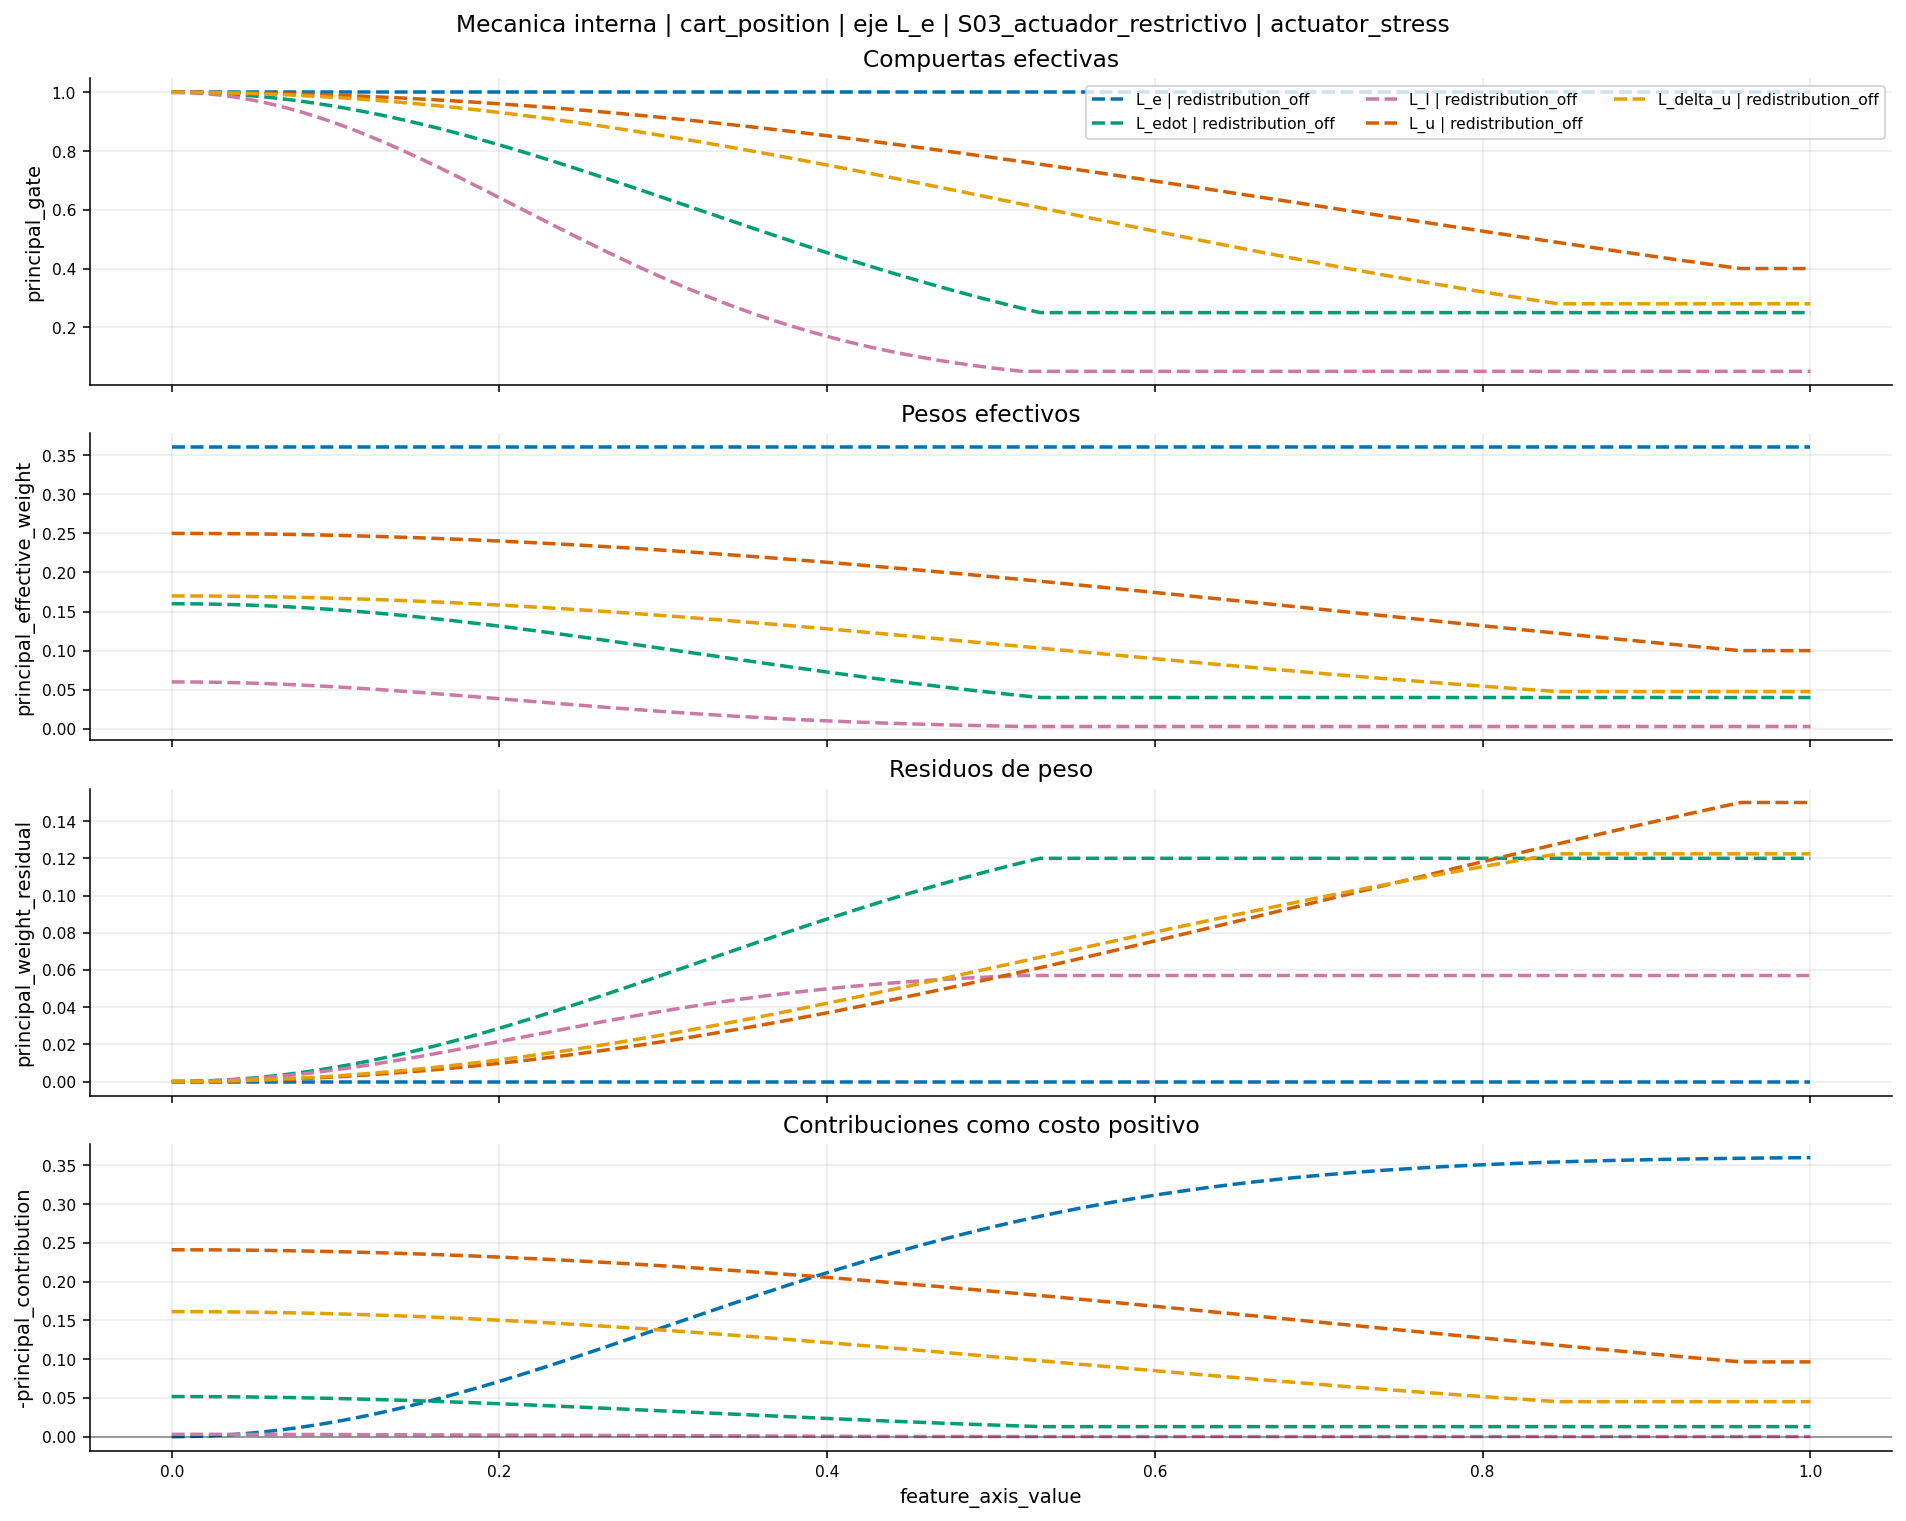

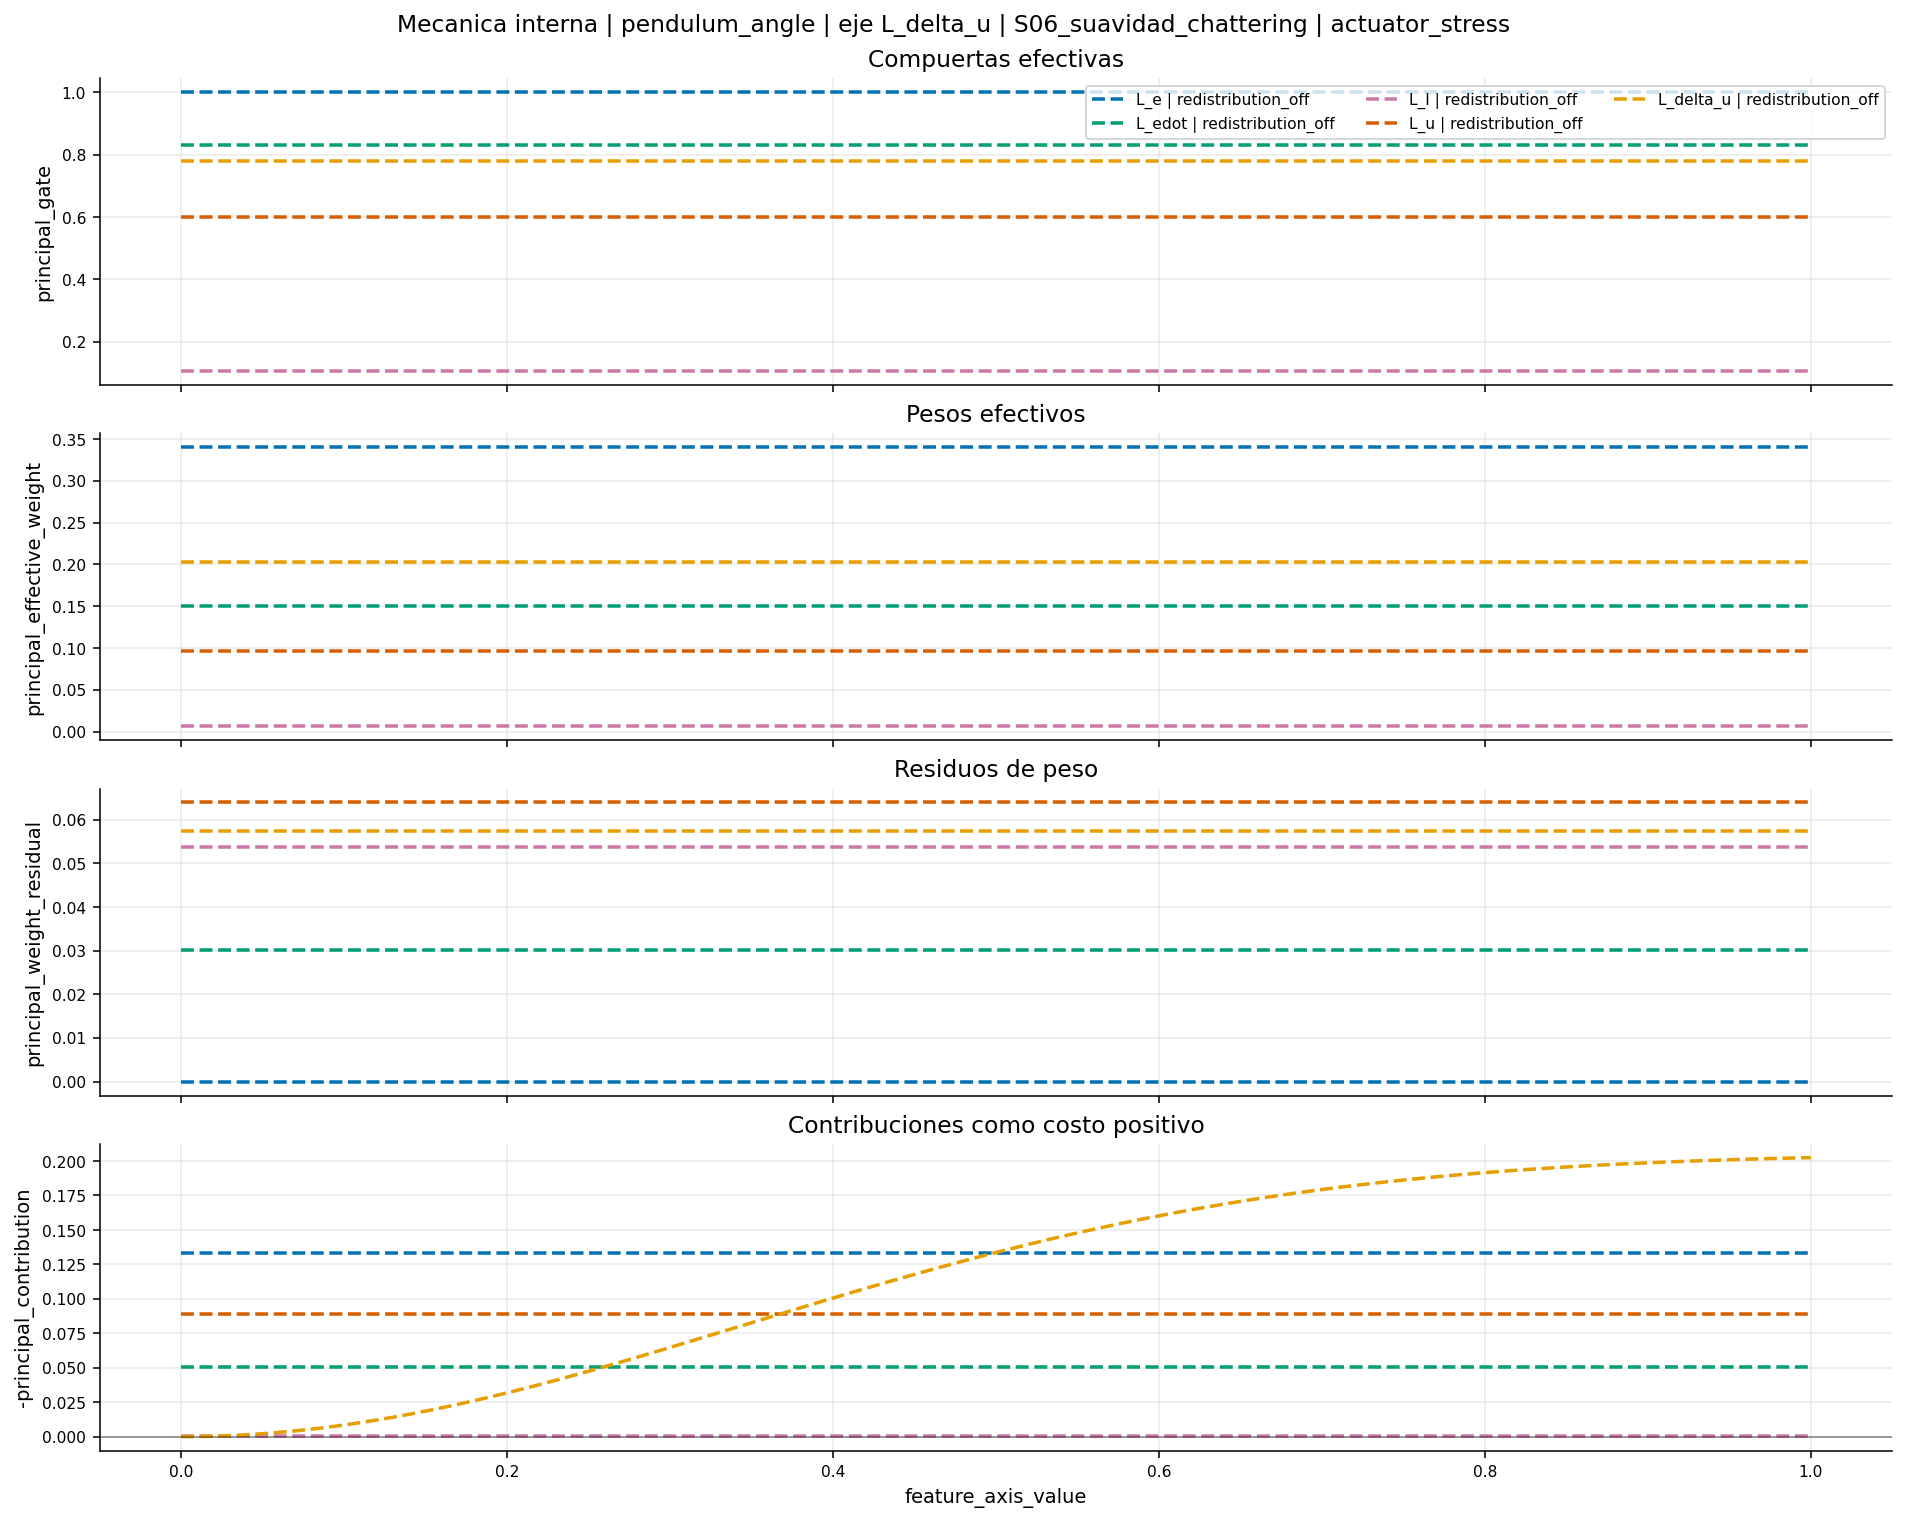

In [39]:
# ---------------------------------------------------------------------
# 1.6 Parametros editables del grafico interno de presupuesto
# ---------------------------------------------------------------------

section1_internal_cases = [
    {
        "var_obj": "pendulum_angle",
        "feature_axis_name": "L_e",
        "physical_regime": "capture_transient",
        "scenario_name": "S01_gates_nominal",
    },
    {
        "var_obj": "pendulum_angle",
        "feature_axis_name": "L_e",
        "physical_regime": "capture_transient",
        "scenario_name": "S02_capture_permisiva",
    },
    {
        "var_obj": "pendulum_angle",
        "feature_axis_name": "L_e",
        "physical_regime": "energetic_swing",
        "scenario_name": "S04_damping_dominante",
    },
    {
        "var_obj": "cart_position",
        "feature_axis_name": "L_e",
        "physical_regime": "actuator_stress",
        "scenario_name": "S03_actuador_restrictivo",
    },
    {
        "var_obj": "pendulum_angle",
        "feature_axis_name": "L_delta_u",
        "physical_regime": "actuator_stress",
        "scenario_name": "S06_suavidad_chattering",
    },
]

for case in section1_internal_cases:
    fig, axes = section1_plot_internal_budget_profile(
        profiles_df=section1_profiles_df,
        physical_regime_name=case["physical_regime"],
        var_obj=case["var_obj"],
        feature_axis_name=case["feature_axis_name"],
        scenario_name=case["scenario_name"],
        feature_names=section1_feature_names,
        budget_modes=section1_budget_modes,
    )
    save_figure(
        "fig_01B_budget_gate_profile_"
        f"{case['scenario_name']}_{case['var_obj']}_{case['feature_axis_name']}_{case['physical_regime']}.png"
    )
    plt.show()

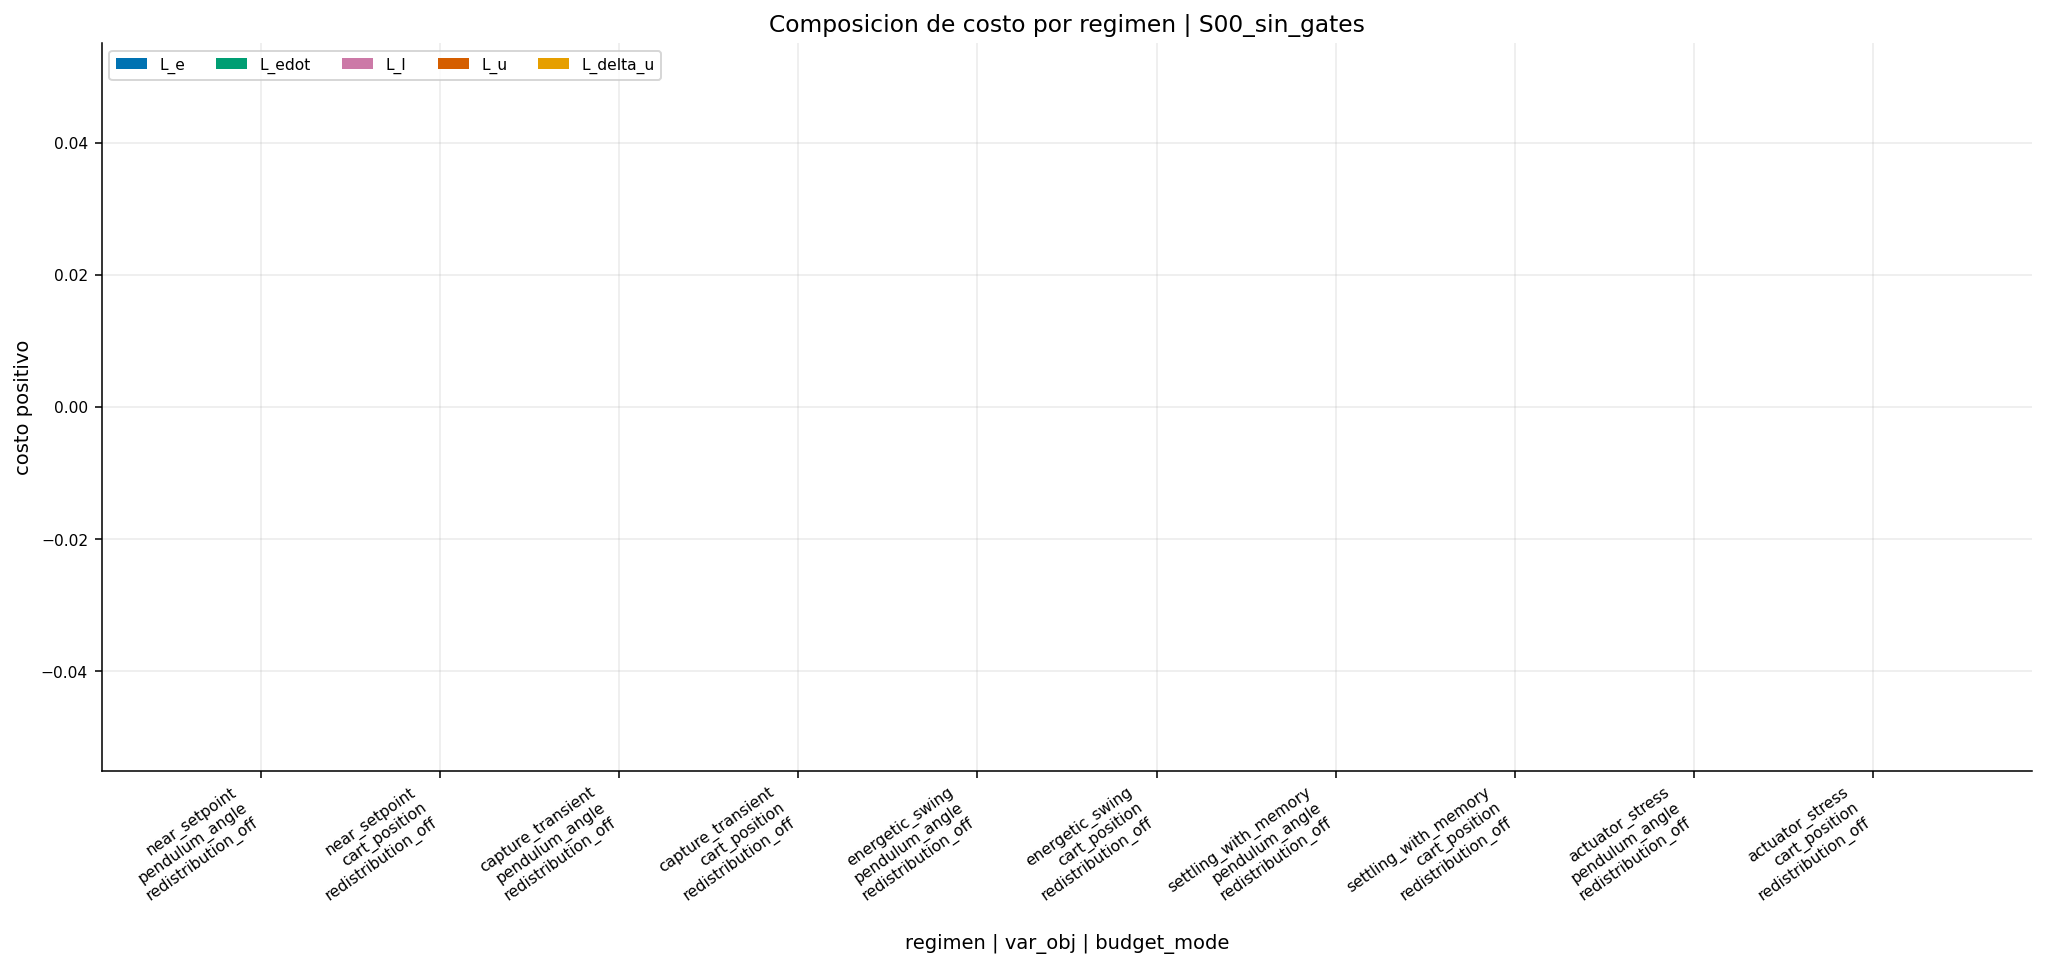

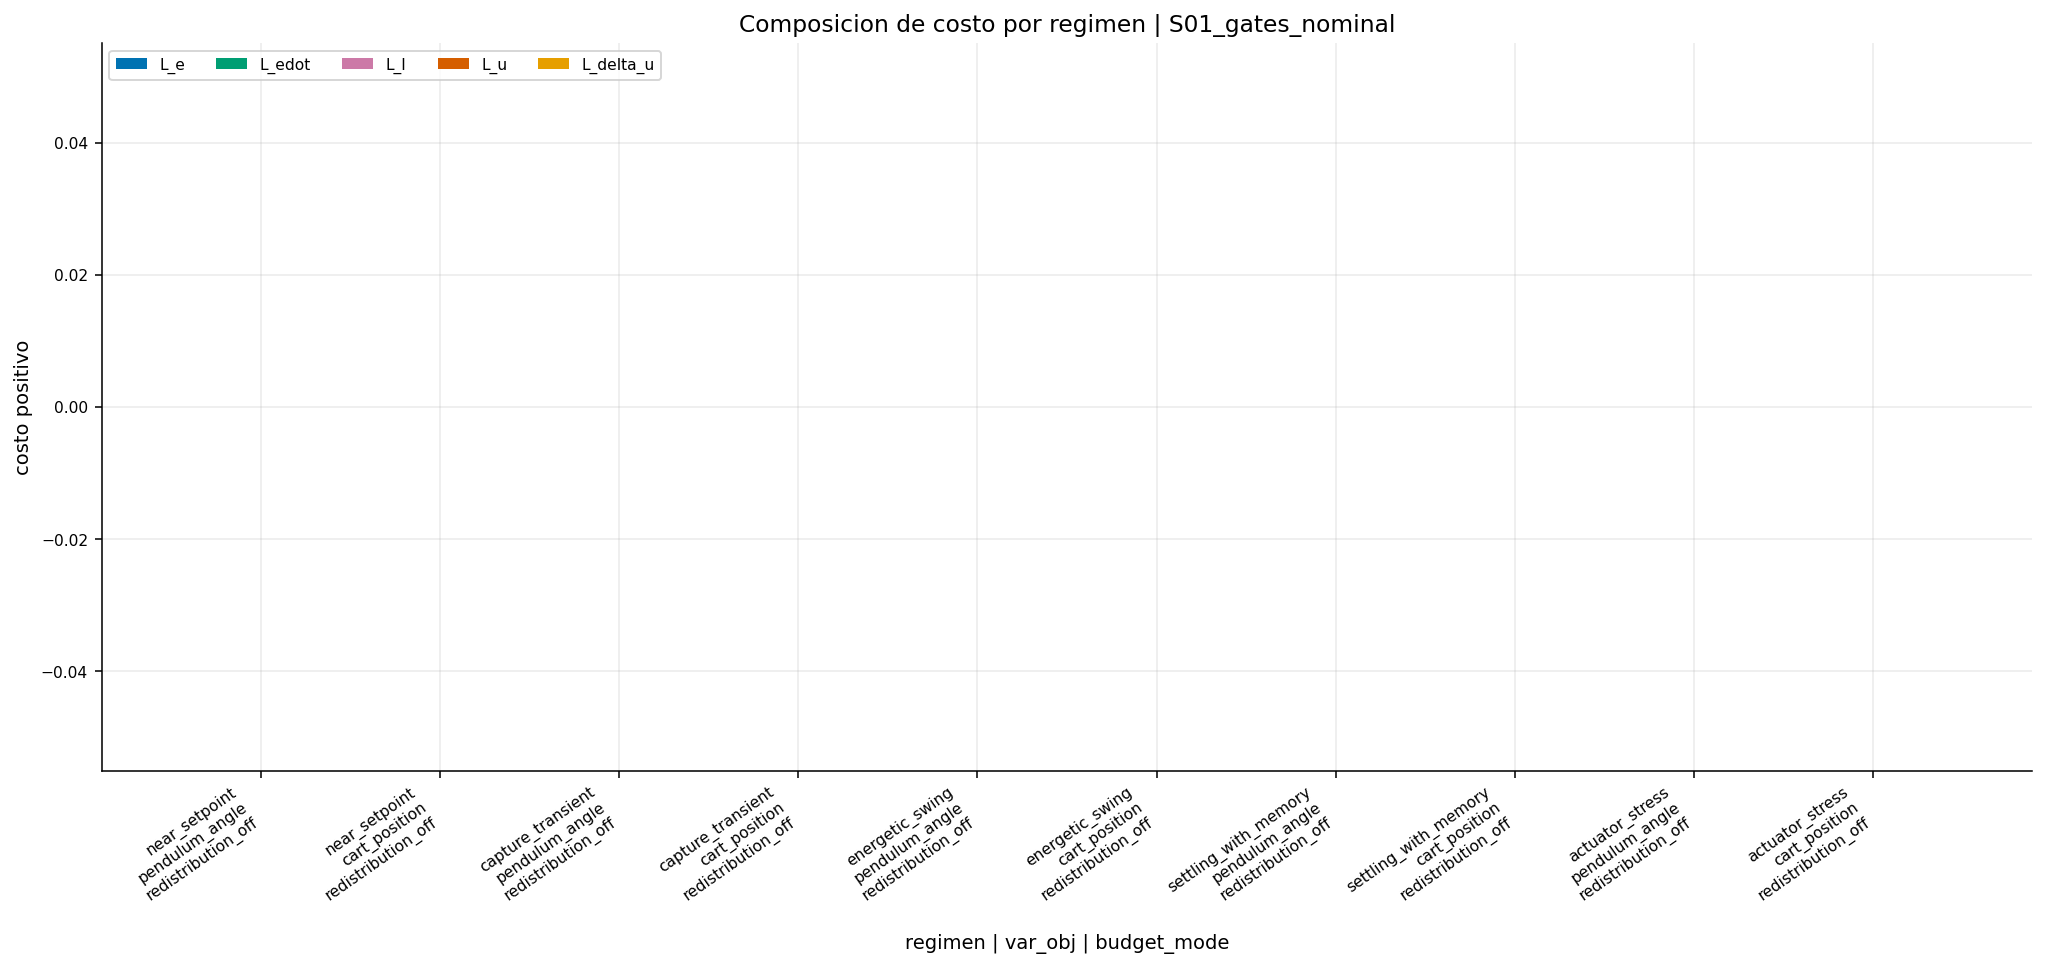

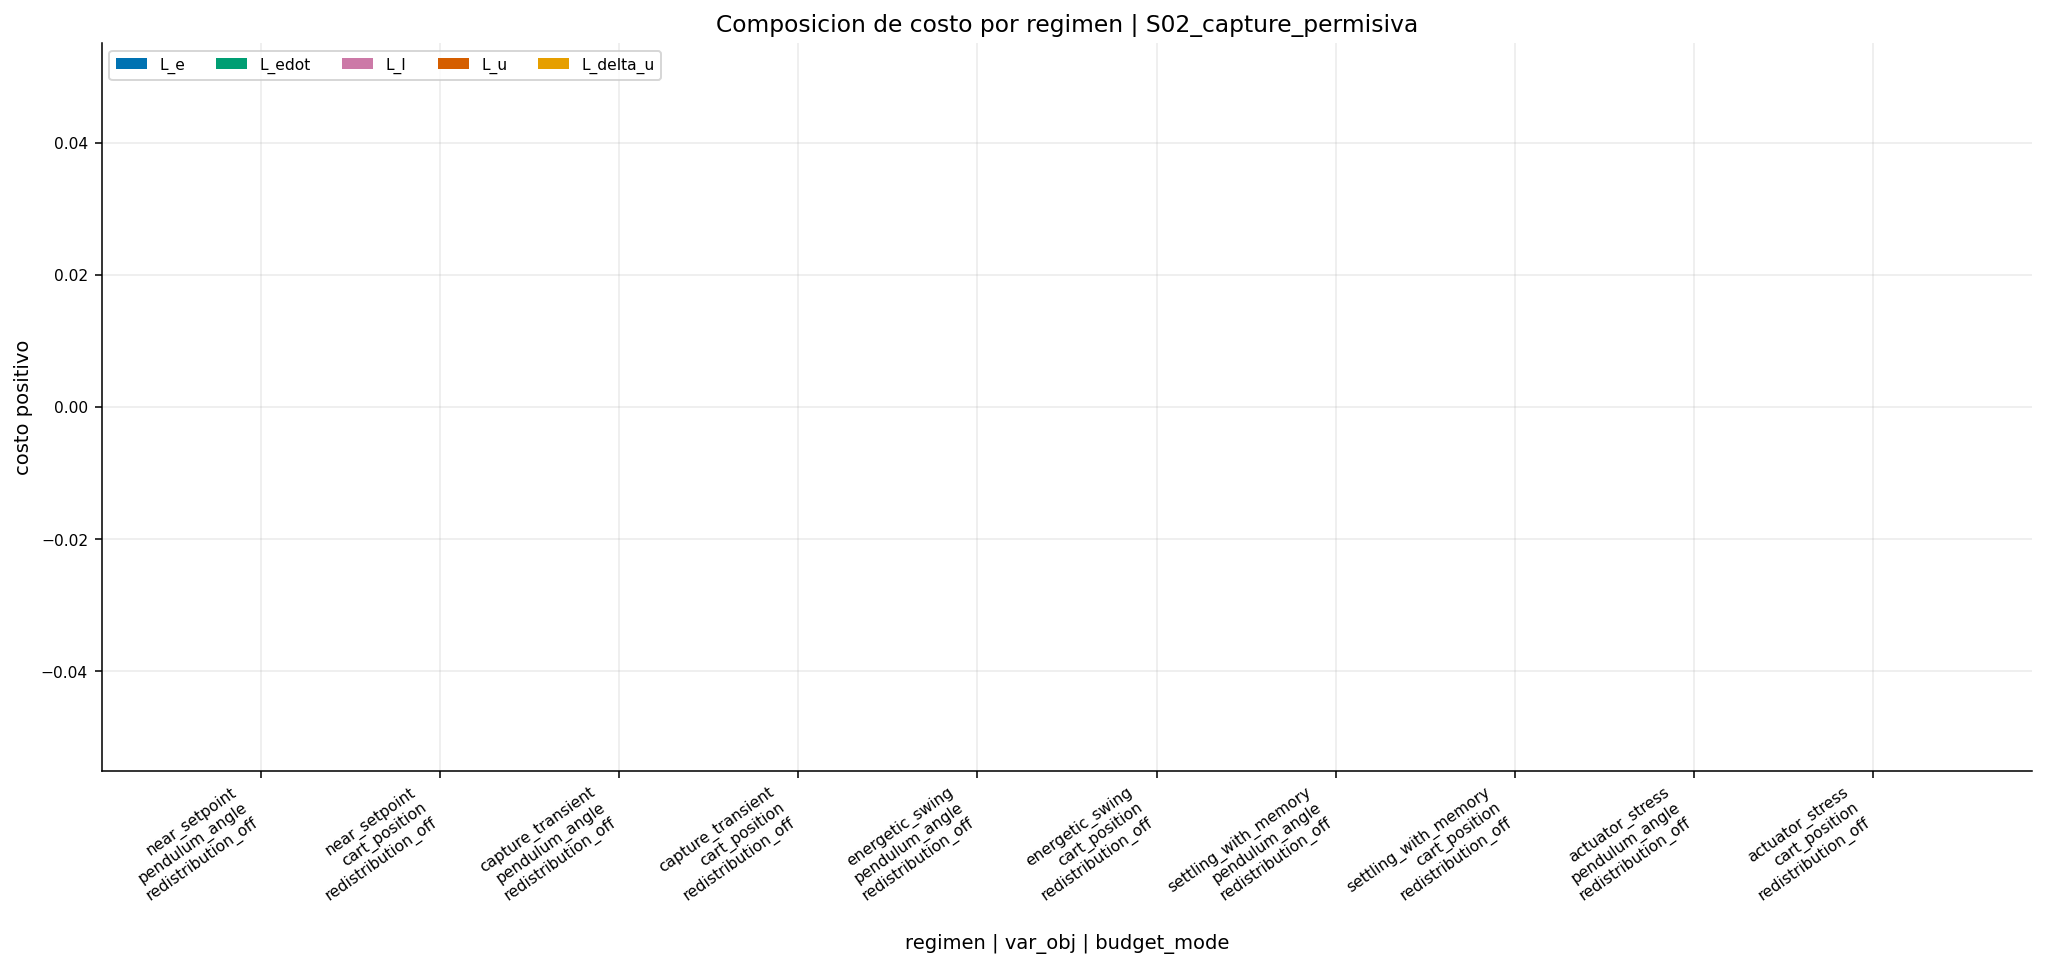

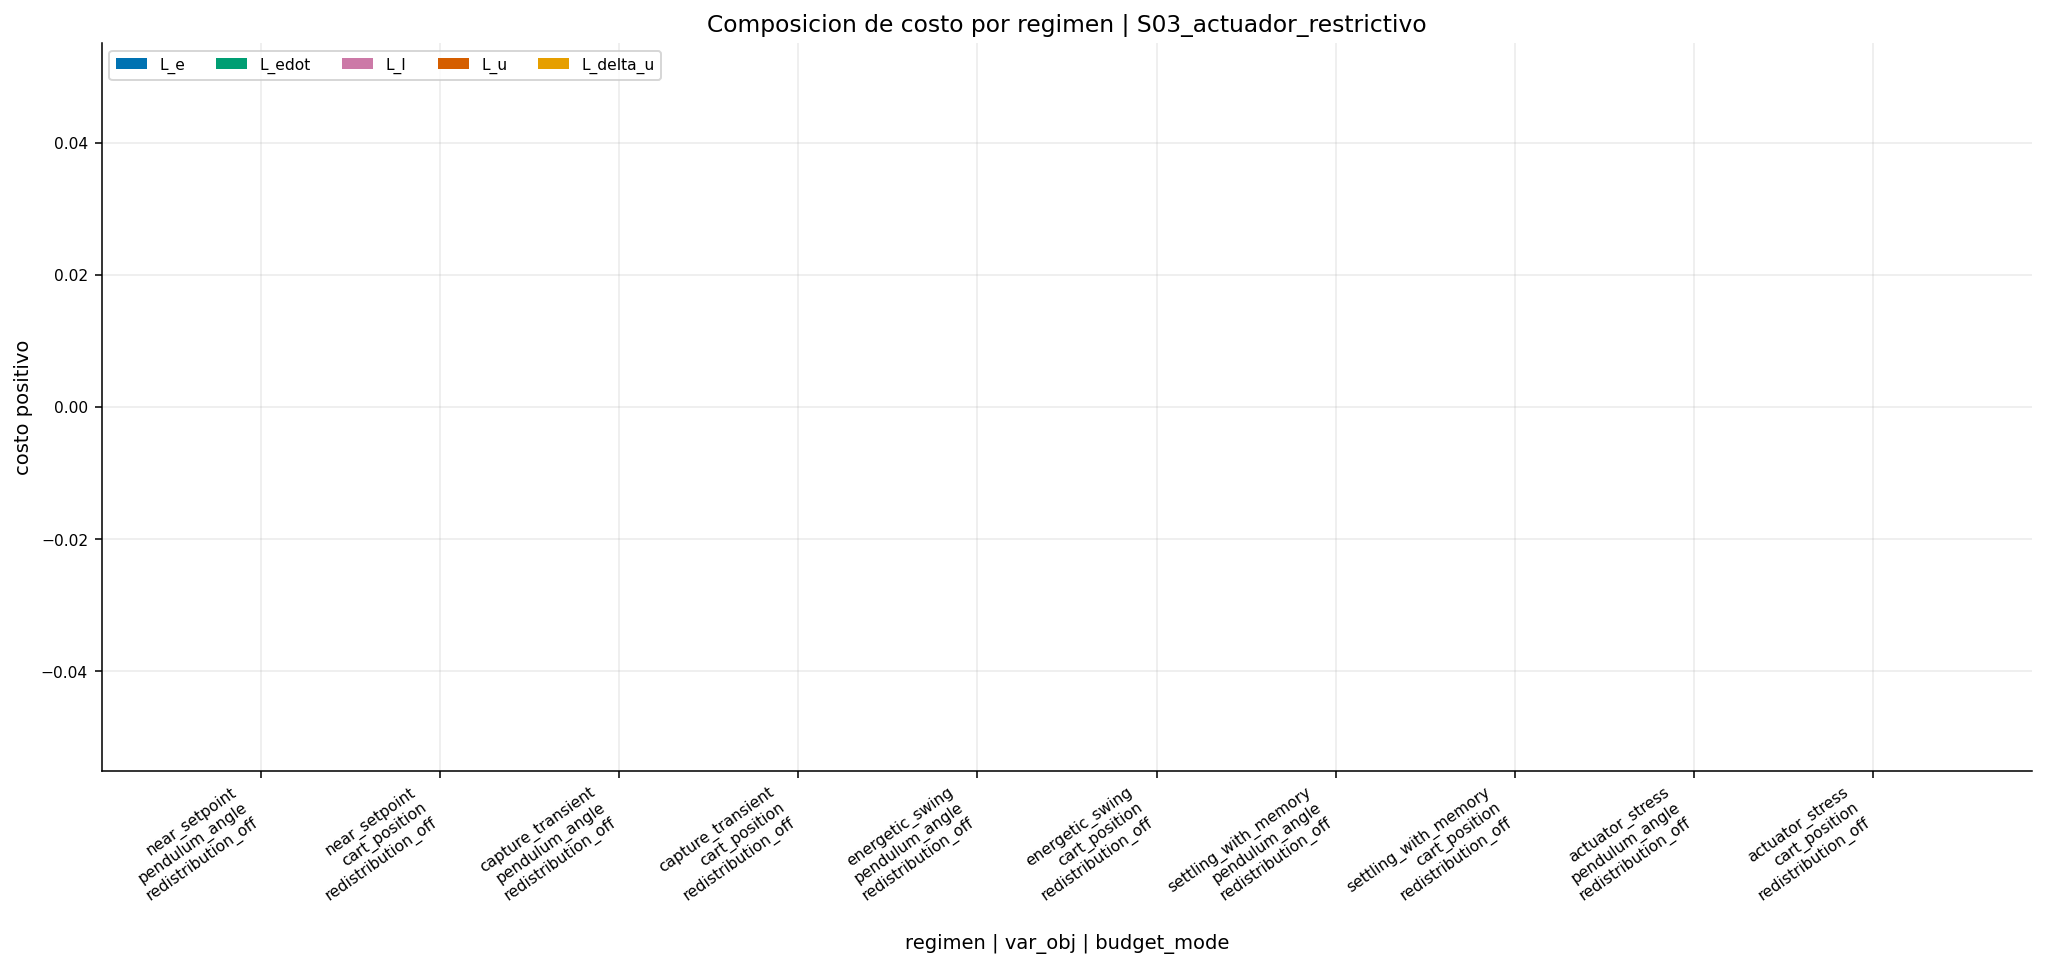

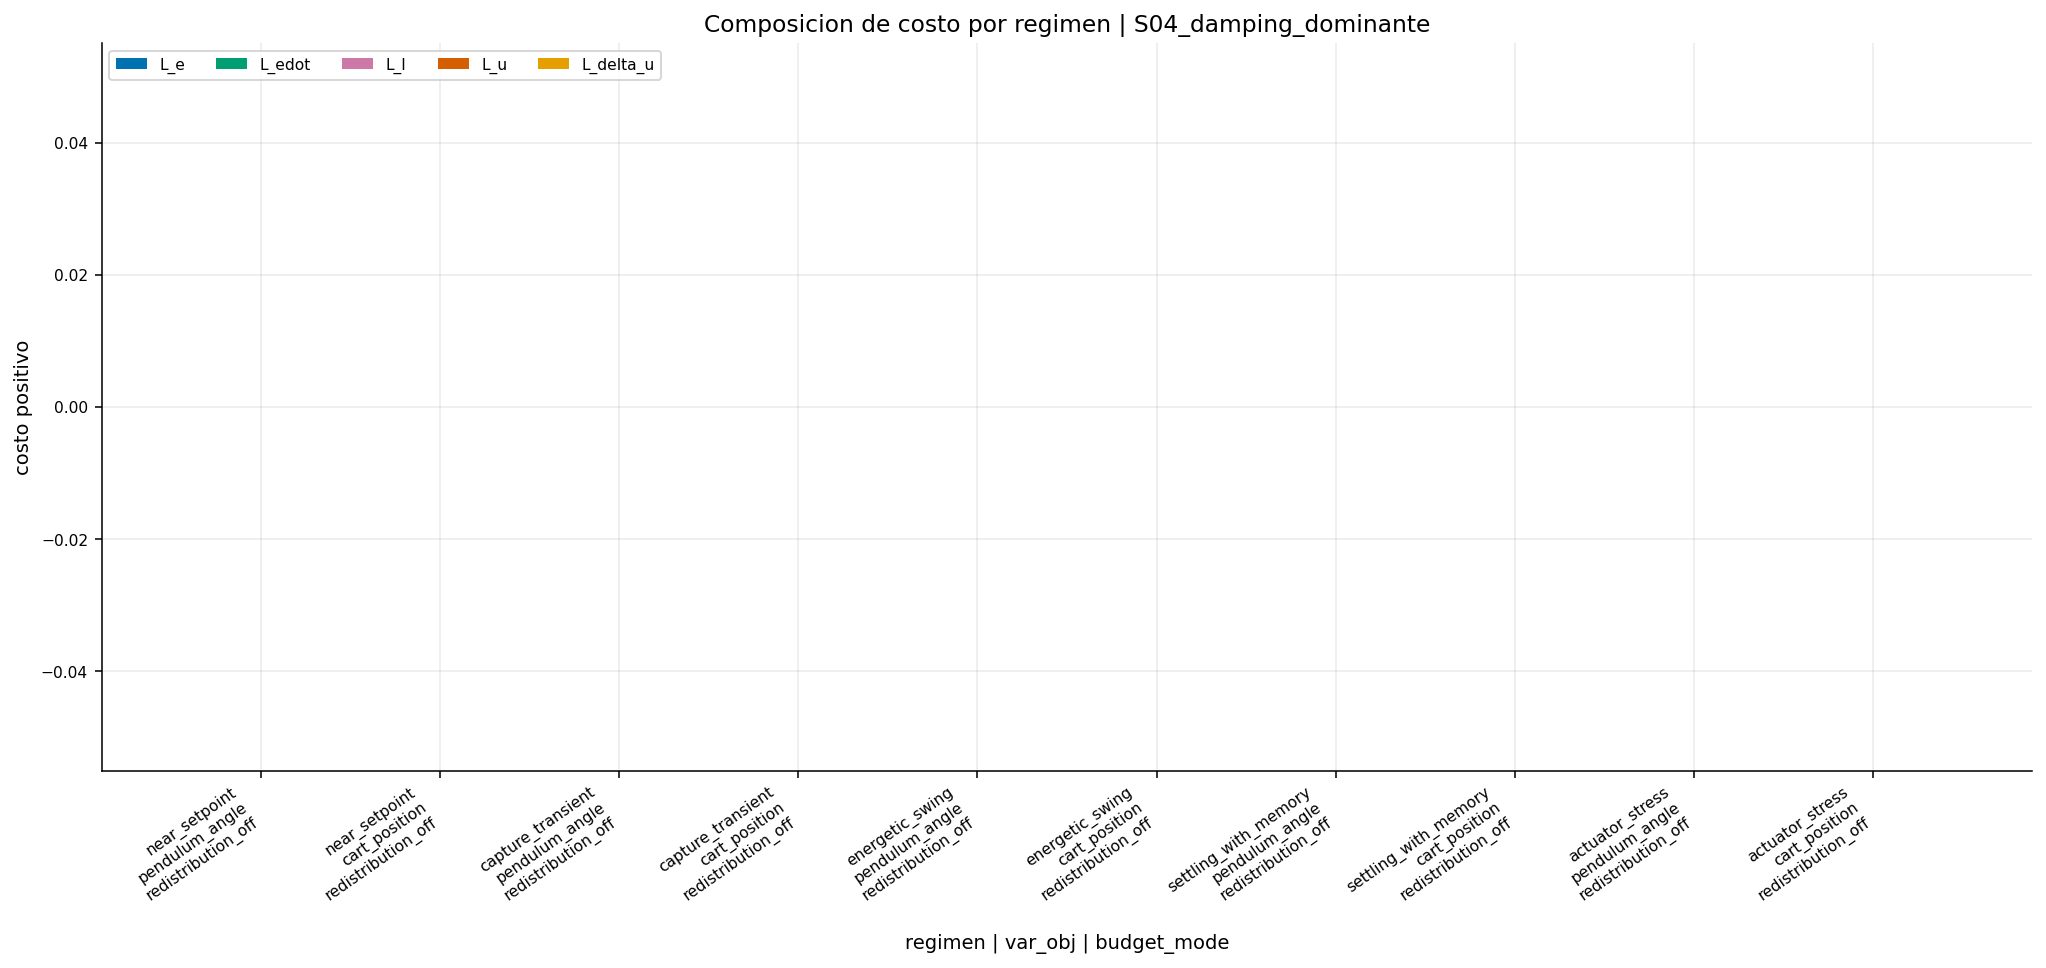

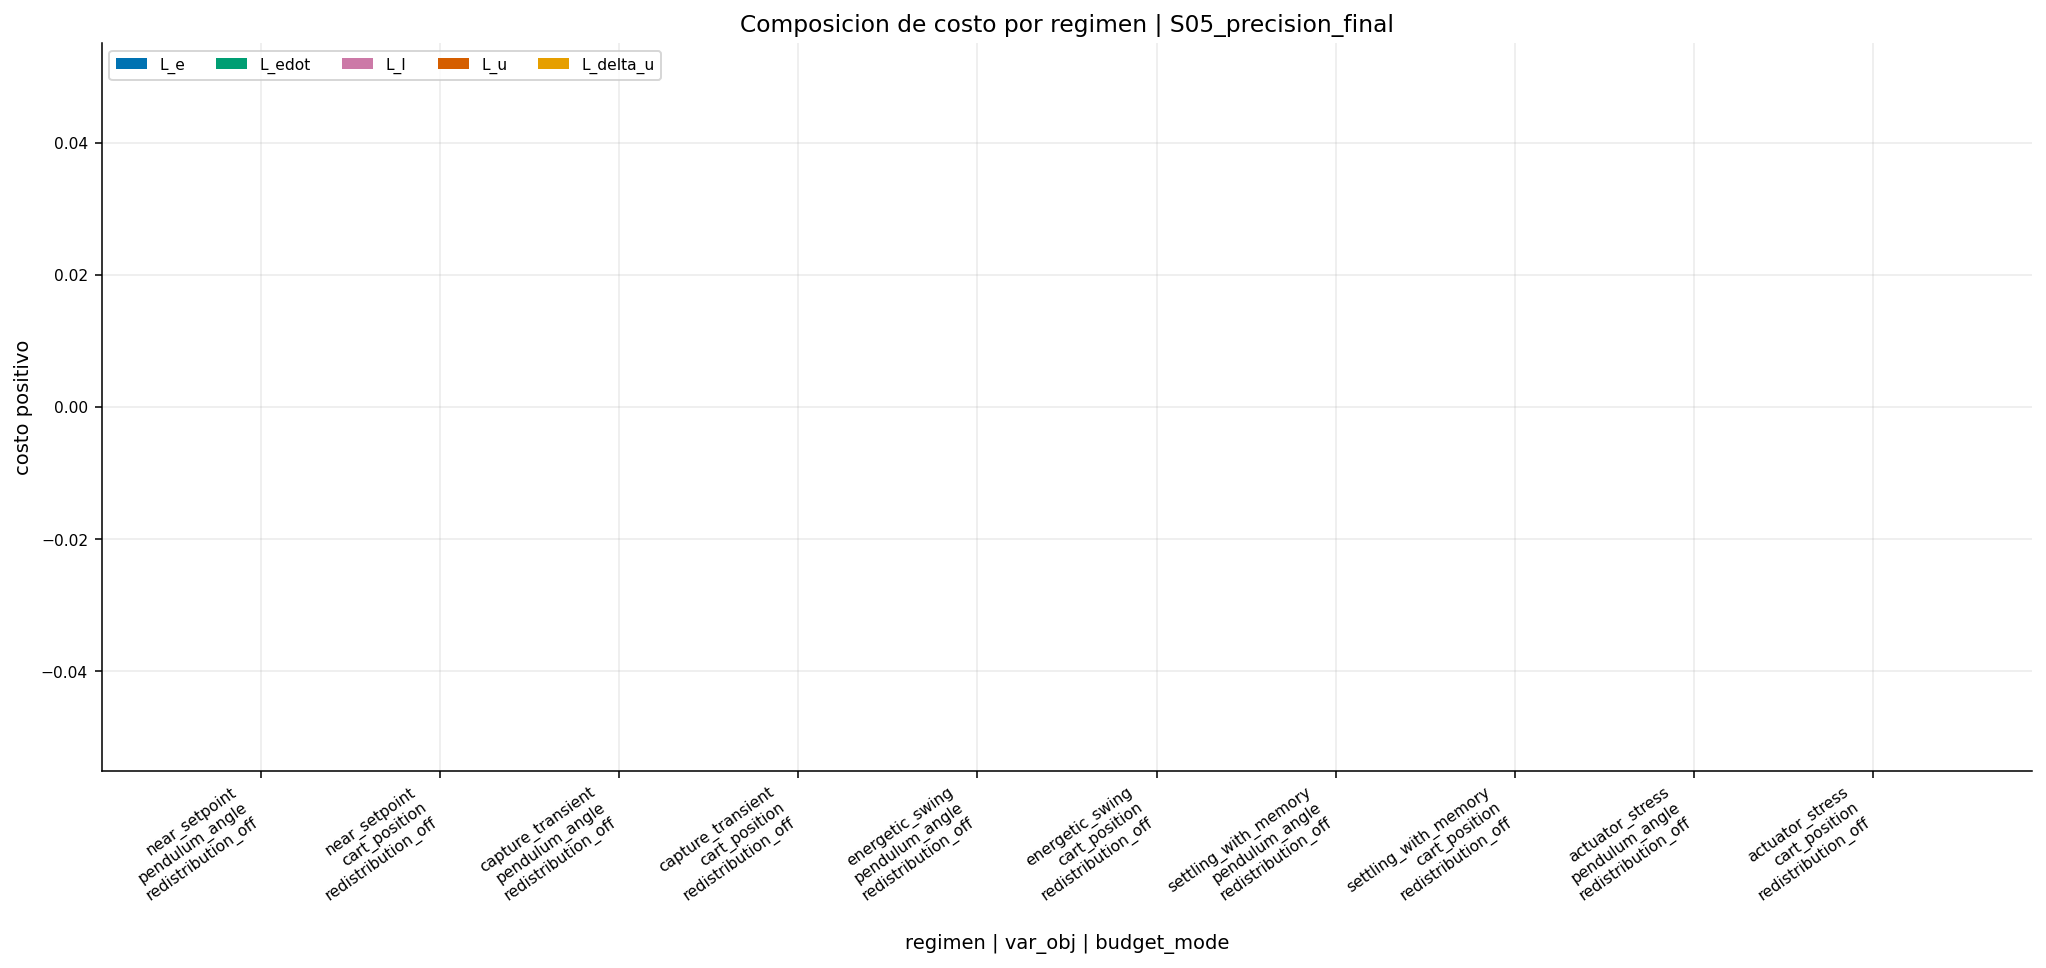

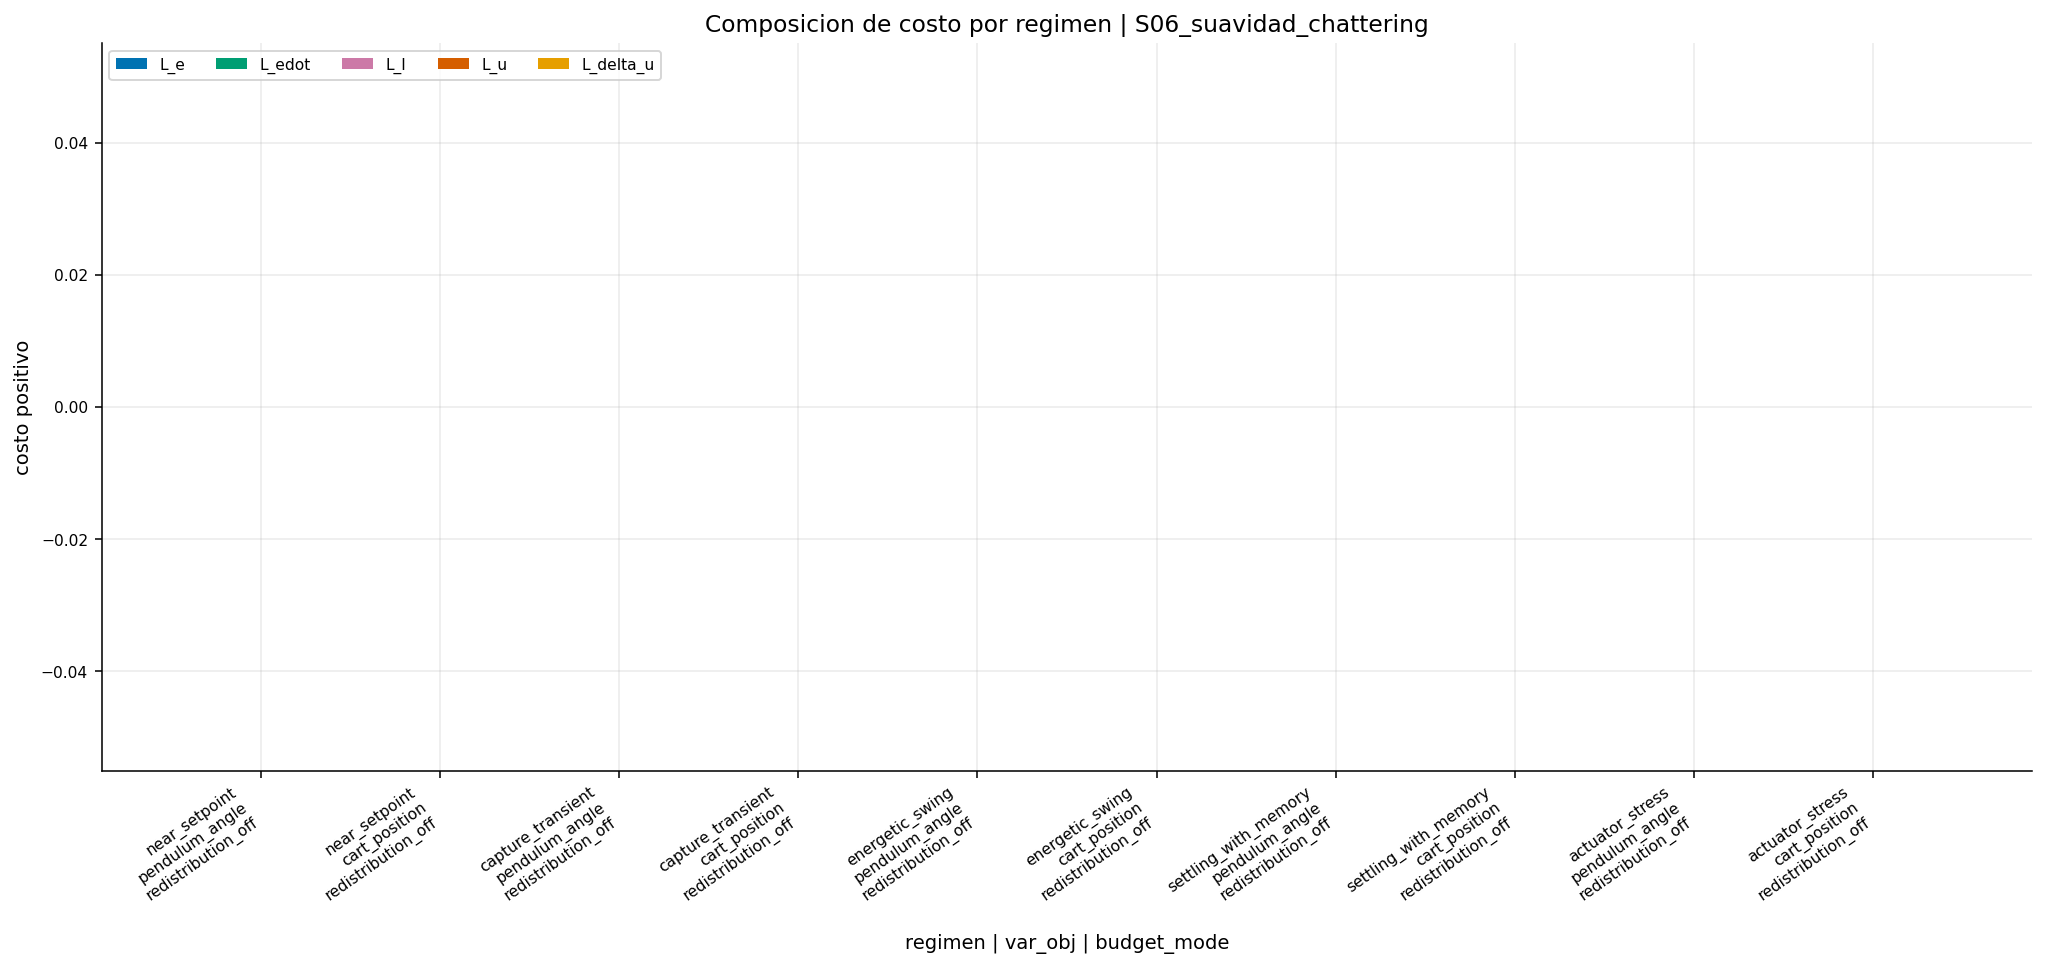

### Muestra del resumen por regimen

,physical_regime,scenario_name,budget_mode,var_obj,principal_loop_cost_01,principal_loop_reward,cost_positive_L_e,cost_positive_L_edot,cost_positive_L_I,cost_positive_L_u,cost_positive_L_delta_u
0,near_setpoint,S00_sin_gates,redistribution_off,pendulum_angle,0.0,-0.0,0.0,0.0,0.0,0.0,0.0
1,near_setpoint,S00_sin_gates,redistribution_off,cart_position,0.0,-0.0,0.0,0.0,0.0,0.0,0.0
2,near_setpoint,S01_gates_nominal,redistribution_off,pendulum_angle,0.0,-0.0,0.0,0.0,0.0,0.0,0.0
3,near_setpoint,S01_gates_nominal,redistribution_off,cart_position,0.0,-0.0,0.0,0.0,0.0,0.0,0.0
4,near_setpoint,S02_capture_permisiva,redistribution_off,pendulum_angle,0.0,-0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
65,actuator_stress,S04_damping_dominante,redistribution_off,cart_position,0.0,-0.0,0.0,0.0,0.0,0.0,0.0
66,actuator_stress,S05_precision_final,redistribution_off,pendulum_angle,0.0,-0.0,0.0,0.0,0.0,0.0,0.0
67,actuator_stress,S05_precision_final,redistribution_off,cart_position,0.0,-0.0,0.0,0.0,0.0,0.0,0.0
68,actuator_stress,S06_suavidad_chattering,redistribution_off,pendulum_angle,0.0,-0.0,0.0,0.0,0.0,0.0,0.0


In [40]:
# ---------------------------------------------------------------------
# 1.7 Parametros editables del resumen por regimen
# ---------------------------------------------------------------------

section1_bar_scenario_names = [
    "S00_sin_gates",
    "S01_gates_nominal",
    "S02_capture_permisiva",
    "S03_actuador_restrictivo",
    "S04_damping_dominante",
    "S05_precision_final",
    "S06_suavidad_chattering",
]

for section1_bar_scenario_name in section1_bar_scenario_names:
    fig, ax = section1_plot_regime_contribution_bars(
        regime_state_df=section1_regime_state_df,
        scenario_name=section1_bar_scenario_name,
        var_objs=section1_var_objs,
        budget_modes=section1_budget_modes,
        feature_names=section1_feature_names,
    )
    save_figure(f"fig_01C_regime_contribution_bars_{section1_bar_scenario_name}.png")
    plt.show()

display(Markdown("### Muestra del resumen por regimen"))
section1_regime_display_cols = [
    "physical_regime",
    "scenario_name",
    "budget_mode",
    "var_obj",
    "principal_loop_cost_01",
    "principal_loop_reward",
    *[f"cost_positive_{feature_name}" for feature_name in section1_feature_names],
]
display(section1_regime_state_df[section1_regime_display_cols].round(5))

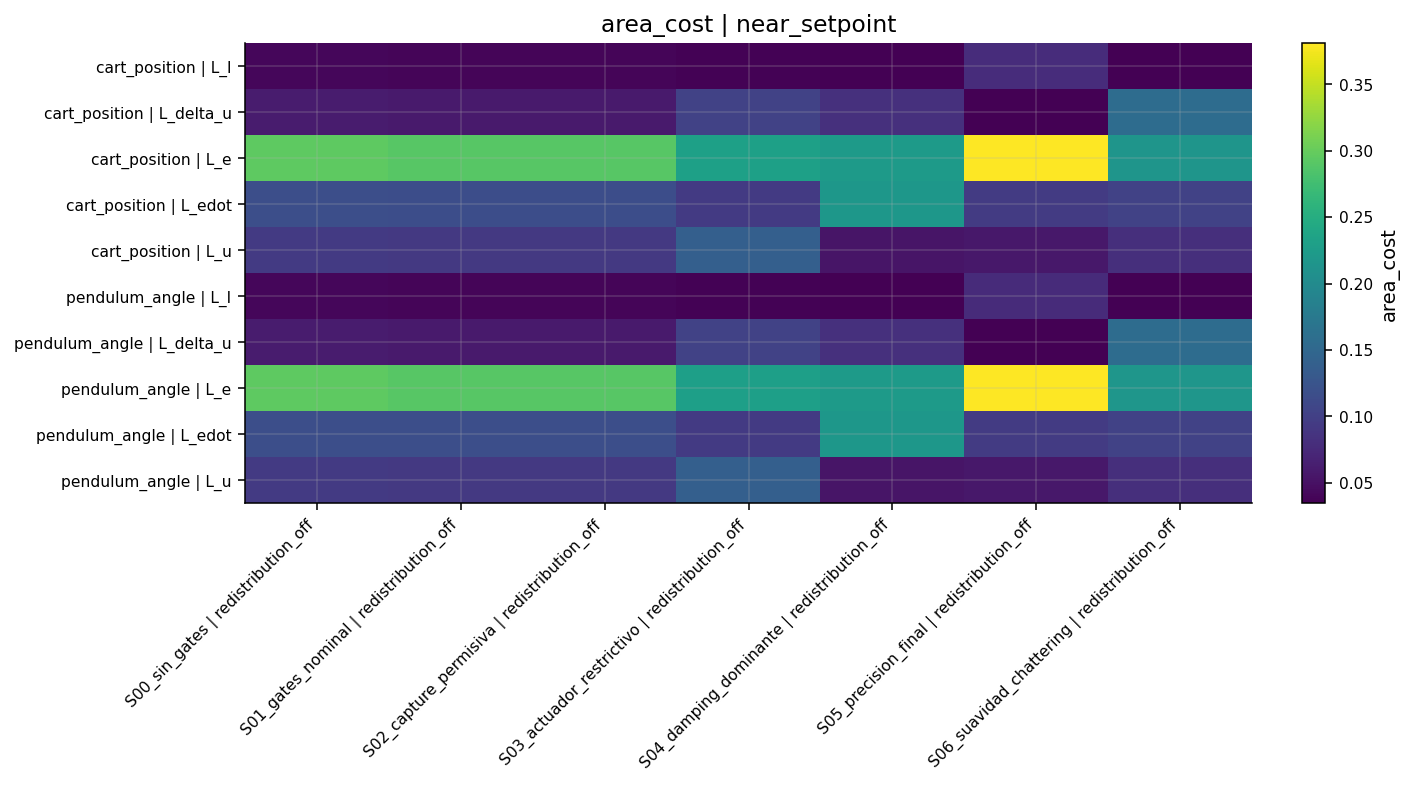

### Heatmap: area_cost | near_setpoint

col_label,S00_sin_gates | redistribution_off,S01_gates_nominal | redistribution_off,S02_capture_permisiva | redistribution_off,S03_actuador_restrictivo | redistribution_off,S04_damping_dominante | redistribution_off,S05_precision_final | redistribution_off,S06_suavidad_chattering | redistribution_off
row_label,,,,,,,
cart_position | L_I,0.04007,0.03972,0.03971,0.03690,0.03578,0.07894,0.03489
cart_position | L_delta_u,0.06045,0.06015,0.06002,0.10305,0.08208,0.03584,0.15717
cart_position | L_e,0.29539,0.29100,0.29052,0.23074,0.22326,0.38080,0.21573
cart_position | L_edot,0.11737,0.11685,0.11683,0.09308,0.21839,0.09475,0.10306
cart_position | L_u,0.09283,0.09248,0.09204,0.13883,0.05384,0.05662,0.08098
pendulum_angle | L_I,0.04007,0.03932,0.03930,0.03656,0.03544,0.07778,0.03455
pendulum_angle | L_delta_u,0.06045,0.06006,0.05986,0.10303,0.08197,0.03572,0.15731
pendulum_angle | L_e,0.29539,0.29092,0.29052,0.23032,0.22344,0.38027,0.21580
pendulum_angle | L_edot,0.11737,0.11710,0.11708,0.09327,0.21849,0.09486,0.10329


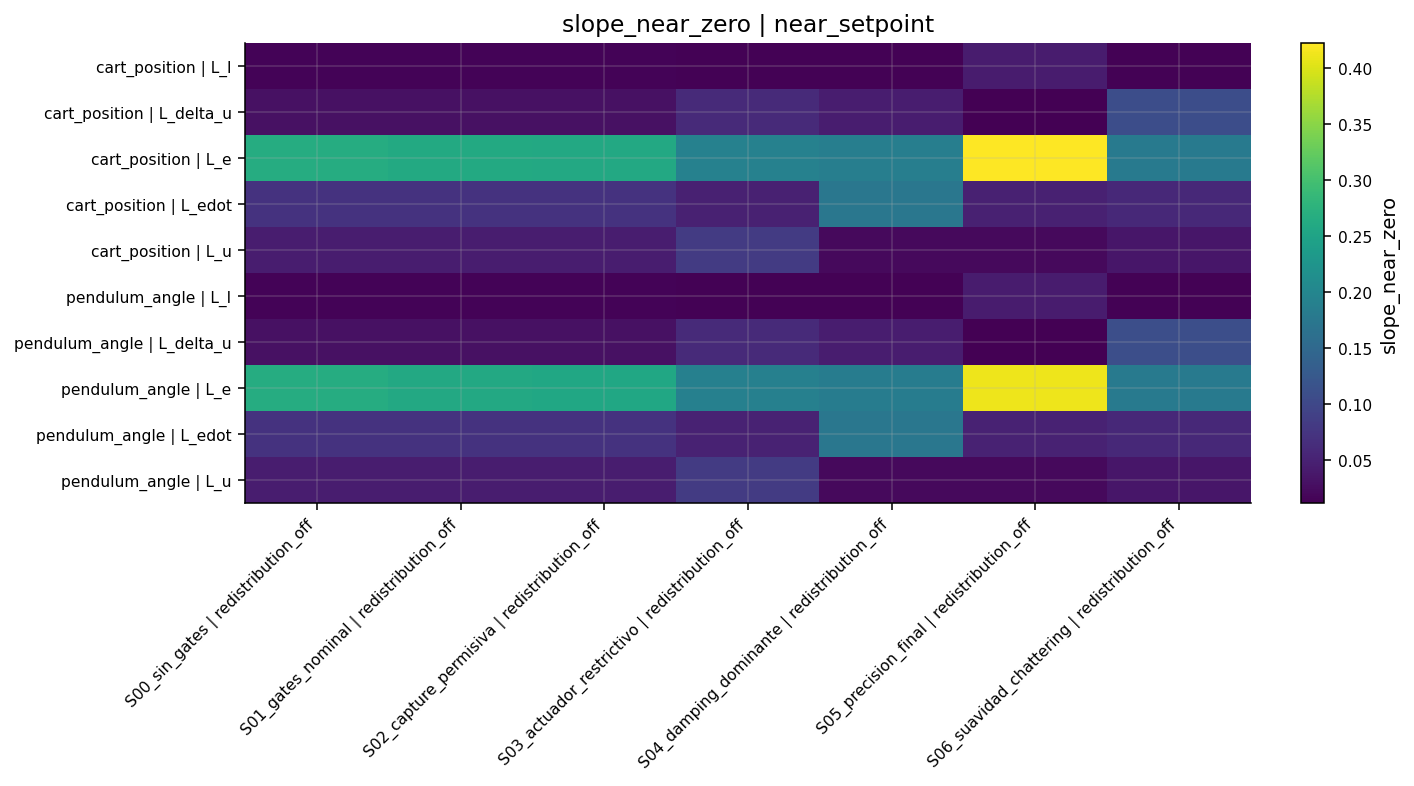

### Heatmap: slope_near_zero | near_setpoint

col_label,S00_sin_gates | redistribution_off,S01_gates_nominal | redistribution_off,S02_capture_permisiva | redistribution_off,S03_actuador_restrictivo | redistribution_off,S04_damping_dominante | redistribution_off,S05_precision_final | redistribution_off,S06_suavidad_chattering | redistribution_off
row_label,,,,,,,
cart_position | L_I,0.01611,0.01595,0.01595,0.01367,0.01367,0.04337,0.01367
cart_position | L_delta_u,0.02960,0.02945,0.02939,0.06072,0.04365,0.01145,0.10931
cart_position | L_e,0.26663,0.26188,0.26019,0.19265,0.18690,0.42245,0.18071
cart_position | L_edot,0.07155,0.07123,0.07123,0.04991,0.17375,0.04991,0.05930
cart_position | L_u,0.04429,0.04413,0.04390,0.08266,0.02139,0.02139,0.03669
pendulum_angle | L_I,0.01611,0.01575,0.01575,0.01350,0.01350,0.04267,0.01350
pendulum_angle | L_delta_u,0.02960,0.02942,0.02931,0.06072,0.04360,0.01144,0.10943
pendulum_angle | L_e,0.26663,0.25896,0.25686,0.19021,0.18437,0.41247,0.17846
pendulum_angle | L_edot,0.07155,0.07142,0.07142,0.05004,0.17385,0.05004,0.05946


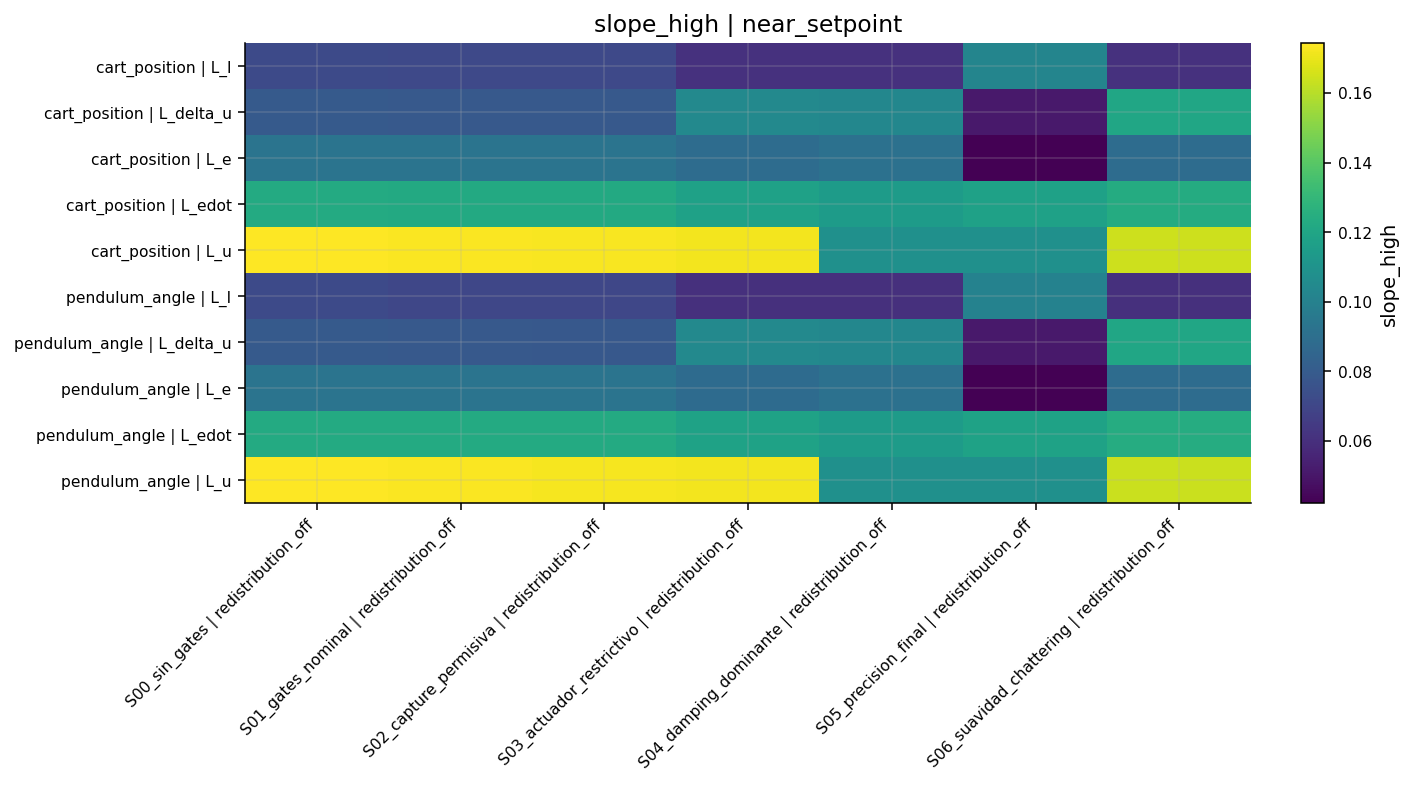

### Heatmap: slope_high | near_setpoint

col_label,S00_sin_gates | redistribution_off,S01_gates_nominal | redistribution_off,S02_capture_permisiva | redistribution_off,S03_actuador_restrictivo | redistribution_off,S04_damping_dominante | redistribution_off,S05_precision_final | redistribution_off,S06_suavidad_chattering | redistribution_off
row_label,,,,,,,
cart_position | L_I,0.07203,0.07131,0.07131,0.06112,0.06112,0.10250,0.06112
cart_position | L_delta_u,0.07948,0.07908,0.07890,0.10434,0.10315,0.05119,0.12022
cart_position | L_e,0.09309,0.09309,0.09309,0.08881,0.09154,0.04209,0.08893
cart_position | L_edot,0.12295,0.12240,0.12240,0.11797,0.11475,0.11797,0.12338
cart_position | L_u,0.17431,0.17369,0.17279,0.17197,0.10864,0.10864,0.16404
pendulum_angle | L_I,0.07203,0.07043,0.07043,0.06036,0.06036,0.10084,0.06036
pendulum_angle | L_delta_u,0.07948,0.07899,0.07869,0.10434,0.10304,0.05113,0.12035
pendulum_angle | L_e,0.09309,0.09309,0.09309,0.08841,0.09154,0.04209,0.08893
pendulum_angle | L_edot,0.12295,0.12272,0.12272,0.11828,0.11482,0.11828,0.12370


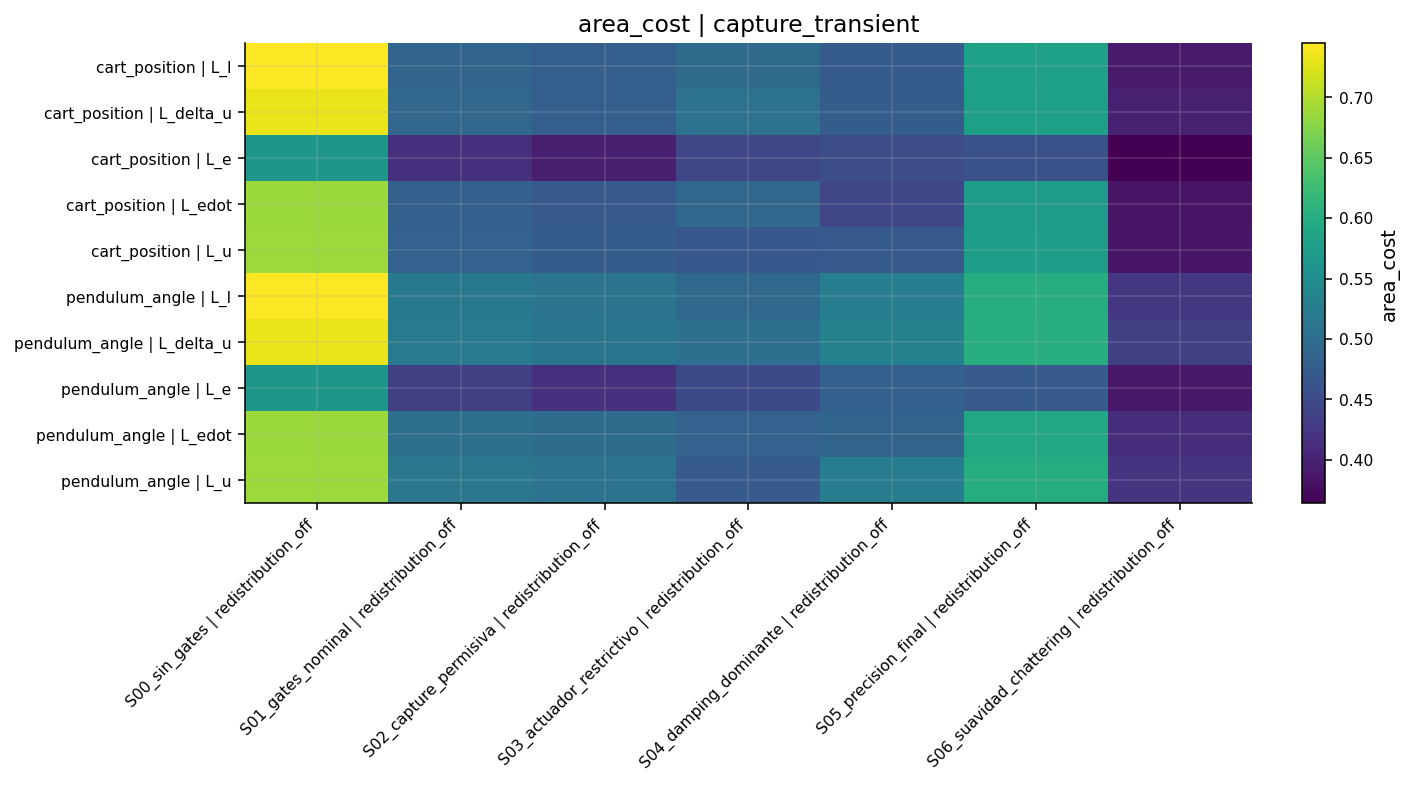

### Heatmap: area_cost | capture_transient

col_label,S00_sin_gates | redistribution_off,S01_gates_nominal | redistribution_off,S02_capture_permisiva | redistribution_off,S03_actuador_restrictivo | redistribution_off,S04_damping_dominante | redistribution_off,S05_precision_final | redistribution_off,S06_suavidad_chattering | redistribution_off
row_label,,,,,,,
cart_position | L_I,0.74456,0.48891,0.47899,0.49565,0.47418,0.58157,0.39116
cart_position | L_delta_u,0.73324,0.49036,0.47903,0.50600,0.47699,0.57966,0.39951
cart_position | L_e,0.56537,0.41630,0.39656,0.44530,0.45389,0.45800,0.36410
cart_position | L_edot,0.68770,0.48099,0.47108,0.49006,0.44502,0.57382,0.38465
cart_position | L_u,0.68814,0.48434,0.47617,0.46850,0.47140,0.57663,0.38734
pendulum_angle | L_I,0.74456,0.51745,0.51055,0.49182,0.52680,0.60112,0.42355
pendulum_angle | L_delta_u,0.73324,0.52108,0.51257,0.50352,0.53179,0.60304,0.43678
pendulum_angle | L_e,0.56537,0.43554,0.41887,0.44995,0.48038,0.47398,0.38940
pendulum_angle | L_edot,0.68770,0.50477,0.49787,0.48333,0.48664,0.59264,0.41324


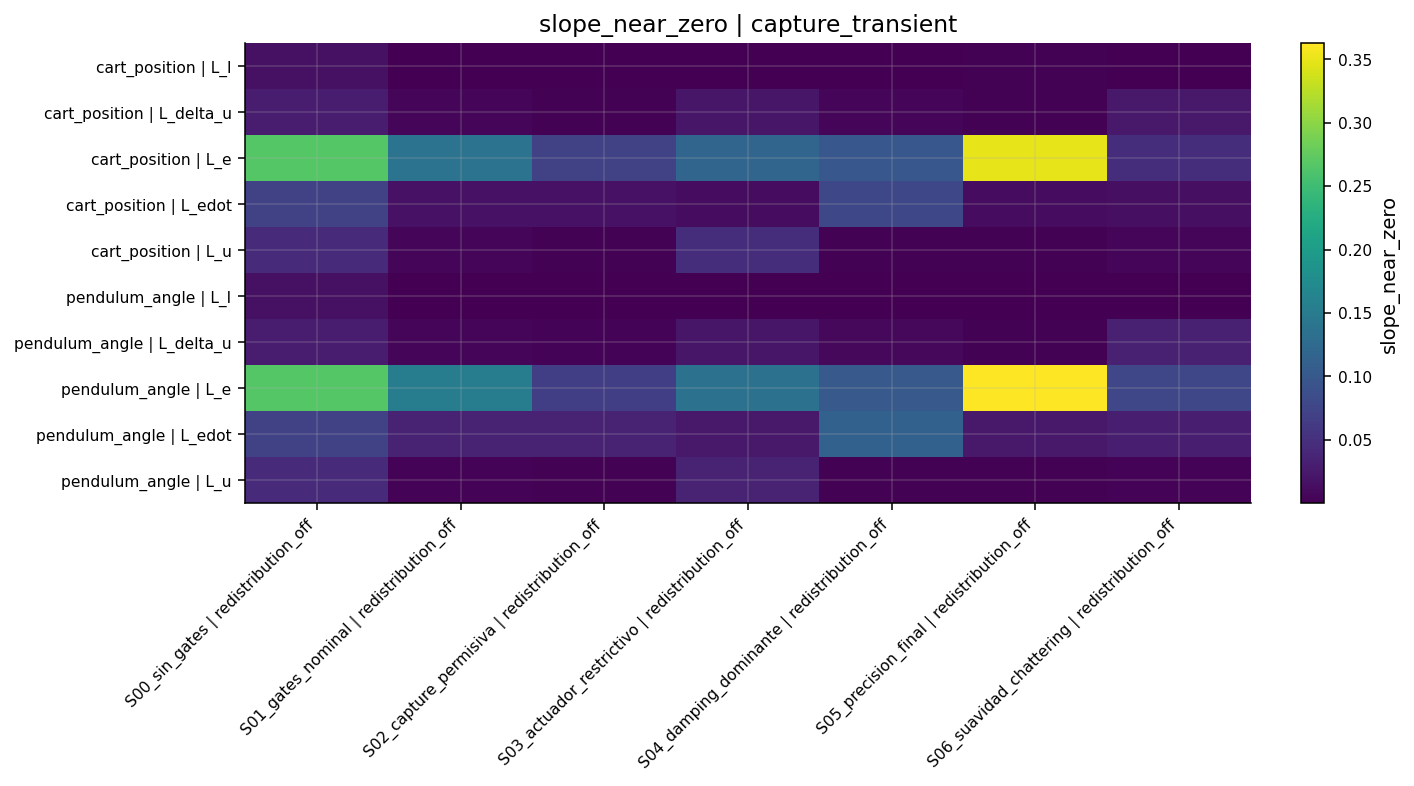

### Heatmap: slope_near_zero | capture_transient

col_label,S00_sin_gates | redistribution_off,S01_gates_nominal | redistribution_off,S02_capture_permisiva | redistribution_off,S03_actuador_restrictivo | redistribution_off,S04_damping_dominante | redistribution_off,S05_precision_final | redistribution_off,S06_suavidad_chattering | redistribution_off
row_label,,,,,,,
cart_position | L_I,0.01611,0.00081,0.00081,0.00069,0.00069,0.00219,0.00069
cart_position | L_delta_u,0.02960,0.00444,0.00237,0.02237,0.00658,0.00173,0.02413
cart_position | L_e,0.26663,0.13869,0.06957,0.11755,0.09898,0.34931,0.04783
cart_position | L_edot,0.07155,0.01789,0.01789,0.01253,0.07830,0.01253,0.01489
cart_position | L_u,0.04429,0.00531,0.00221,0.04714,0.00258,0.00258,0.00442
pendulum_angle | L_I,0.01611,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
pendulum_angle | L_delta_u,0.02960,0.00533,0.00296,0.02237,0.00790,0.00207,0.03291
pendulum_angle | L_e,0.26663,0.15393,0.06665,0.13506,0.10094,0.36253,0.07713
pendulum_angle | L_edot,0.07155,0.03577,0.03577,0.02507,0.11310,0.02507,0.02978


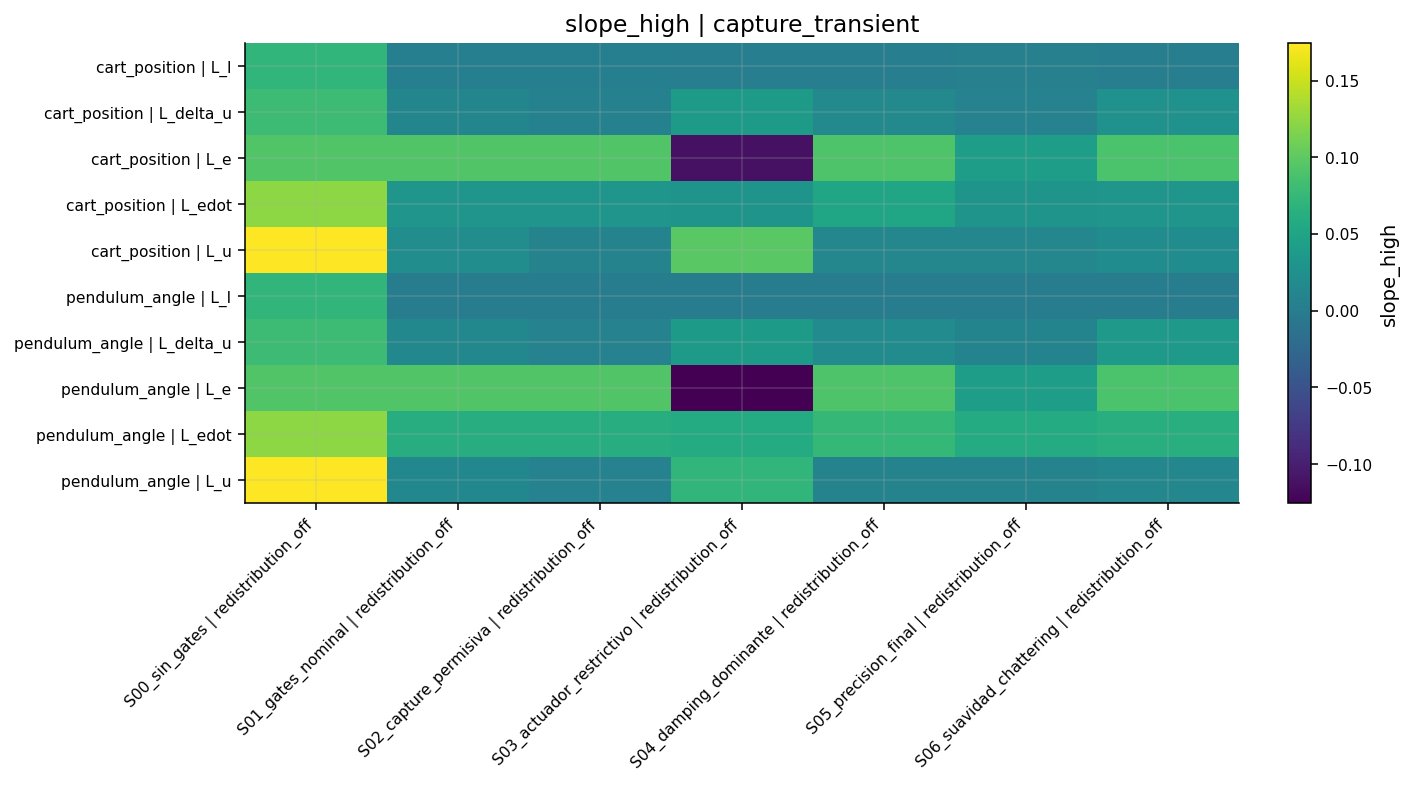

### Heatmap: slope_high | capture_transient

col_label,S00_sin_gates | redistribution_off,S01_gates_nominal | redistribution_off,S02_capture_permisiva | redistribution_off,S03_actuador_restrictivo | redistribution_off,S04_damping_dominante | redistribution_off,S05_precision_final | redistribution_off,S06_suavidad_chattering | redistribution_off
row_label,,,,,,,
cart_position | L_I,0.07203,0.00360,0.00360,0.00309,0.00309,0.00518,0.00309
cart_position | L_delta_u,0.07948,0.01192,0.00636,0.03845,0.01555,0.00772,0.02654
cart_position | L_e,0.09309,0.09309,0.09309,-0.11196,0.09154,0.04209,0.08893
cart_position | L_edot,0.12295,0.03074,0.03074,0.02962,0.05171,0.02962,0.03098
cart_position | L_u,0.17431,0.02092,0.00872,0.09808,0.01308,0.01308,0.01976
pendulum_angle | L_I,0.07203,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
pendulum_angle | L_delta_u,0.07948,0.01431,0.00795,0.03845,0.01866,0.00926,0.03620
pendulum_angle | L_e,0.09309,0.09309,0.09309,-0.12552,0.09154,0.04209,0.08893
pendulum_angle | L_edot,0.12295,0.06147,0.06147,0.05925,0.07469,0.05925,0.06197


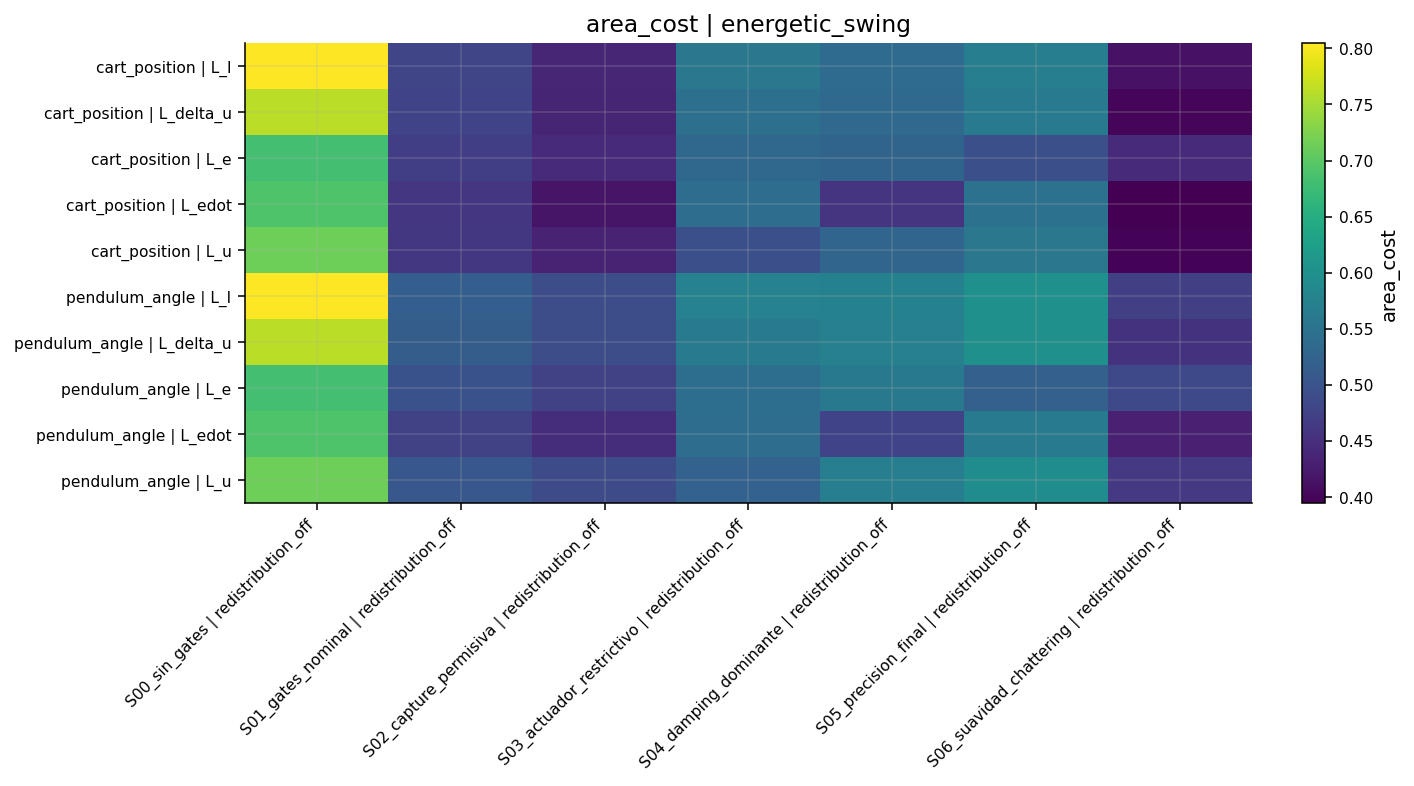

### Heatmap: area_cost | energetic_swing

col_label,S00_sin_gates | redistribution_off,S01_gates_nominal | redistribution_off,S02_capture_permisiva | redistribution_off,S03_actuador_restrictivo | redistribution_off,S04_damping_dominante | redistribution_off,S05_precision_final | redistribution_off,S06_suavidad_chattering | redistribution_off
row_label,,,,,,,
cart_position | L_I,0.80450,0.48053,0.43937,0.55930,0.53855,0.56966,0.41427
cart_position | L_delta_u,0.76264,0.47717,0.43694,0.54533,0.53450,0.56552,0.40107
cart_position | L_e,0.68271,0.47002,0.44278,0.53162,0.52731,0.49528,0.44402
cart_position | L_edot,0.69193,0.45881,0.41765,0.54151,0.45618,0.54965,0.39456
cart_position | L_u,0.71450,0.46167,0.43475,0.49543,0.52791,0.55681,0.39780
pendulum_angle | L_I,0.80450,0.51685,0.49187,0.57591,0.57502,0.60015,0.47236
pendulum_angle | L_delta_u,0.76264,0.51508,0.49088,0.56331,0.57233,0.59960,0.45525
pendulum_angle | L_e,0.68271,0.49791,0.47433,0.54276,0.55979,0.51985,0.48457
pendulum_angle | L_edot,0.69193,0.47344,0.44846,0.54049,0.47625,0.56473,0.43281


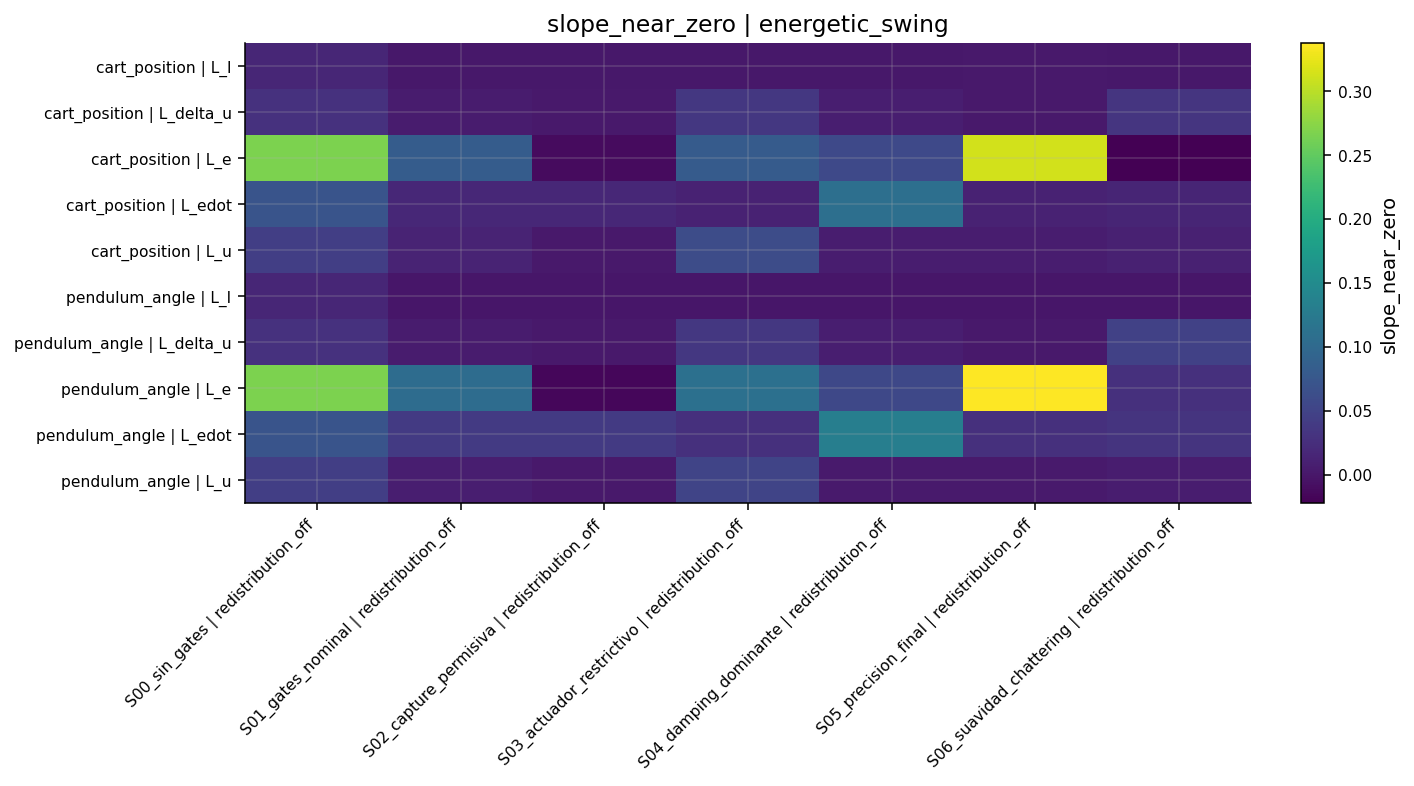

### Heatmap: slope_near_zero | energetic_swing

col_label,S00_sin_gates | redistribution_off,S01_gates_nominal | redistribution_off,S02_capture_permisiva | redistribution_off,S03_actuador_restrictivo | redistribution_off,S04_damping_dominante | redistribution_off,S05_precision_final | redistribution_off,S06_suavidad_chattering | redistribution_off
row_label,,,,,,,
cart_position | L_I,0.01611,0.00081,0.00081,0.00069,0.00069,0.00219,0.00069
cart_position | L_delta_u,0.02960,0.00533,0.00251,0.03552,0.00790,0.00207,0.03271
cart_position | L_e,0.26663,0.08272,-0.01196,0.08103,0.05758,0.31245,-0.02231
cart_position | L_edot,0.07155,0.01789,0.01789,0.01253,0.10846,0.01253,0.01489
cart_position | L_u,0.04429,0.01321,0.00231,0.06114,0.00640,0.00640,0.01098
pendulum_angle | L_I,0.01611,0.00001,0.00001,0.00001,0.00001,0.00000,0.00001
pendulum_angle | L_delta_u,0.02960,0.00533,0.00296,0.03552,0.00790,0.00207,0.04735
pendulum_angle | L_e,0.26663,0.10543,-0.01611,0.11088,0.05636,0.33749,0.02784
pendulum_angle | L_edot,0.07155,0.03859,0.03859,0.02704,0.13224,0.02704,0.03213


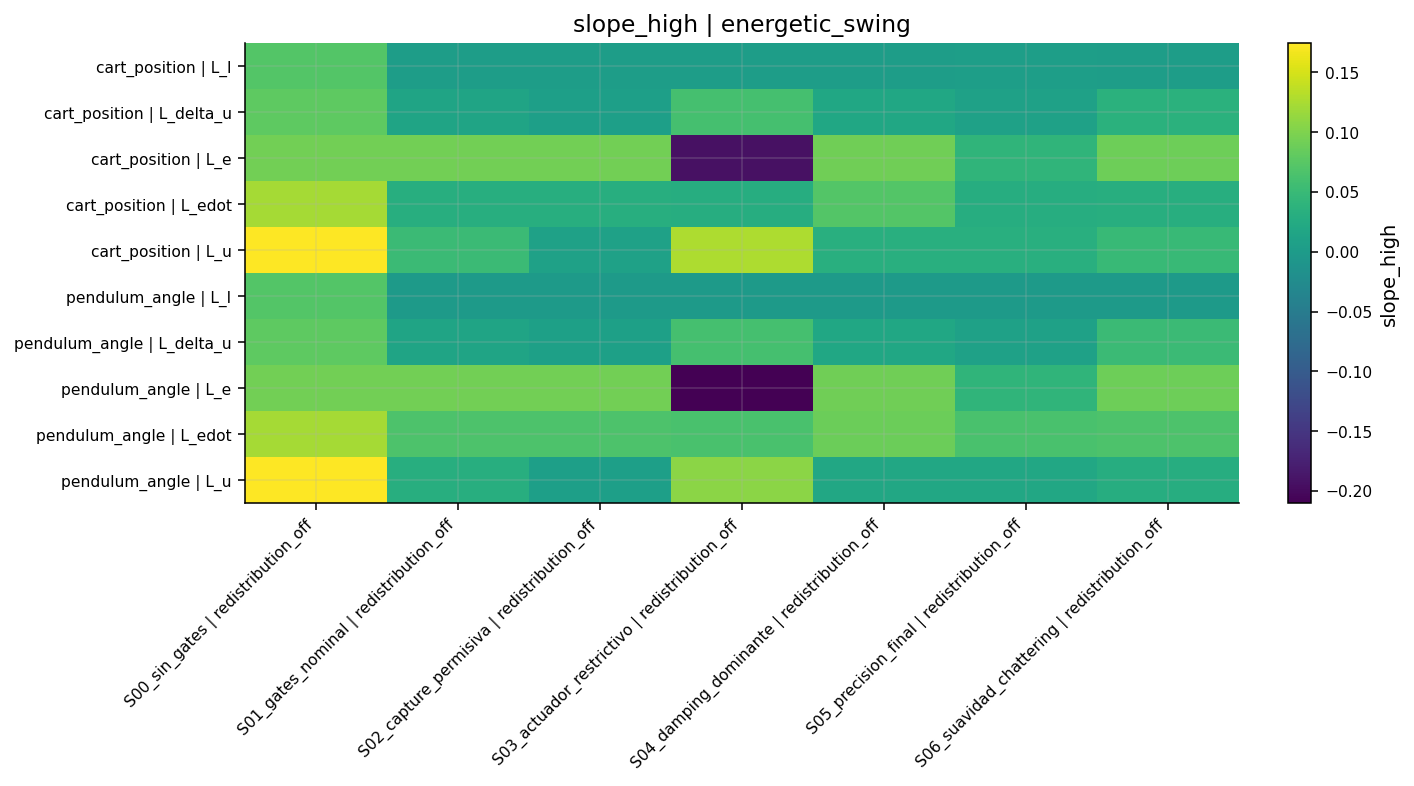

### Heatmap: slope_high | energetic_swing

col_label,S00_sin_gates | redistribution_off,S01_gates_nominal | redistribution_off,S02_capture_permisiva | redistribution_off,S03_actuador_restrictivo | redistribution_off,S04_damping_dominante | redistribution_off,S05_precision_final | redistribution_off,S06_suavidad_chattering | redistribution_off
row_label,,,,,,,
cart_position | L_I,0.07203,0.00360,0.00360,0.00309,0.00309,0.00518,0.00309
cart_position | L_delta_u,0.07948,0.01431,0.00673,0.06104,0.01866,0.00926,0.03598
cart_position | L_e,0.09309,0.09309,0.09309,-0.19375,0.09154,0.04209,0.08893
cart_position | L_edot,0.12295,0.03074,0.03074,0.02962,0.07163,0.02962,0.03098
cart_position | L_u,0.17431,0.05198,0.00909,0.12720,0.03251,0.03251,0.04909
pendulum_angle | L_I,0.07203,0.00004,0.00004,0.00003,0.00003,0.00001,0.00003
pendulum_angle | L_delta_u,0.07948,0.01431,0.00795,0.06104,0.01866,0.00926,0.05207
pendulum_angle | L_e,0.09309,0.09309,0.09309,-0.21029,0.09154,0.04209,0.08893
pendulum_angle | L_edot,0.12295,0.06631,0.06631,0.06391,0.08734,0.06391,0.06685


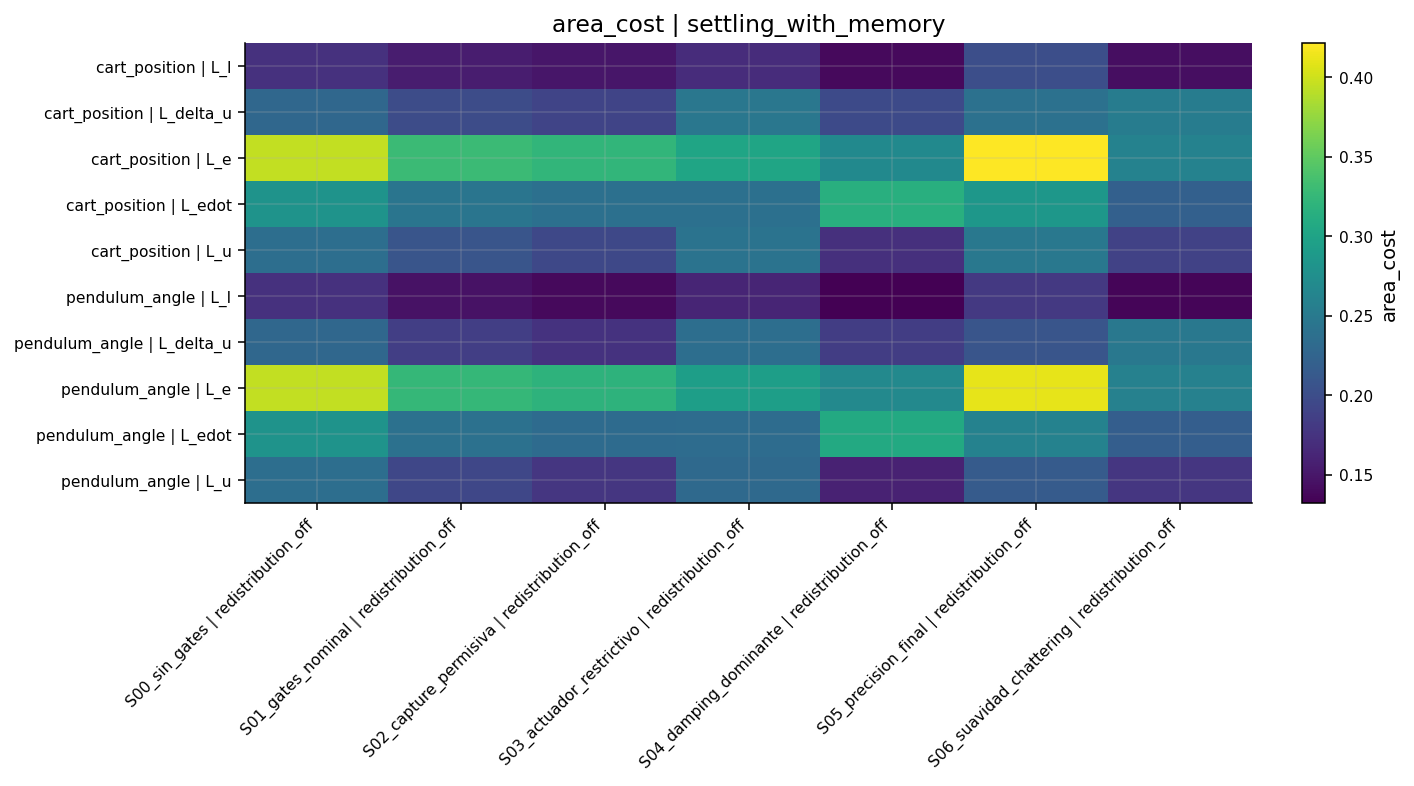

### Heatmap: area_cost | settling_with_memory

col_label,S00_sin_gates | redistribution_off,S01_gates_nominal | redistribution_off,S02_capture_permisiva | redistribution_off,S03_actuador_restrictivo | redistribution_off,S04_damping_dominante | redistribution_off,S05_precision_final | redistribution_off,S06_suavidad_chattering | redistribution_off
row_label,,,,,,,
cart_position | L_I,0.17345,0.15533,0.14929,0.16870,0.13956,0.20206,0.14256
cart_position | L_delta_u,0.22896,0.19969,0.19095,0.24685,0.19714,0.24009,0.25321
cart_position | L_e,0.39539,0.32918,0.32277,0.30225,0.26988,0.42140,0.26053
cart_position | L_edot,0.28081,0.24471,0.23867,0.23862,0.31450,0.28553,0.22121
cart_position | L_u,0.23656,0.20831,0.19486,0.24247,0.17172,0.24777,0.18927
pendulum_angle | L_I,0.17345,0.14643,0.13929,0.16143,0.13199,0.18059,0.13639
pendulum_angle | L_delta_u,0.22896,0.18595,0.17456,0.23663,0.18464,0.20833,0.24821
pendulum_angle | L_e,0.39539,0.32472,0.31933,0.29447,0.26843,0.41063,0.25941
pendulum_angle | L_edot,0.28081,0.24022,0.23308,0.23447,0.30756,0.26050,0.21901


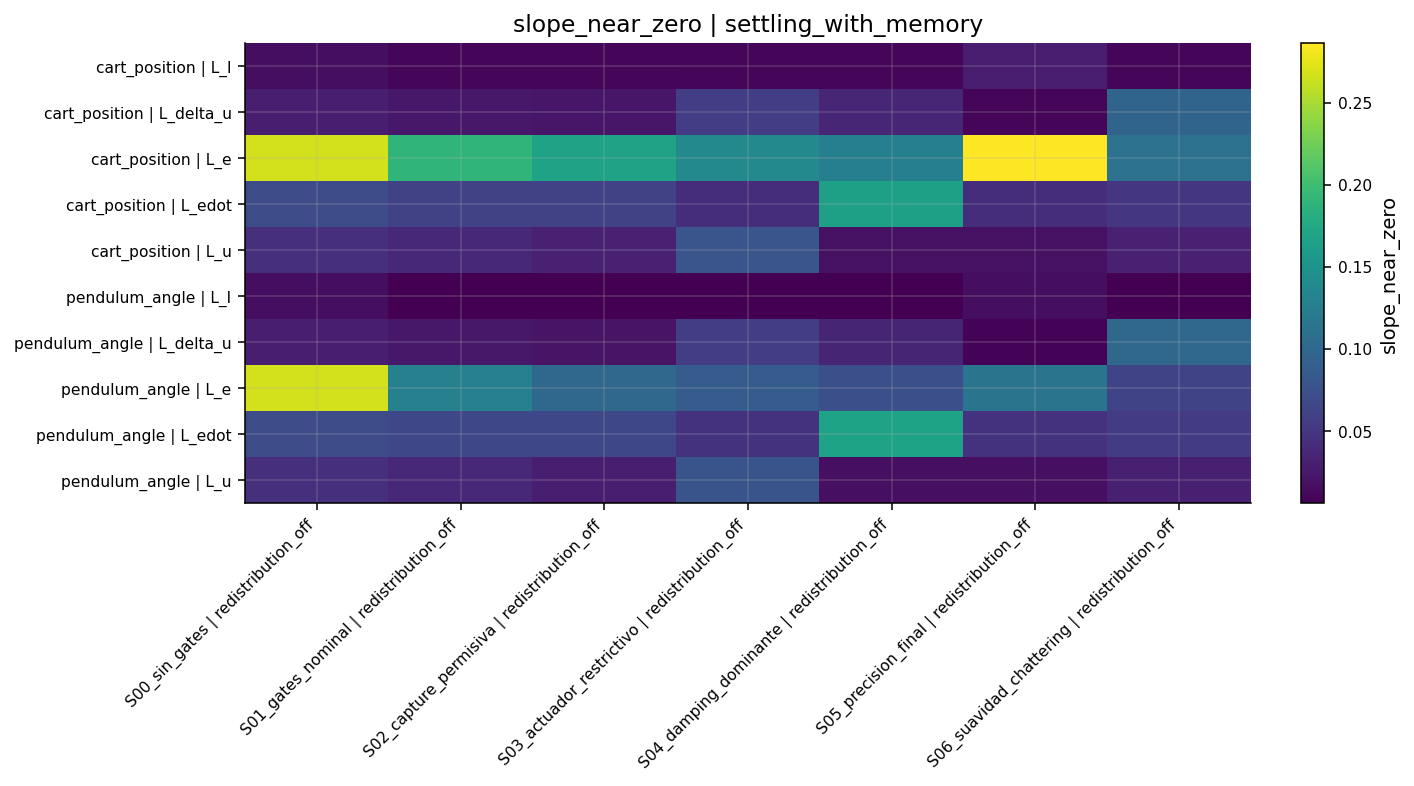

### Heatmap: slope_near_zero | settling_with_memory

col_label,S00_sin_gates | redistribution_off,S01_gates_nominal | redistribution_off,S02_capture_permisiva | redistribution_off,S03_actuador_restrictivo | redistribution_off,S04_damping_dominante | redistribution_off,S05_precision_final | redistribution_off,S06_suavidad_chattering | redistribution_off
row_label,,,,,,,
cart_position | L_I,0.01611,0.01124,0.01124,0.00963,0.00963,0.02902,0.00963
cart_position | L_delta_u,0.02960,0.02464,0.02272,0.05741,0.03651,0.00958,0.09637
cart_position | L_e,0.26663,0.18955,0.16707,0.13812,0.12731,0.28615,0.11069
cart_position | L_edot,0.07155,0.06097,0.06097,0.04272,0.16540,0.04272,0.05076
cart_position | L_u,0.04429,0.03891,0.03228,0.08010,0.01886,0.01886,0.03235
pendulum_angle | L_I,0.01611,0.00717,0.00717,0.00614,0.00614,0.01614,0.00614
pendulum_angle | L_delta_u,0.02960,0.02365,0.02065,0.05741,0.03505,0.00919,0.10026
pendulum_angle | L_e,0.26663,0.12841,0.10012,0.08743,0.07500,0.11430,0.06330
pendulum_angle | L_edot,0.07155,0.06697,0.06697,0.04693,0.16895,0.04693,0.05576


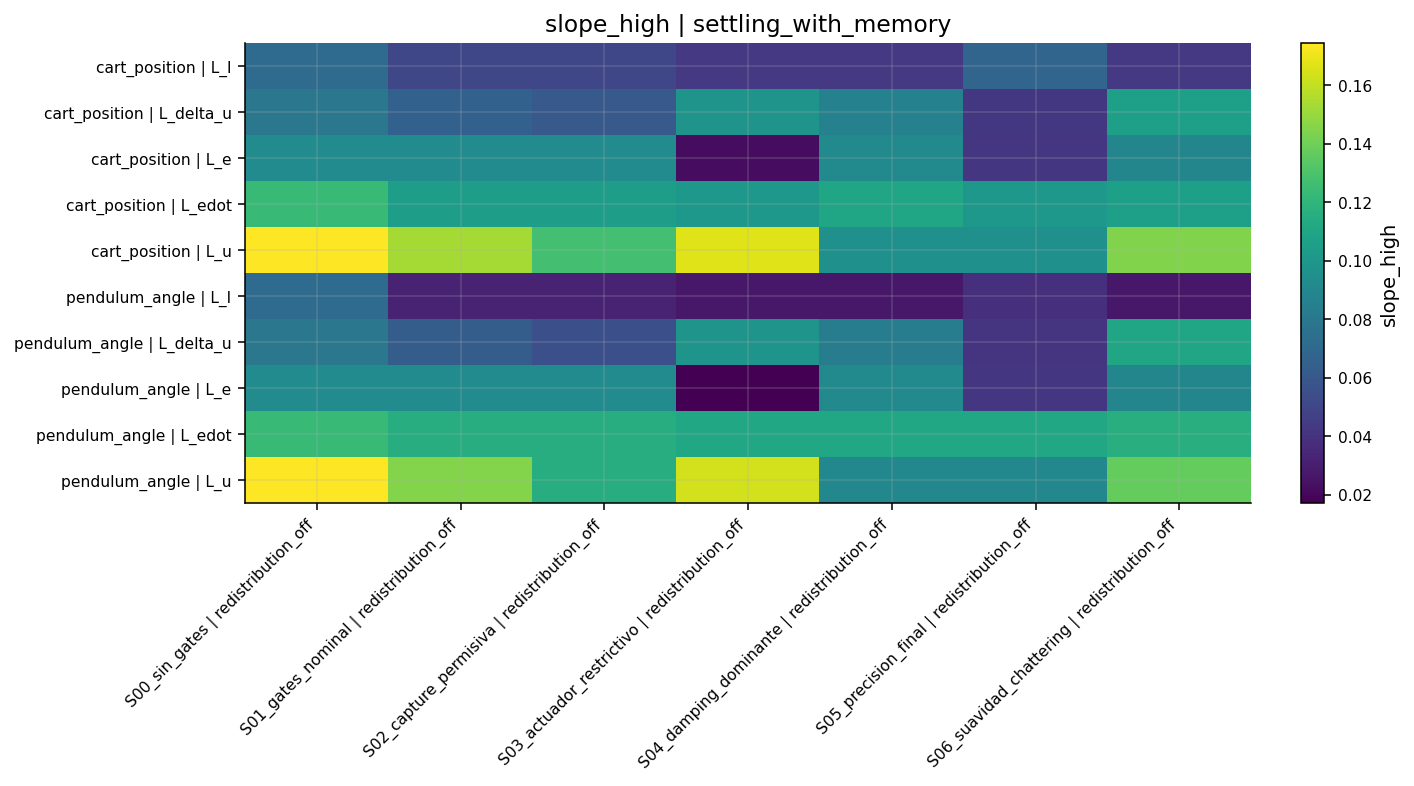

### Heatmap: slope_high | settling_with_memory

col_label,S00_sin_gates | redistribution_off,S01_gates_nominal | redistribution_off,S02_capture_permisiva | redistribution_off,S03_actuador_restrictivo | redistribution_off,S04_damping_dominante | redistribution_off,S05_precision_final | redistribution_off,S06_suavidad_chattering | redistribution_off
row_label,,,,,,,
cart_position | L_I,0.07203,0.05025,0.05025,0.04307,0.04307,0.06858,0.04307
cart_position | L_delta_u,0.07948,0.06615,0.06101,0.09866,0.08629,0.04282,0.10599
cart_position | L_e,0.09309,0.09309,0.09309,0.02200,0.09154,0.04209,0.08893
cart_position | L_edot,0.12295,0.10477,0.10477,0.10097,0.10924,0.10097,0.10561
cart_position | L_u,0.17431,0.15312,0.12703,0.16664,0.09578,0.09578,0.14462
pendulum_angle | L_I,0.07203,0.03204,0.03204,0.02746,0.02746,0.03814,0.02746
pendulum_angle | L_delta_u,0.07948,0.06351,0.05545,0.09866,0.08284,0.04111,0.11027
pendulum_angle | L_e,0.09309,0.09309,0.09309,0.01705,0.09154,0.04209,0.08893
pendulum_angle | L_edot,0.12295,0.11508,0.11508,0.11091,0.11158,0.11091,0.11600


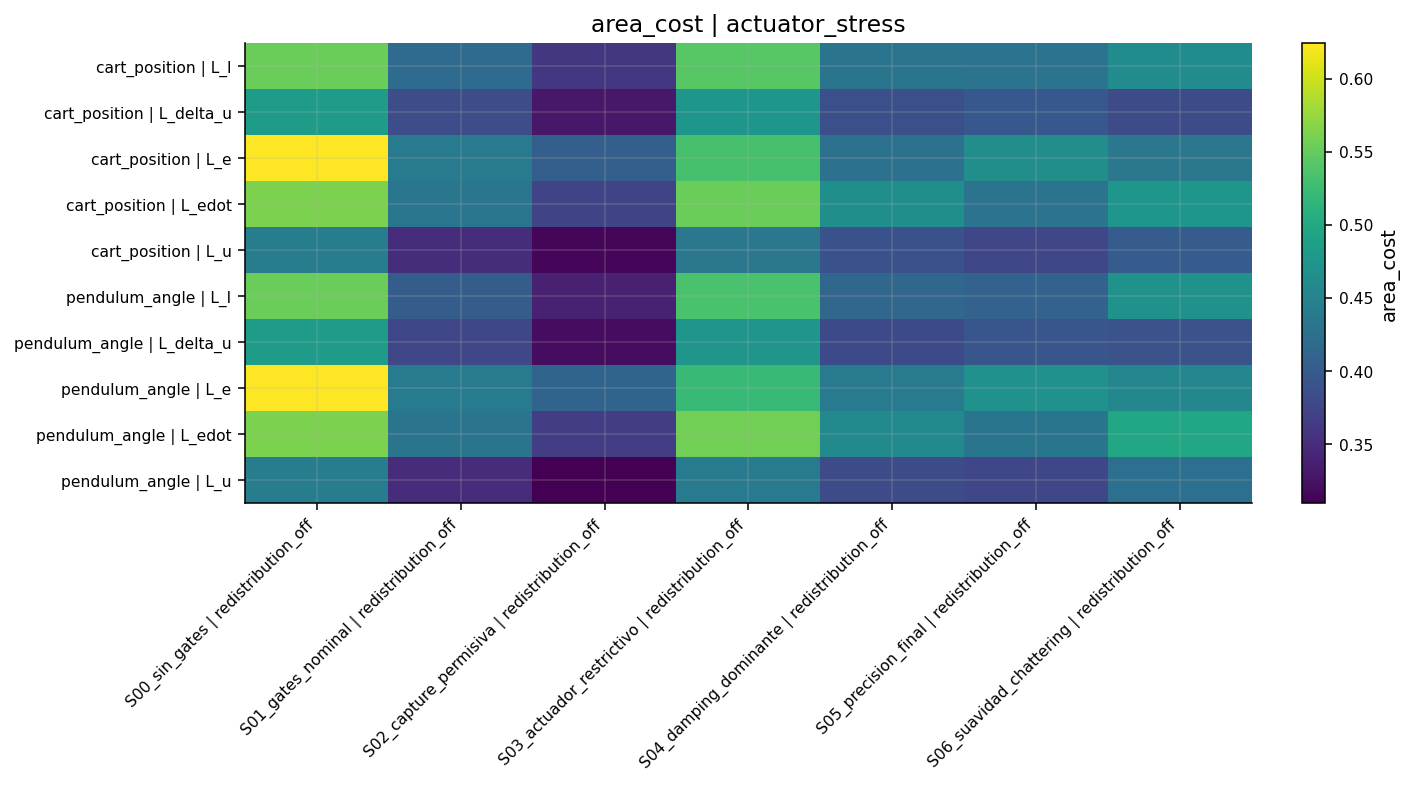

### Heatmap: area_cost | actuator_stress

col_label,S00_sin_gates | redistribution_off,S01_gates_nominal | redistribution_off,S02_capture_permisiva | redistribution_off,S03_actuador_restrictivo | redistribution_off,S04_damping_dominante | redistribution_off,S05_precision_final | redistribution_off,S06_suavidad_chattering | redistribution_off
row_label,,,,,,,
cart_position | L_I,0.55342,0.41923,0.36053,0.54241,0.43015,0.42942,0.46142
cart_position | L_delta_u,0.48316,0.38378,0.33006,0.47501,0.38653,0.39672,0.38180
cart_position | L_e,0.62421,0.43900,0.40544,0.53318,0.42759,0.46569,0.43398
cart_position | L_edot,0.56188,0.43257,0.37387,0.55359,0.46580,0.42961,0.47466
cart_position | L_u,0.44192,0.35099,0.31560,0.43445,0.38845,0.37673,0.40061
pendulum_angle | L_I,0.55342,0.40212,0.33891,0.53411,0.41403,0.40890,0.47167
pendulum_angle | L_delta_u,0.48316,0.37692,0.32066,0.47322,0.38062,0.39372,0.39037
pendulum_angle | L_e,0.62421,0.44065,0.41104,0.52225,0.43777,0.46833,0.45553
pendulum_angle | L_edot,0.56188,0.43021,0.36700,0.55785,0.45892,0.43132,0.49809


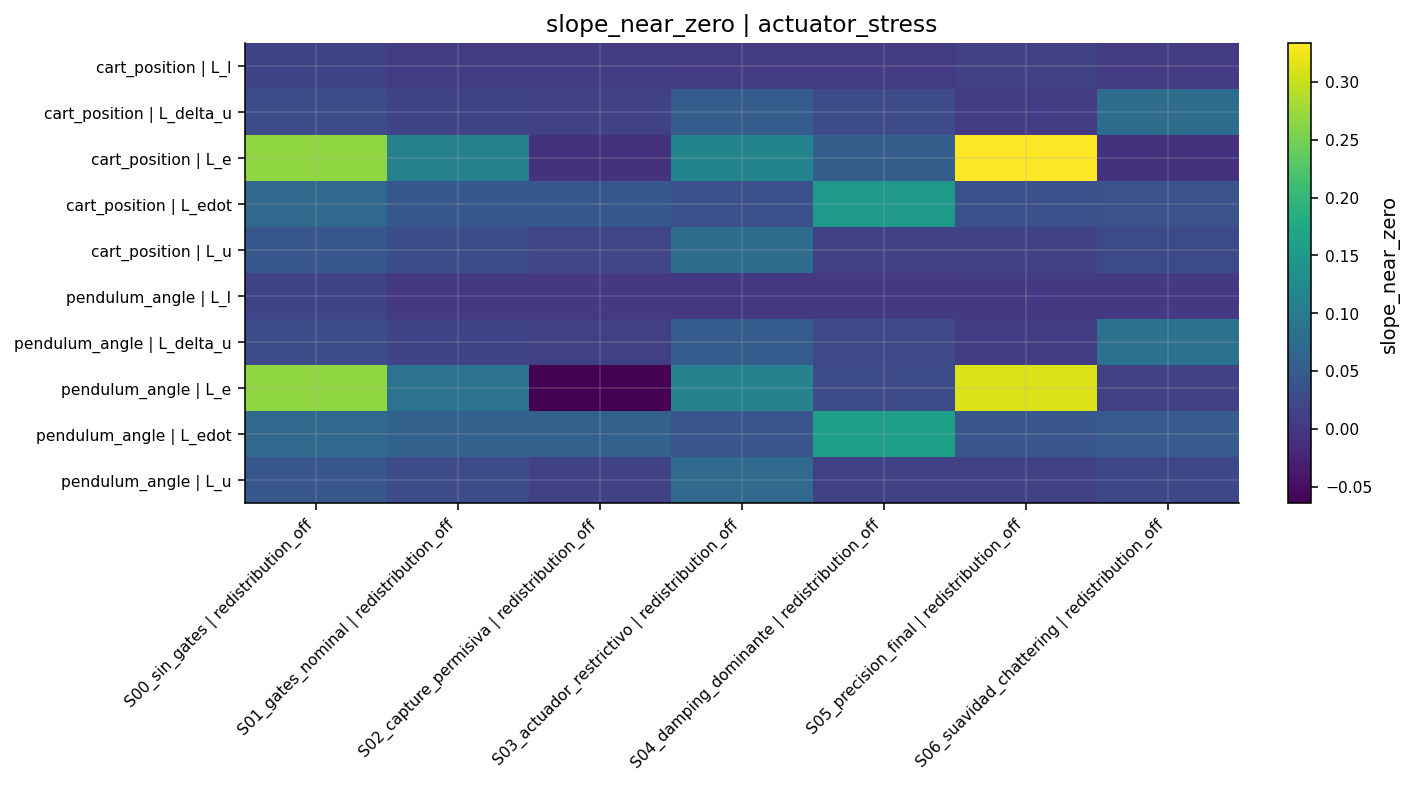

### Heatmap: slope_near_zero | actuator_stress

col_label,S00_sin_gates | redistribution_off,S01_gates_nominal | redistribution_off,S02_capture_permisiva | redistribution_off,S03_actuador_restrictivo | redistribution_off,S04_damping_dominante | redistribution_off,S05_precision_final | redistribution_off,S06_suavidad_chattering | redistribution_off
row_label,,,,,,,
cart_position | L_I,0.01611,0.00593,0.00593,0.00508,0.00508,0.01392,0.00508
cart_position | L_delta_u,0.02960,0.01777,0.01420,0.05182,0.02634,0.00691,0.07654
cart_position | L_e,0.26663,0.10940,-0.00663,0.11493,0.05290,0.33317,-0.00606
cart_position | L_edot,0.07155,0.04588,0.04588,0.03215,0.15117,0.03215,0.03819
cart_position | L_u,0.04429,0.03090,0.01839,0.07561,0.01498,0.01498,0.02569
pendulum_angle | L_I,0.01611,0.00170,0.00170,0.00146,0.00146,0.00273,0.00146
pendulum_angle | L_delta_u,0.02960,0.01587,0.01089,0.05182,0.02352,0.00617,0.08544
pendulum_angle | L_e,0.26663,0.08669,-0.06416,0.11233,0.02869,0.31197,0.01341
pendulum_angle | L_edot,0.07155,0.05954,0.05954,0.04172,0.16035,0.04172,0.04957


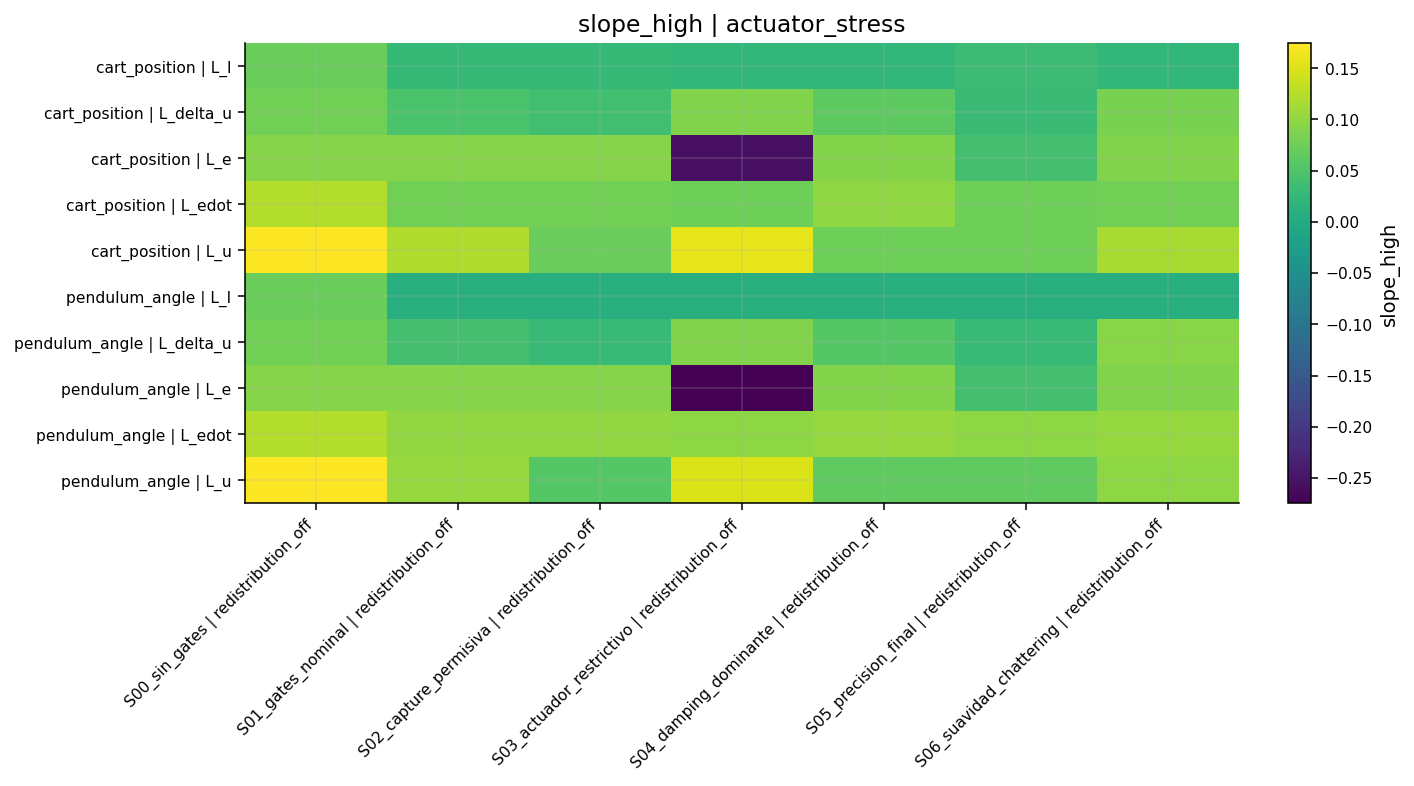

### Heatmap: slope_high | actuator_stress

col_label,S00_sin_gates | redistribution_off,S01_gates_nominal | redistribution_off,S02_capture_permisiva | redistribution_off,S03_actuador_restrictivo | redistribution_off,S04_damping_dominante | redistribution_off,S05_precision_final | redistribution_off,S06_suavidad_chattering | redistribution_off
row_label,,,,,,,
cart_position | L_I,0.07203,0.02650,0.02650,0.02271,0.02271,0.03290,0.02271
cart_position | L_delta_u,0.07948,0.04772,0.03812,0.08905,0.06225,0.03089,0.08418
cart_position | L_e,0.09309,0.09309,0.09309,-0.25633,0.09154,0.04209,0.08893
cart_position | L_edot,0.12295,0.07883,0.07883,0.07598,0.09984,0.07598,0.07946
cart_position | L_u,0.17431,0.12161,0.07238,0.15731,0.07607,0.07607,0.11486
pendulum_angle | L_I,0.07203,0.00759,0.00759,0.00651,0.00651,0.00645,0.00651
pendulum_angle | L_delta_u,0.07948,0.04262,0.02924,0.08905,0.05559,0.02759,0.09396
pendulum_angle | L_e,0.09309,0.09309,0.09309,-0.27466,0.09154,0.04209,0.08893
pendulum_angle | L_edot,0.12295,0.10232,0.10232,0.09861,0.10590,0.09861,0.10314


In [41]:
# ---------------------------------------------------------------------
# 1.8 Parametros editables del heatmap de sensibilidad
# ---------------------------------------------------------------------

section1_sensitivity_physical_regimes = [
    "near_setpoint",
    "capture_transient",
    "energetic_swing",
    "settling_with_memory",
    "actuator_stress",
]

section1_sensitivity_metric_names = [
    "area_cost",
    "slope_near_zero",
    "slope_high",
]

for section1_sensitivity_physical_regime in section1_sensitivity_physical_regimes:
    for section1_sensitivity_metric_name in section1_sensitivity_metric_names:
        fig, ax, section1_sensitivity_matrix_df = section1_plot_sensitivity_heatmap(
            metrics_df=section1_sensitivity_df,
            physical_regime_name=section1_sensitivity_physical_regime,
            metric_name=section1_sensitivity_metric_name,
        )
        save_figure(
            "fig_01D_sensitivity_heatmap_"
            f"{section1_sensitivity_metric_name}_{section1_sensitivity_physical_regime}.png"
        )
        plt.show()

        display(Markdown(
            f"### Heatmap: {section1_sensitivity_metric_name} | {section1_sensitivity_physical_regime}"
        ))
        display(section1_sensitivity_matrix_df.round(5))

## 1. Perfil constitutivo de recompensa principal por lazo

Esta seccion se limita a la algebra de `principal_reward`. No usa coordinacion, extras, agente, `td_error`, `q_value`, `epsilon` ni resultados historicos.

La lectura buscada es constitutiva: para cada lazo (`var_obj`) se barre una unica magnitud fisica normalizada `L_*_<var_obj>` en `[0, 1]`, manteniendo las otras features en un regimen fisico de fondo. Cada linea del spaghetti plot representa una configuracion parametrica distinta de `principal_reward.weighted_exponential_params`, y el estilo de linea representa `redistribution_off` o `redistribution_on`.

### Variables de entrada principales

| Variable | Rol en la seccion |
|---|---|
| `section1_var_objs` | Lazos observados. Ejemplo: `pendulum_angle`, `cart_position`. |
| `section1_feature_axis_names` | Features fisicas normalizadas que se barren en el eje x: `L_e`, `L_edot`, `L_I`, `L_u`, `L_delta_u`. |
| `section1_physical_regimes` | Estados fisicos de fondo. Mantienen fijas las otras features mientras se barre una. |
| `section1_weighted_exponential_params_by_scenario` | Variantes de `principal_reward.weighted_exponential_params`. Cada entrada es una familia de curvas. |
| `section1_budget_mode_configs` | Comparacion entre `redistribution_off` y `redistribution_on`. |
| `section1_profile_y_name` | Variable que se pone en eje y: costo positivo, score o reward con signo negativo. |

In [8]:
# ---------------------------------------------------------------------
# 1.0 Funciones de la seccion 1
# ---------------------------------------------------------------------
# No editar para cambiar escenarios.
# Las variables editables estan en las celdas 1.1 a 1.4.
# ---------------------------------------------------------------------

def section1_complete_weighted_exponential_params(weighted_exponential_params, feature_names):
    params = copy.deepcopy(weighted_exponential_params)
    params.setdefault("features", {})
    params.setdefault("feature_gates", {})

    for feature_name in feature_names:
        params["features"].setdefault(feature_name, {"weight": 0.0, "scaled": 1.0, "setpoint": 0.0})

    return params


def section1_effective_base_weights(features, normalized_reward_mode):
    positive_sum = sum(max(0.0, features[feature_name]["weight"]) for feature_name in features.keys())
    if positive_sum <= 0.0:
        positive_sum = 1.0

    weights = {}
    for feature_name, feature_cfg in features.items():
        if normalized_reward_mode:
            weights[feature_name] = max(0.0, feature_cfg["weight"]) / positive_sum
        else:
            weights[feature_name] = feature_cfg["weight"]
    return weights


def section1_exponential_cost_01(values, scaled, setpoint):
    values = np.clip(np.abs(np.asarray(values, dtype=float)), 0.0, 1.0)
    raw_cost = 1.0 - np.exp(-scaled * ((values - setpoint) ** 2))
    bound_0 = 1.0 - math.exp(-scaled * ((0.0 - setpoint) ** 2))
    bound_1 = 1.0 - math.exp(-scaled * ((1.0 - setpoint) ** 2))
    raw_bound = max(bound_0, bound_1, 1.0e-12)
    return np.clip(raw_cost / raw_bound, 0.0, 1.0)


def section1_resolve_gate_config(feature_gates, feature_name, var_obj):
    gate_cfg = copy.deepcopy(feature_gates.get(feature_name, {}))
    if not gate_cfg.get("enabled", False):
        return None

    per_var = gate_cfg.pop("per_var", {})
    gate_cfg.update(per_var.get(var_obj, {}))
    gate_cfg["source"] = gate_cfg.get("source", "L_e_{var_obj}").format(var_obj=var_obj)
    gate_cfg.setdefault("type", "exp")
    gate_cfg.setdefault("scaled", gate_cfg.get("strength", 1.0))
    gate_cfg.setdefault("setpoint", gate_cfg.get("x_sp", 0.0))
    gate_cfg.setdefault("use_sqrt", False)
    gate_cfg.setdefault("use_abs", True)
    gate_cfg.setdefault("invert", False)
    gate_cfg.setdefault("min_factor", 0.0)
    gate_cfg.setdefault("max_factor", 1.0)
    return gate_cfg


def section1_gate_factor(values_by_key, gate_cfg):
    if gate_cfg is None:
        sample = next(iter(values_by_key.values()))
        return np.ones_like(sample, dtype=float)

    value = np.asarray(values_by_key[gate_cfg["source"]], dtype=float)
    if gate_cfg["use_abs"]:
        value = np.abs(value)
    if gate_cfg["use_sqrt"]:
        value = np.sqrt(np.maximum(value, 0.0))

    gain = gate_cfg.get("strength", gate_cfg["scaled"])
    setpoint = gate_cfg.get("x_sp", gate_cfg["setpoint"])

    if gate_cfg["type"] == "exp":
        factor = np.exp(-(((value - setpoint) / gain) ** 2)) if gain > 0 else np.zeros_like(value)
    else:
        factor = np.tanh(gain * np.abs(value - setpoint))

    if gate_cfg["invert"]:
        factor = 1.0 - factor

    return np.clip(factor, gate_cfg["min_factor"], gate_cfg["max_factor"])


def section1_budget_allocation(base_weights, gate_factors, budget_cfg, normalized_reward_mode):
    effective_weights = {}
    residual_weights = {}

    for feature_name, base_weight in base_weights.items():
        gate_factor = gate_factors[feature_name]
        gated_weight = base_weight * gate_factor
        residual_weight = base_weight - gated_weight
        effective_weights[feature_name] = gated_weight
        residual_weights[feature_name] = residual_weight

    if not (normalized_reward_mode and budget_cfg.get("enabled", False)):
        return effective_weights, residual_weights

    redistribution = budget_cfg.get("redistribution", {})
    strict_weight_sum = budget_cfg.get("strict_weight_sum", True)

    for source_feature, residual_weight in residual_weights.items():
        if np.all(residual_weight <= 0.0):
            continue

        target_map = redistribution.get(source_feature)
        if not target_map:
            if strict_weight_sum:
                continue
            effective_weights[source_feature] = effective_weights[source_feature] + residual_weight
            continue

        target_total = sum(target_map.values())
        if target_total <= 0.0:
            continue

        for target_feature, ratio in target_map.items():
            effective_weights[target_feature] = effective_weights[target_feature] + residual_weight * (ratio / target_total)

    return effective_weights, residual_weights


def section1_compute_profile(
    scenario_name,
    budget_mode,
    var_obj,
    feature_axis_name,
    physical_regime_name,
    fixed_feature_values,
    weighted_exponential_params,
    budget_cfg,
    feature_names,
    n_points,
    normalized_reward_mode,
):
    feature_axis_value = np.linspace(0.0, 1.0, n_points)
    params = section1_complete_weighted_exponential_params(weighted_exponential_params, feature_names)
    features = {feature_name: params["features"][feature_name] for feature_name in feature_names}
    feature_gates = params.get("feature_gates", {})

    values_by_key = {}
    values_by_feature = {}
    for feature_name in feature_names:
        values = np.full_like(feature_axis_value, fixed_feature_values[feature_name], dtype=float)
        if feature_name == feature_axis_name:
            values = feature_axis_value.copy()
        values_by_feature[feature_name] = values
        values_by_key[f"{feature_name}_{var_obj}"] = values

    base_weights = section1_effective_base_weights(features, normalized_reward_mode)
    base_weight_series = {
        feature_name: np.full_like(feature_axis_value, base_weight, dtype=float)
        for feature_name, base_weight in base_weights.items()
    }

    cost_01 = {}
    raw_cost = {}
    gates = {}
    for feature_name in feature_names:
        feature_cfg = features[feature_name]
        cost_01[feature_name] = section1_exponential_cost_01(
            values_by_feature[feature_name],
            feature_cfg["scaled"],
            feature_cfg.get("setpoint", 0.0),
        )
        raw_cost[feature_name] = 1.0 - np.exp(
            -feature_cfg["scaled"] * ((values_by_feature[feature_name] - feature_cfg.get("setpoint", 0.0)) ** 2)
        )
        gates[feature_name] = section1_gate_factor(
            values_by_key,
            section1_resolve_gate_config(feature_gates, feature_name, var_obj),
        )

    effective_weights, residual_weights = section1_budget_allocation(
        base_weight_series,
        gates,
        budget_cfg,
        normalized_reward_mode,
    )

    frame = pd.DataFrame({
        "scenario_name": scenario_name,
        "budget_mode": budget_mode,
        "var_obj": var_obj,
        "feature_axis_name": feature_axis_name,
        "physical_regime": physical_regime_name,
        "feature_axis_value": feature_axis_value,
    })

    principal_loop_reward = np.zeros_like(feature_axis_value, dtype=float)
    principal_loop_cost_01 = np.zeros_like(feature_axis_value, dtype=float)

    for feature_name in feature_names:
        if normalized_reward_mode:
            contribution = -effective_weights[feature_name] * cost_01[feature_name]
        else:
            contribution = -base_weight_series[feature_name] * gates[feature_name] * raw_cost[feature_name]

        frame[f"value_{feature_name}"] = values_by_feature[feature_name]
        frame[f"principal_feature_cost_01_{feature_name}_{var_obj}"] = cost_01[feature_name]
        frame[f"principal_gate_{feature_name}_{var_obj}"] = gates[feature_name]
        frame[f"principal_base_weight_{feature_name}_{var_obj}"] = base_weight_series[feature_name]
        frame[f"principal_effective_weight_{feature_name}_{var_obj}"] = effective_weights[feature_name]
        frame[f"principal_weight_residual_{feature_name}_{var_obj}"] = residual_weights[feature_name]
        frame[f"principal_contribution_{feature_name}_{var_obj}"] = contribution

        principal_loop_reward += contribution
        principal_loop_cost_01 += effective_weights[feature_name] * cost_01[feature_name]

    frame[f"principal_loop_cost_01_{var_obj}"] = principal_loop_cost_01
    frame[f"principal_score_01_{var_obj}"] = 1.0 - principal_loop_cost_01
    frame[f"L_{var_obj}"] = principal_loop_reward
    frame["principal_loop_reward"] = principal_loop_reward
    frame["principal_reward"] = principal_loop_reward
    frame["principal_loop_cost_01"] = principal_loop_cost_01
    return frame


def section1_build_profiles(
    var_objs,
    feature_axis_names,
    physical_regimes,
    weighted_exponential_params_by_scenario,
    budget_mode_configs,
    feature_names,
    n_points,
    normalized_reward_mode,
):
    frames = []
    for physical_regime_name, fixed_feature_values in physical_regimes.items():
        for scenario_name, weighted_exponential_params in weighted_exponential_params_by_scenario.items():
            for budget_mode, budget_cfg in budget_mode_configs.items():
                for var_obj in var_objs:
                    for feature_axis_name in feature_axis_names:
                        frames.append(section1_compute_profile(
                            scenario_name=scenario_name,
                            budget_mode=budget_mode,
                            var_obj=var_obj,
                            feature_axis_name=feature_axis_name,
                            physical_regime_name=physical_regime_name,
                            fixed_feature_values=fixed_feature_values,
                            weighted_exponential_params=weighted_exponential_params,
                            budget_cfg=budget_cfg,
                            feature_names=feature_names,
                            n_points=n_points,
                            normalized_reward_mode=normalized_reward_mode,
                        ))
    return pd.concat(frames, ignore_index=True)


def section1_build_regime_state_records(profiles_df, feature_names):
    rows = []
    for keys, group in profiles_df.groupby(["physical_regime", "scenario_name", "budget_mode", "var_obj"], sort=False):
        physical_regime, scenario_name, budget_mode, var_obj = keys
        feature_rows = []
        for feature_name in feature_names:
            feature_group = group.loc[group["feature_axis_name"].eq(feature_name)]
            target_value = feature_group[f"value_{feature_name}"].iloc[0]
            idx = (feature_group["feature_axis_value"] - target_value).abs().idxmin()
            feature_rows.append(feature_group.loc[idx])

        row = {
            "physical_regime": physical_regime,
            "scenario_name": scenario_name,
            "budget_mode": budget_mode,
            "var_obj": var_obj,
        }
        for feature_name, feature_row in zip(feature_names, feature_rows):
            row[f"cost_positive_{feature_name}"] = -feature_row[f"principal_contribution_{feature_name}_{var_obj}"]
            row[f"principal_effective_weight_{feature_name}_{var_obj}"] = feature_row[f"principal_effective_weight_{feature_name}_{var_obj}"]
        row["principal_loop_cost_01"] = sum(row[f"cost_positive_{feature_name}"] for feature_name in feature_names)
        row["principal_loop_reward"] = -row["principal_loop_cost_01"]
        rows.append(row)

    return pd.DataFrame(rows)


def section1_profile_y_column(profile_y_name, var_obj):
    if profile_y_name == "principal_loop_cost_01":
        return f"principal_loop_cost_01_{var_obj}"
    if profile_y_name == "principal_score_01":
        return f"principal_score_01_{var_obj}"
    if profile_y_name == "L_var_obj":
        return f"L_{var_obj}"
    return profile_y_name


def section1_plot_constitutive_matrix(
    profiles_df,
    physical_regime_name,
    var_objs,
    feature_axis_names,
    scenario_names,
    budget_modes,
    profile_y_name,
):
    fig, axes = plt.subplots(
        len(feature_axis_names),
        len(var_objs),
        figsize=(6.7 * len(var_objs), 2.7 * len(feature_axis_names)),
        sharex=True,
    )
    axes = np.asarray(axes).reshape(len(feature_axis_names), len(var_objs))
    line_styles = {"redistribution_off": "--", "redistribution_on": "-"}

    for row_idx, feature_axis_name in enumerate(feature_axis_names):
        for col_idx, var_obj in enumerate(var_objs):
            ax = axes[row_idx, col_idx]
            y_col = section1_profile_y_column(profile_y_name, var_obj)
            for scen_idx, scenario_name in enumerate(scenario_names):
                for budget_mode in budget_modes:
                    frame = profiles_df.loc[
                        profiles_df["physical_regime"].eq(physical_regime_name)
                        & profiles_df["var_obj"].eq(var_obj)
                        & profiles_df["feature_axis_name"].eq(feature_axis_name)
                        & profiles_df["scenario_name"].eq(scenario_name)
                        & profiles_df["budget_mode"].eq(budget_mode)
                    ]
                    ax.plot(
                        frame["feature_axis_value"],
                        frame[y_col],
                        color=scenario_color(scen_idx),
                        linestyle=line_styles[budget_mode],
                        linewidth=1.8,
                        alpha=0.92,
                        label=f"{scenario_name} | {budget_mode}" if row_idx == 0 and col_idx == 0 else None,
                    )

            format_axis(
                ax,
                title=f"{var_obj} | eje {feature_axis_name}",
                xlabel="feature_axis_value" if row_idx == len(feature_axis_names) - 1 else None,
                ylabel=profile_y_name if col_idx == 0 else None,
                zero_line=profile_y_name in ["L_var_obj", "principal_reward"],
            )

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.01))
    fig.suptitle(f"Perfil constitutivo principal | regimen {physical_regime_name}", y=1.04)
    return fig, axes


def section1_plot_internal_budget_profile(
    profiles_df,
    physical_regime_name,
    var_obj,
    feature_axis_name,
    scenario_name,
    feature_names,
    budget_modes,
):
    fig, axes = plt.subplots(4, 1, figsize=(13.5, 10.5), sharex=True)
    line_styles = {"redistribution_off": "--", "redistribution_on": "-"}

    for feature_name in feature_names:
        color = FEATURE_COLORS.get(feature_name)
        for budget_mode in budget_modes:
            frame = profiles_df.loc[
                profiles_df["physical_regime"].eq(physical_regime_name)
                & profiles_df["var_obj"].eq(var_obj)
                & profiles_df["feature_axis_name"].eq(feature_axis_name)
                & profiles_df["scenario_name"].eq(scenario_name)
                & profiles_df["budget_mode"].eq(budget_mode)
            ]
            x = frame["feature_axis_value"]
            axes[0].plot(x, frame[f"principal_gate_{feature_name}_{var_obj}"], color=color, linestyle=line_styles[budget_mode], linewidth=1.8, label=f"{feature_name} | {budget_mode}")
            axes[1].plot(x, frame[f"principal_effective_weight_{feature_name}_{var_obj}"], color=color, linestyle=line_styles[budget_mode], linewidth=1.8)
            axes[2].plot(x, frame[f"principal_weight_residual_{feature_name}_{var_obj}"], color=color, linestyle=line_styles[budget_mode], linewidth=1.8)
            axes[3].plot(x, -frame[f"principal_contribution_{feature_name}_{var_obj}"], color=color, linestyle=line_styles[budget_mode], linewidth=1.8)

    format_axis(axes[0], "Compuertas efectivas", ylabel="principal_gate")
    format_axis(axes[1], "Pesos efectivos", ylabel="principal_effective_weight")
    format_axis(axes[2], "Residuos de peso", ylabel="principal_weight_residual")
    format_axis(axes[3], "Contribuciones como costo positivo", xlabel="feature_axis_value", ylabel="-principal_contribution", zero_line=True)
    axes[0].legend(ncol=3, loc="upper right")
    fig.suptitle(f"Mecanica interna | {var_obj} | eje {feature_axis_name} | {scenario_name} | {physical_regime_name}", y=1.02)
    return fig, axes


def section1_plot_regime_contribution_bars(regime_state_df, scenario_name, var_objs, budget_modes, feature_names):
    frame = regime_state_df.loc[regime_state_df["scenario_name"].eq(scenario_name)].copy()
    frame["bar_label"] = frame["physical_regime"] + "\n" + frame["var_obj"] + "\n" + frame["budget_mode"]
    frame = frame.loc[frame["var_obj"].isin(var_objs) & frame["budget_mode"].isin(budget_modes)]

    fig, ax = plt.subplots(figsize=(14.5, 6.8))
    x = np.arange(len(frame))
    bottom = np.zeros(len(frame), dtype=float)
    for feature_name in feature_names:
        values = frame[f"cost_positive_{feature_name}"].to_numpy()
        ax.bar(x, values, bottom=bottom, color=FEATURE_COLORS.get(feature_name), label=feature_name)
        bottom += values

    ax.set_xticks(x)
    ax.set_xticklabels(frame["bar_label"], rotation=35, ha="right")
    format_axis(ax, f"Composicion de costo por regimen | {scenario_name}", "regimen | var_obj | budget_mode", "costo positivo")
    ax.legend(ncol=len(feature_names), loc="upper left")
    return fig, ax


def section1_sensitivity_metrics(profiles_df, feature_names):
    rows = []
    group_cols = ["physical_regime", "var_obj", "feature_axis_name", "scenario_name", "budget_mode"]
    for keys, frame in profiles_df.groupby(group_cols, sort=False):
        physical_regime, var_obj, feature_axis_name, scenario_name, budget_mode = keys
        x = frame["feature_axis_value"].to_numpy()
        y = frame[f"principal_loop_cost_01_{var_obj}"].to_numpy()
        slope = np.gradient(y, x)
        idx_low = int(np.argmin(np.abs(x - 0.05)))
        idx_high = int(np.argmin(np.abs(x - 0.80)))
        rows.append({
            "physical_regime": physical_regime,
            "var_obj": var_obj,
            "feature_axis_name": feature_axis_name,
            "scenario_name": scenario_name,
            "budget_mode": budget_mode,
            "area_cost": float(np.trapz(y, x)),
            "slope_near_zero": float(slope[idx_low]),
            "slope_high": float(slope[idx_high]),
        })

    metrics_df = pd.DataFrame(rows)
    shift_rows = []
    shift_group_cols = ["physical_regime", "var_obj", "feature_axis_name", "scenario_name"]
    for keys, group in profiles_df.groupby(shift_group_cols, sort=False):
        physical_regime, var_obj, feature_axis_name, scenario_name = keys
        off = group.loc[group["budget_mode"].eq("redistribution_off")]
        on = group.loc[group["budget_mode"].eq("redistribution_on")]
        if off.empty or on.empty:
            shift_value = np.nan
        else:
            shifts = []
            for feature_name in feature_names:
                shifts.append(np.max(np.abs(
                    on[f"principal_effective_weight_{feature_name}_{var_obj}"].to_numpy()
                    - off[f"principal_effective_weight_{feature_name}_{var_obj}"].to_numpy()
                )))
            shift_value = float(max(shifts))
        shift_rows.append({
            "physical_regime": physical_regime,
            "var_obj": var_obj,
            "feature_axis_name": feature_axis_name,
            "scenario_name": scenario_name,
            "max_effective_weight_shift": shift_value,
        })

    shift_df = pd.DataFrame(shift_rows)
    metrics_df = metrics_df.merge(shift_df, on=["physical_regime", "var_obj", "feature_axis_name", "scenario_name"], how="left")
    return metrics_df


def section1_plot_sensitivity_heatmap(metrics_df, physical_regime_name, metric_name):
    frame = metrics_df.loc[metrics_df["physical_regime"].eq(physical_regime_name)].copy()
    frame["row_label"] = frame["var_obj"] + " | " + frame["feature_axis_name"]
    frame["col_label"] = frame["scenario_name"] + " | " + frame["budget_mode"]
    matrix = frame.pivot_table(index="row_label", columns="col_label", values=metric_name, aggfunc="mean")

    fig, ax = plt.subplots(figsize=(max(10.0, 0.55 * len(matrix.columns)), max(5.5, 0.38 * len(matrix.index))))
    image = ax.imshow(matrix.to_numpy(dtype=float), aspect="auto", cmap="viridis")
    ax.set_xticks(np.arange(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    ax.set_title(f"{metric_name} | {physical_regime_name}")
    fig.colorbar(image, ax=ax, label=metric_name)
    return fig, ax, matrix

### 1.1 Configuracion editable: features, regimenes y salida

Editar aqui para decidir que lazos, features y regimenes fisicos se observan.

```python
# Features disponibles:
# ["L_e", "L_edot", "L_I", "L_u", "L_delta_u"]

# Salidas disponibles para section1_profile_y_name:
# "principal_loop_cost_01"  -> costo positivo e interpretable
# "principal_score_01"      -> 1 - costo
# "L_var_obj"               -> reward del lazo con signo negativo
```

In [9]:
# ---------------------------------------------------------------------
# 1.1 Configuracion editable: ejes fisicos y regimenes
# ---------------------------------------------------------------------

section1_var_objs = ["pendulum_angle", "cart_position"]

section1_feature_names = [
    "L_e", 
    "L_edot", 
    #"L_I", 
    "L_u", 
    #"L_delta_u"
    ]
section1_feature_axis_names = [
    "L_e", 
    "L_edot", 
    #"L_I", 
    "L_u", 
    #"L_delta_u"
    ]

section1_profile_y_name = "principal_loop_cost_01"

section1_physical_regimes = {
    "near_setpoint": {
        "L_e": 0.2,
        "L_edot": 0.3,
        #"L_I": 0.10,
        "L_u": 0.1,
        #"L_delta_u": 0.05,
    },
    "capture_transient": {
        "L_e": 0.70,
        "L_edot": 0.60,
        #"L_I": 0.10,
        "L_u": 0.55,
        #"L_delta_u": 0.35,
    },
    "settling_with_memory": {
        "L_e": 0.25,
        "L_edot": 0.12,
        "L_I": 0.60,
        "L_u": 0.30,
        "L_delta_u": 0.18,
    },
    "actuator_stress": {
        "L_e": 0.35,
        "L_edot": 0.35,
        "L_I": 0.15,
        "L_u": 0.85,
        "L_delta_u": 0.80,
    },
}

section1_regimes_to_plot = [
    "near_setpoint",
    "capture_transient",
    # "settling_with_memory",
    # "actuator_stress",
]

### 1.2 Configuracion editable: escenarios parametricos

Cada entrada de `section1_weighted_exponential_params_by_scenario` es una copia de:

```yaml
reward_base.reward_calculation.principal_reward.weighted_exponential_params
```

Variables que conviene modificar:

```python
# features.<feature>.weight    -> prioridad presupuestaria
# features.<feature>.scaled    -> sensibilidad/curvatura de la penalizacion
# features.<feature>.setpoint  -> centro de la penalizacion

# feature_gates.<feature>.enabled
# feature_gates.<feature>.type
# feature_gates.<feature>.source
# feature_gates.<feature>.per_var.<var_obj>.scaled
# feature_gates.<feature>.per_var.<var_obj>.min_factor
# feature_gates.<feature>.per_var.<var_obj>.max_factor
# feature_gates.<feature>.per_var.<var_obj>.invert
```

In [17]:
# ---------------------------------------------------------------------
# 1.2 Configuracion editable: escenarios de weighted_exponential_params
# ---------------------------------------------------------------------

section1_weighted_exponential_params_base = section1_complete_weighted_exponential_params(
    weighted_exponential_params_base,
    section1_feature_names,
)

section1_weighted_exponential_params_by_scenario = {
    "base_config": copy.deepcopy(section1_weighted_exponential_params_base),
    "L_e_mayor_sensibilidad": copy.deepcopy(section1_weighted_exponential_params_base),
    "L_edot_mayor_prioridad": copy.deepcopy(section1_weighted_exponential_params_base),
    "L_u_menos_restrictivo": copy.deepcopy(section1_weighted_exponential_params_base),
    "gates_mas_permisivas": copy.deepcopy(section1_weighted_exponential_params_base),
}

section1_weighted_exponential_params_by_scenario["L_e_mayor_sensibilidad"]["features"]["L_e"]["scaled"] = 9.0

section1_weighted_exponential_params_by_scenario["L_edot_mayor_prioridad"]["features"]["L_edot"]["weight"] = 0.45
section1_weighted_exponential_params_by_scenario["L_edot_mayor_prioridad"]["features"]["L_e"]["weight"] = 0.50

section1_weighted_exponential_params_by_scenario["L_u_menos_restrictivo"]["features"]["L_u"]["weight"] = 0.05
section1_weighted_exponential_params_by_scenario["L_u_menos_restrictivo"]["features"]["L_u"]["scaled"] = 0.50

section1_weighted_exponential_params_by_scenario["gates_mas_permisivas"]["feature_gates"]["L_edot"]["per_var"]["pendulum_angle"]["scaled"] = 1.0
section1_weighted_exponential_params_by_scenario["gates_mas_permisivas"]["feature_gates"]["L_edot"]["per_var"]["cart_position"]["scaled"] = 1.0
section1_weighted_exponential_params_by_scenario["gates_mas_permisivas"]["feature_gates"]["L_u"]["per_var"]["pendulum_angle"]["scaled"] = 0.5
section1_weighted_exponential_params_by_scenario["gates_mas_permisivas"]["feature_gates"]["L_u"]["per_var"]["cart_position"]["scaled"] = 0.5

# Ejemplo para activar L_delta_u si se quiere explorar suavidad/chattering:
# section1_weighted_exponential_params_by_scenario["base_config"]["features"]["L_delta_u"] = {
#     "weight": 0.08,
#     "scaled": 2.0,
#     "setpoint": 0.0,
# }

### 1.3 Configuracion editable: redistribucion ON/OFF

La redistribucion solo tiene interpretacion equivalente al sistema cuando:

```yaml
principal_reward.normalized_reward_mode: true
feature_budget_conservation.enabled: true
```

`redistribution_off` muestra el caso donde una compuerta reduce peso y ese presupuesto queda como residuo.  
`redistribution_on` muestra el caso donde el residuo se reasigna segun `redistribution`.

In [18]:
# ---------------------------------------------------------------------
# 1.3 Configuracion editable: budget_mode
# ---------------------------------------------------------------------

section1_budget_mode_configs = {
    "redistribution_off": copy.deepcopy(principal_reward_config["feature_budget_conservation"]),
    "redistribution_on": copy.deepcopy(principal_reward_config["feature_budget_conservation"]),
}

section1_budget_mode_configs["redistribution_off"]["enabled"] = True
section1_budget_mode_configs["redistribution_on"]["enabled"] = True

section1_budget_mode_configs["redistribution_on"]["redistribution"] = {
    #"L_e": {"L_e": 1.0},
    "L_edot": {"L_e": 1.0},
    #"L_I": {"L_e": 1.0},
    "L_u": {"L_e": 0.5, "L_edot": 0.5},
    #"L_delta_u": {"L_e": 1.0},
}

section1_budget_modes = ["redistribution_off", "redistribution_on"]

### 1.4 Construccion de perfiles

Esta celda evalua todas las combinaciones:

```text
physical_regime x scenario_name x budget_mode x var_obj x feature_axis_name x feature_axis_value
```

Tambien deja algunos alias de compatibilidad para que las secciones posteriores del notebook sigan funcionando mientras se trabaja solo en la seccion 1.

In [19]:
section1_profiles_df = section1_build_profiles(
    var_objs=section1_var_objs,
    feature_axis_names=section1_feature_axis_names,
    physical_regimes=section1_physical_regimes,
    weighted_exponential_params_by_scenario=section1_weighted_exponential_params_by_scenario,
    budget_mode_configs=section1_budget_mode_configs,
    feature_names=section1_feature_names,
    n_points=N_POINTS,
    normalized_reward_mode=principal_reward_config["normalized_reward_mode"],
)

section1_regime_state_df = section1_build_regime_state_records(
    profiles_df=section1_profiles_df,
    feature_names=section1_feature_names,
)

section1_sensitivity_df = section1_sensitivity_metrics(
    profiles_df=section1_profiles_df,
    feature_names=section1_feature_names,
)

# Aliases de compatibilidad temporal con el resto del notebook.
weighted_exponential_params_by_scenario = section1_weighted_exponential_params_by_scenario
principal_reward_profile_axis = {
    "name_objective_var": NAME_OBJECTIVE_VAR_FOCUS,
    "feature_axis_name": "L_e",
    "feature_axis_min": 0.0,
    "feature_axis_max": 1.0,
    "n_points": N_POINTS,
    "fixed_feature_values": copy.deepcopy(section1_physical_regimes["near_setpoint"]),
}
principal_profile_df = section1_profiles_df.loc[
    section1_profiles_df["physical_regime"].eq("near_setpoint")
    & section1_profiles_df["scenario_name"].eq("base_config")
    & section1_profiles_df["budget_mode"].eq("redistribution_off")
    & section1_profiles_df["var_obj"].eq(NAME_OBJECTIVE_VAR_FOCUS)
    & section1_profiles_df["feature_axis_name"].eq("L_e")
].reset_index(drop=True)

display(Markdown("### Tamano de perfiles generados"))
display(pd.DataFrame([
    {"objeto": "section1_profiles_df", "filas": len(section1_profiles_df), "columnas": len(section1_profiles_df.columns)},
    {"objeto": "section1_regime_state_df", "filas": len(section1_regime_state_df), "columnas": len(section1_regime_state_df.columns)},
    {"objeto": "section1_sensitivity_df", "filas": len(section1_sensitivity_df), "columnas": len(section1_sensitivity_df.columns)},
]))

### Tamano de perfiles generados

,objeto,filas,columnas
0,section1_profiles_df,96240,54
1,section1_regime_state_df,80,15
2,section1_sensitivity_df,240,9


### 1.5 Figura A: matriz de perfiles fisicos por lazo

Lectura:

- filas: `feature_axis_name`
- columnas: `var_obj`
- eje x: `feature_axis_value` en `[0, 1]`
- eje y: `principal_loop_cost_01_<var_obj>` por defecto
- color: `scenario_name`
- estilo: `budget_mode`

Los cruces entre lineas indican cambios de dominancia: una configuracion pasa a penalizar mas o menos que otra segun el regimen fisico.

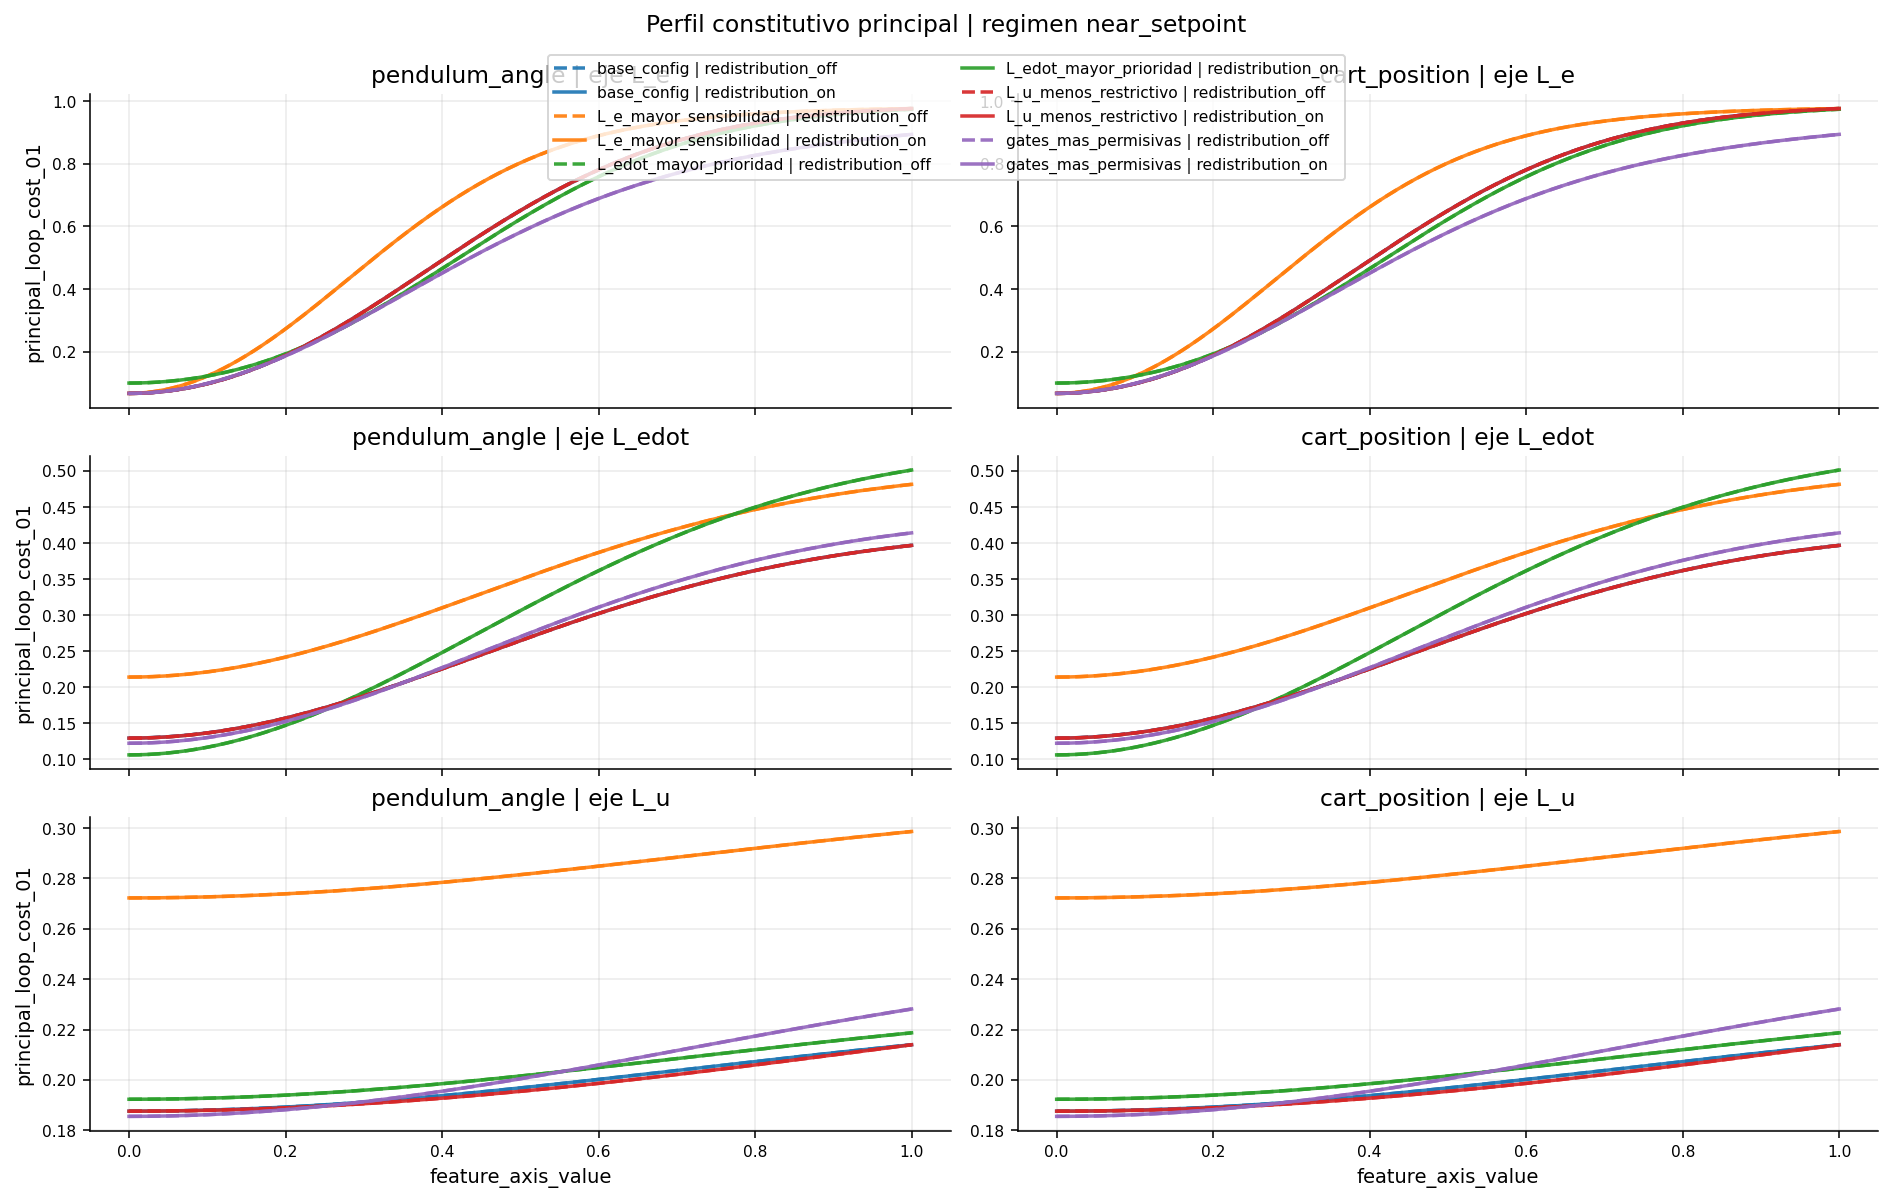

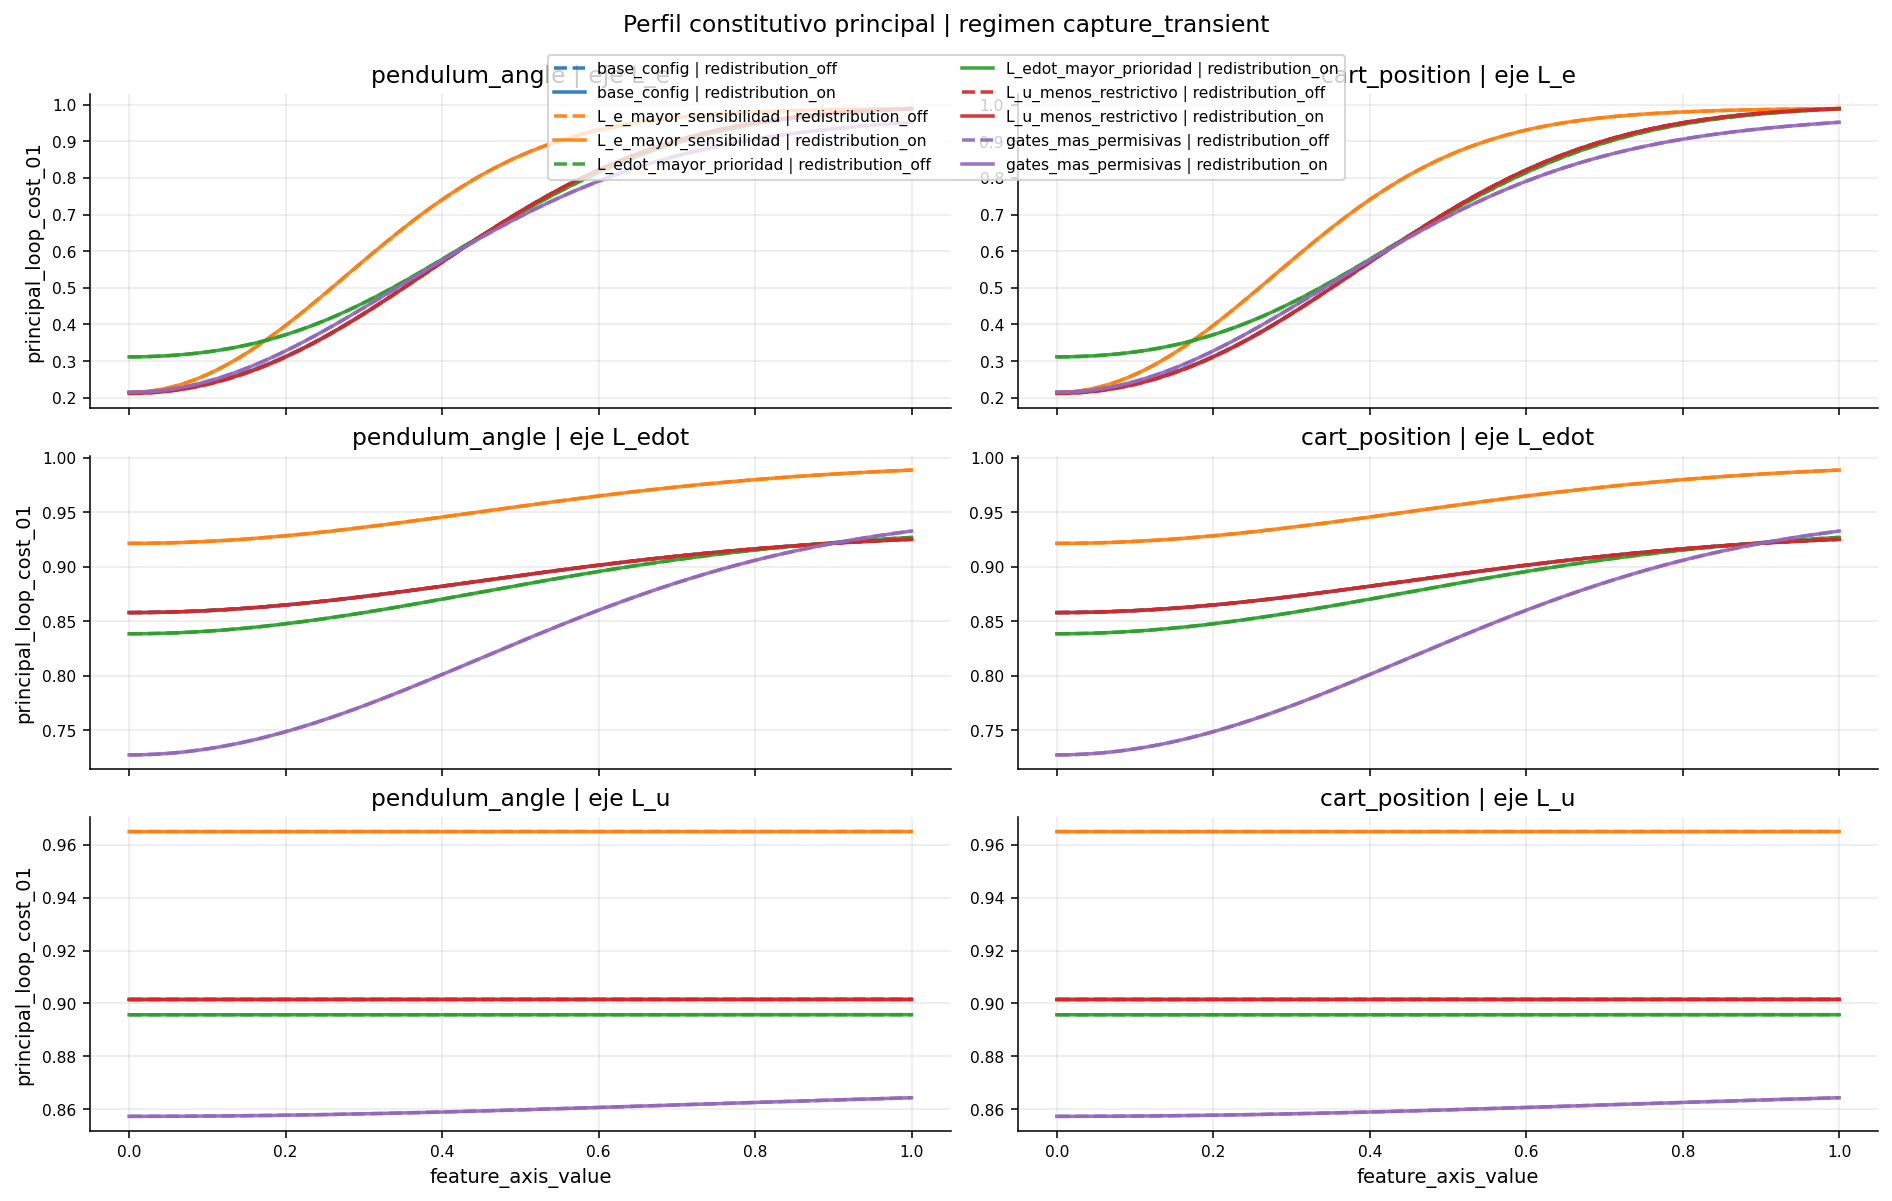

In [20]:
for section1_regime_name in section1_regimes_to_plot:
    fig, axes = section1_plot_constitutive_matrix(
        profiles_df=section1_profiles_df,
        physical_regime_name=section1_regime_name,
        var_objs=section1_var_objs,
        feature_axis_names=section1_feature_axis_names,
        scenario_names=list(section1_weighted_exponential_params_by_scenario.keys()),
        budget_modes=section1_budget_modes,
        profile_y_name=section1_profile_y_name,
    )
    save_figure(f"fig_01A_constitutive_matrix_{section1_regime_name}.png")
    plt.show()

### 1.6 Figura B: perfil de presupuesto y compuertas

Este grafico explica por que cambia la recompensa.

Paneles:

1. `principal_gate_<feature>_<var_obj>`
2. `principal_effective_weight_<feature>_<var_obj>`
3. `principal_weight_residual_<feature>_<var_obj>`
4. `-principal_contribution_<feature>_<var_obj>` como costo positivo

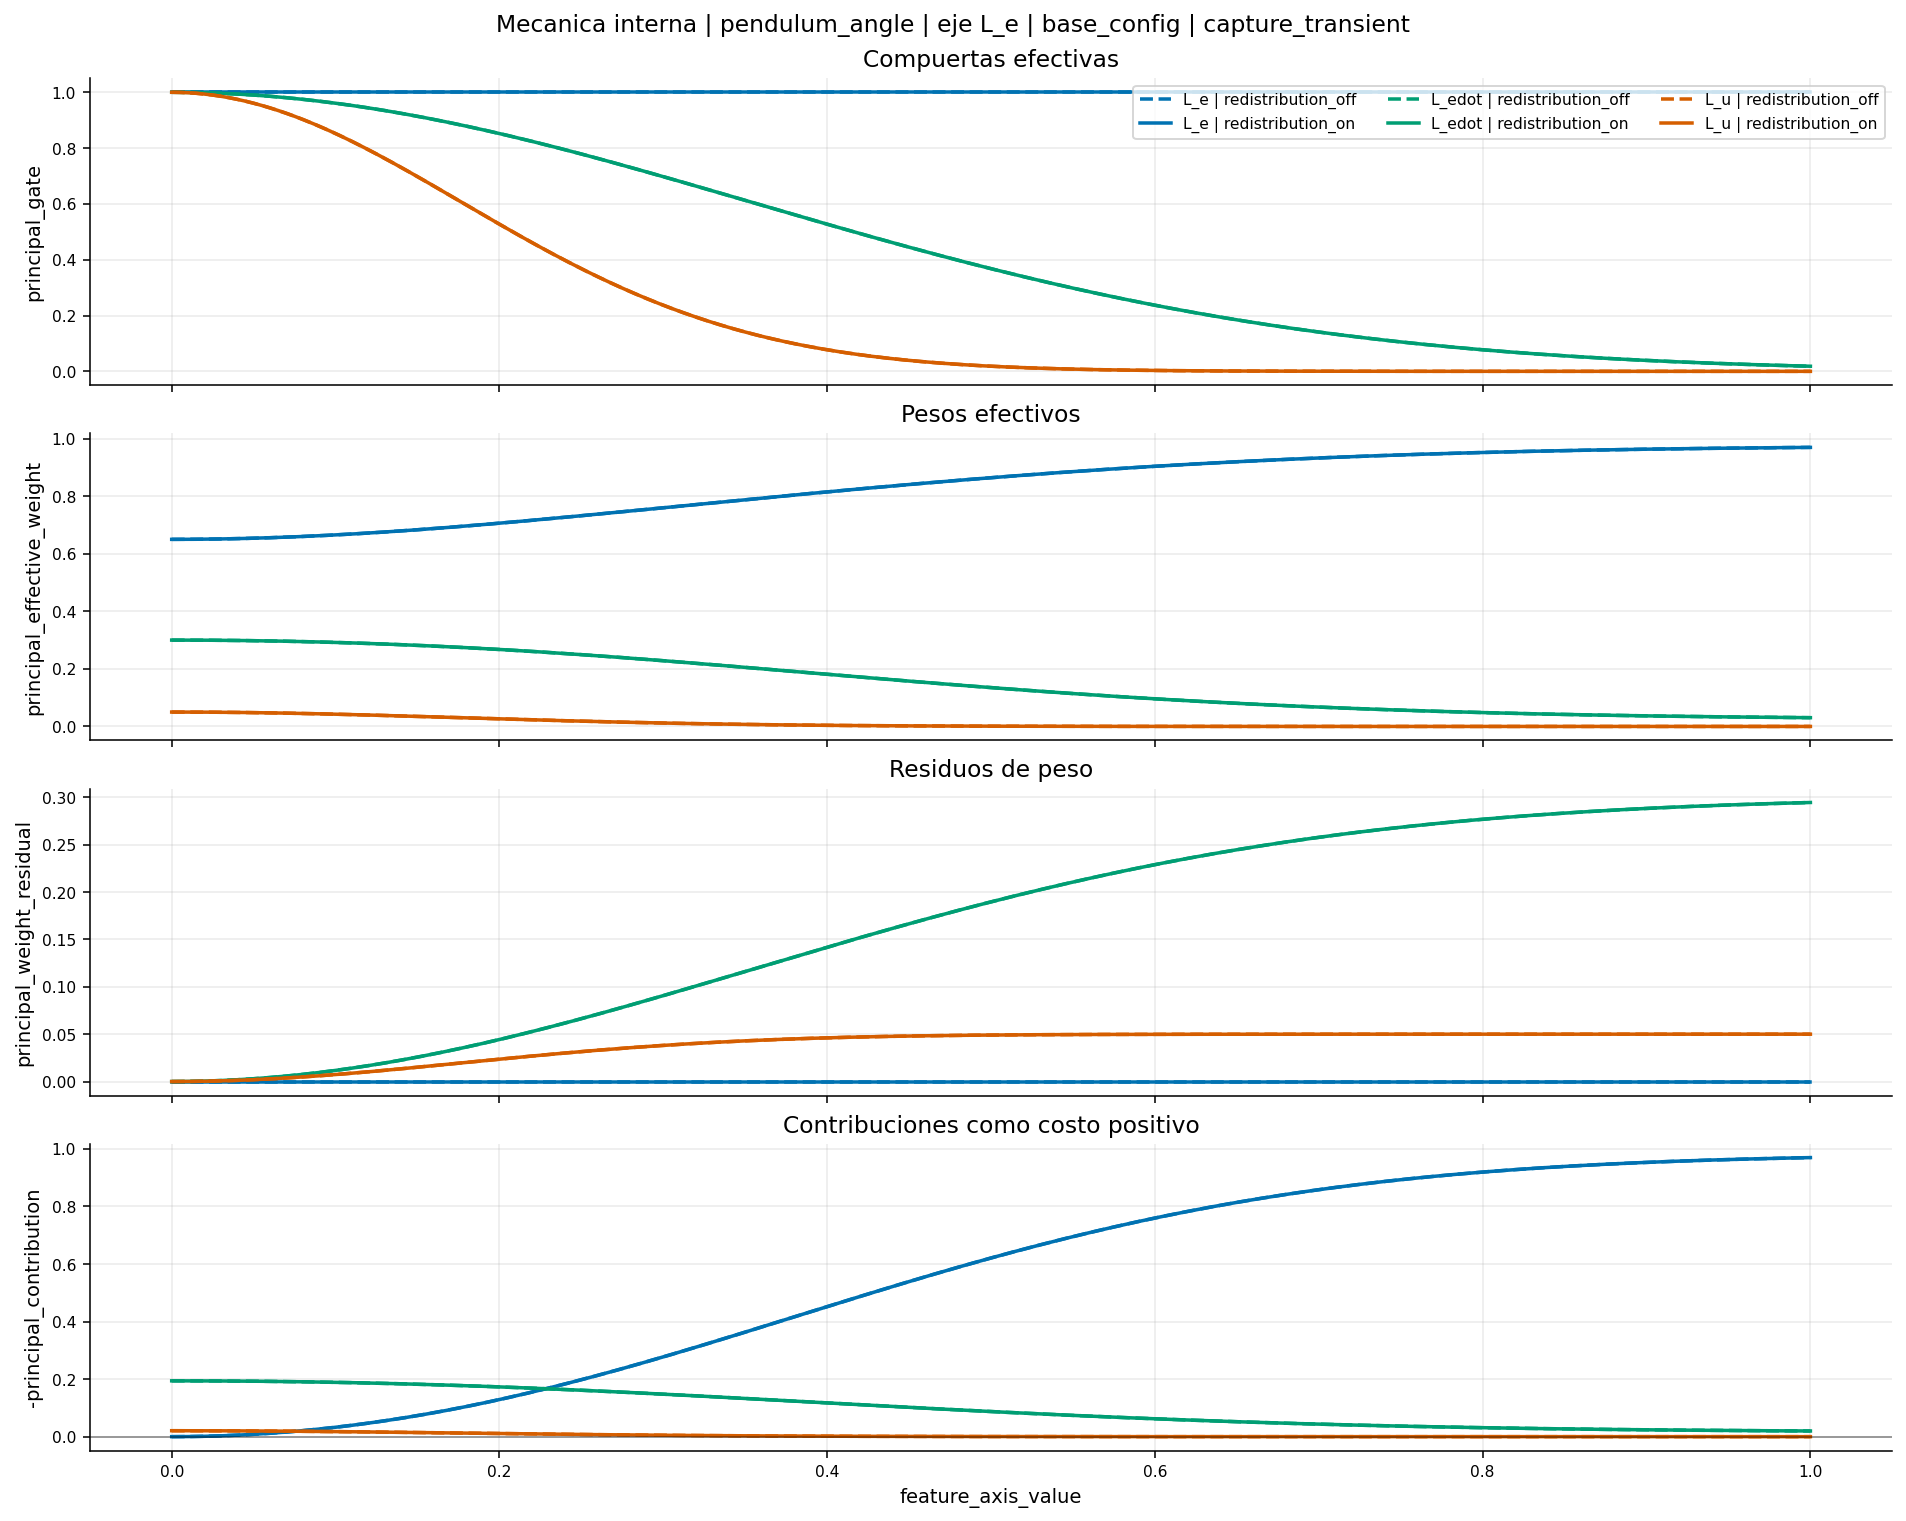

In [21]:
# ---------------------------------------------------------------------
# 1.6 Parametros editables del grafico interno de presupuesto
# ---------------------------------------------------------------------

section1_internal_var_obj = NAME_OBJECTIVE_VAR_FOCUS
section1_internal_feature_axis_name = "L_e"
section1_internal_physical_regime = "capture_transient"
section1_internal_scenario_name = "base_config"

fig, axes = section1_plot_internal_budget_profile(
    profiles_df=section1_profiles_df,
    physical_regime_name=section1_internal_physical_regime,
    var_obj=section1_internal_var_obj,
    feature_axis_name=section1_internal_feature_axis_name,
    scenario_name=section1_internal_scenario_name,
    feature_names=section1_feature_names,
    budget_modes=section1_budget_modes,
)
save_figure("fig_01B_budget_gate_profile.png")
plt.show()

### 1.7 Figura C: composicion de contribuciones por regimen fisico

Este resumen evita leer todas las curvas. Muestra que feature domina el costo en cada regimen fisico.

El eje y usa `-principal_contribution_<feature>_<var_obj>` para leerlo como costo positivo.

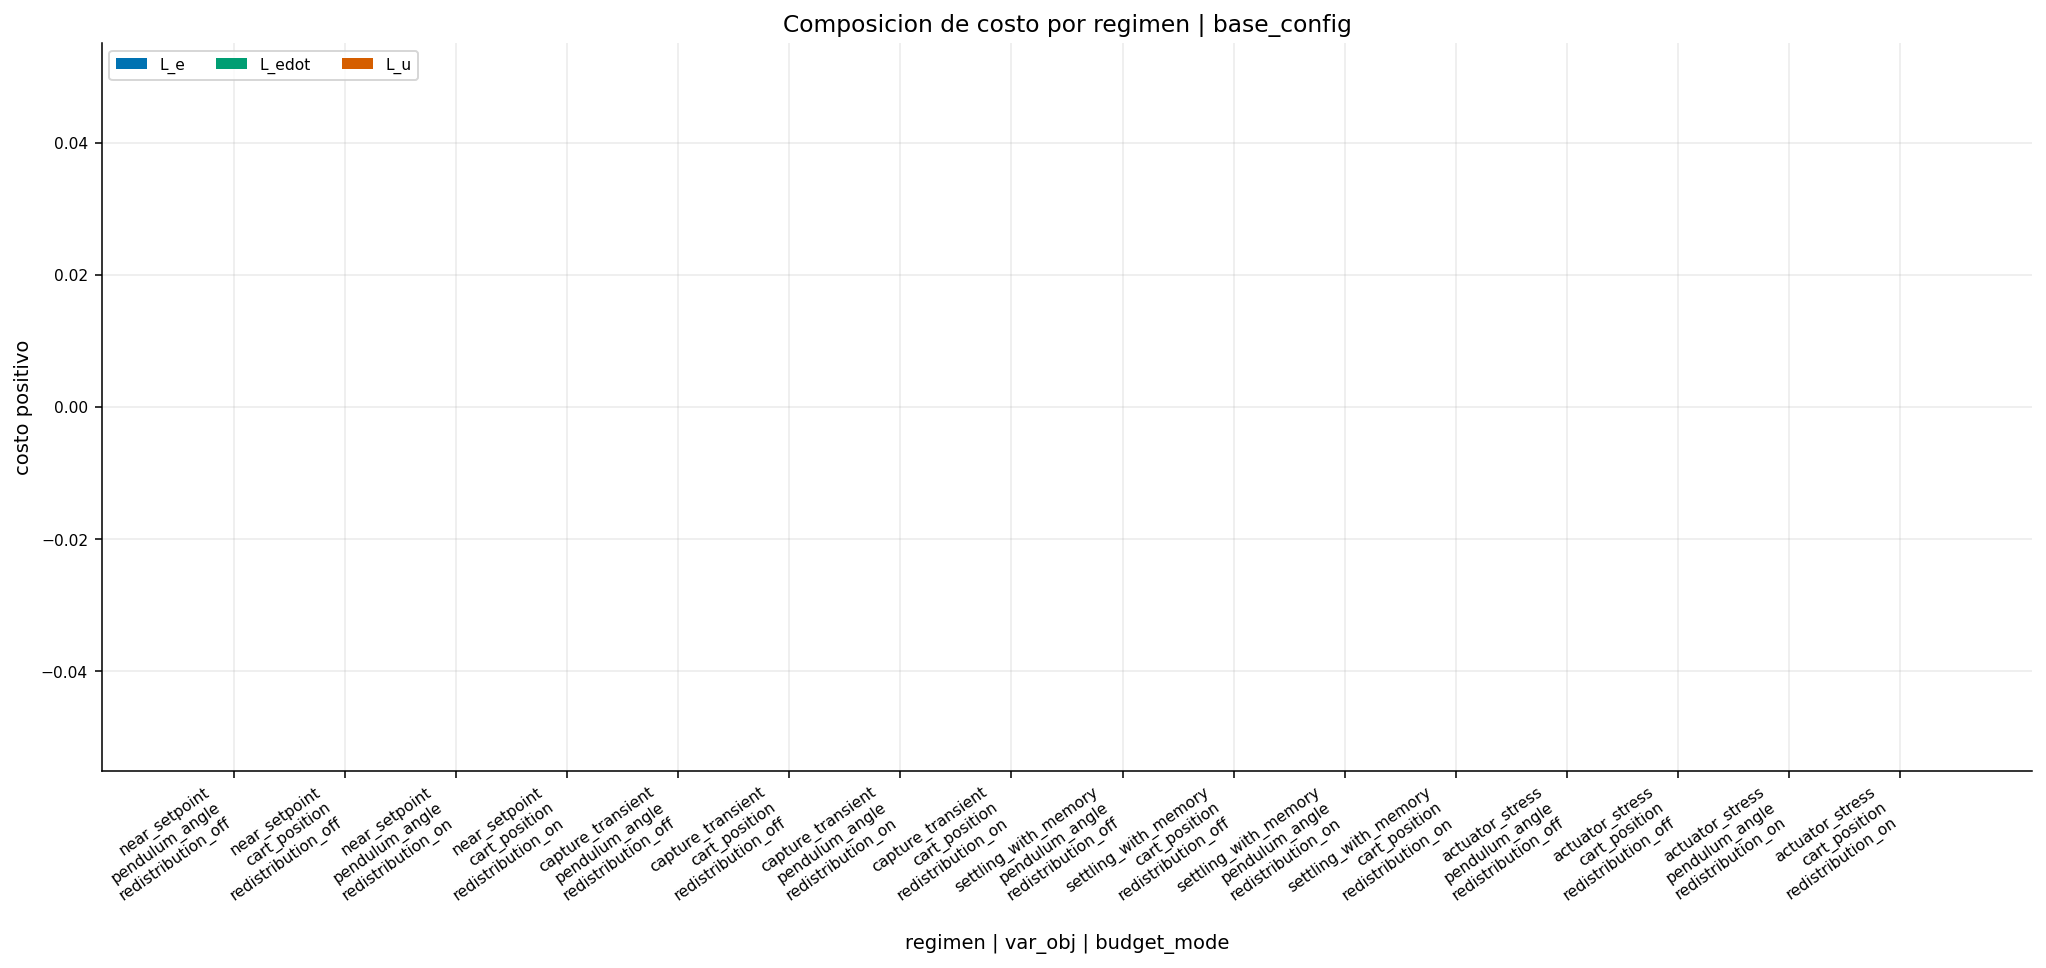

### Muestra del resumen por regimen

,physical_regime,scenario_name,budget_mode,var_obj,principal_loop_cost_01,principal_loop_reward,cost_positive_L_e,cost_positive_L_edot,cost_positive_L_u
0,near_setpoint,base_config,redistribution_off,pendulum_angle,0.0,-0.0,0.0,0.0,0.0
1,near_setpoint,base_config,redistribution_off,cart_position,0.0,-0.0,0.0,0.0,0.0
2,near_setpoint,base_config,redistribution_on,pendulum_angle,0.0,-0.0,0.0,0.0,0.0
3,near_setpoint,base_config,redistribution_on,cart_position,0.0,-0.0,0.0,0.0,0.0
4,near_setpoint,L_e_mayor_sensibilidad,redistribution_off,pendulum_angle,0.0,-0.0,0.0,0.0,0.0
5,near_setpoint,L_e_mayor_sensibilidad,redistribution_off,cart_position,0.0,-0.0,0.0,0.0,0.0
6,near_setpoint,L_e_mayor_sensibilidad,redistribution_on,pendulum_angle,0.0,-0.0,0.0,0.0,0.0
7,near_setpoint,L_e_mayor_sensibilidad,redistribution_on,cart_position,0.0,-0.0,0.0,0.0,0.0
8,near_setpoint,L_edot_mayor_prioridad,redistribution_off,pendulum_angle,0.0,-0.0,0.0,0.0,0.0
9,near_setpoint,L_edot_mayor_prioridad,redistribution_off,cart_position,0.0,-0.0,0.0,0.0,0.0


In [22]:
# ---------------------------------------------------------------------
# 1.7 Parametros editables del resumen por regimen
# ---------------------------------------------------------------------

section1_bar_scenario_name = "base_config"

fig, ax = section1_plot_regime_contribution_bars(
    regime_state_df=section1_regime_state_df,
    scenario_name=section1_bar_scenario_name,
    var_objs=section1_var_objs,
    budget_modes=section1_budget_modes,
    feature_names=section1_feature_names,
)
save_figure("fig_01C_regime_contribution_bars.png")
plt.show()

display(Markdown("### Muestra del resumen por regimen"))
section1_regime_display_cols = [
    "physical_regime",
    "scenario_name",
    "budget_mode",
    "var_obj",
    "principal_loop_cost_01",
    "principal_loop_reward",
    *[f"cost_positive_{feature_name}" for feature_name in section1_feature_names],
]
display(section1_regime_state_df[section1_regime_display_cols].head(12).round(5))

### 1.8 Figura D: mapa de sensibilidad para seleccionar configuracion

Metricas disponibles:

```python
# "area_cost"                    -> area bajo principal_loop_cost_01
# "slope_near_zero"              -> sensibilidad cerca de feature_axis_value ~= 0.05
# "slope_high"                   -> sensibilidad cerca de feature_axis_value ~= 0.80
# "max_effective_weight_shift"   -> maxima diferencia de peso efectivo entre redistribucion ON/OFF
```

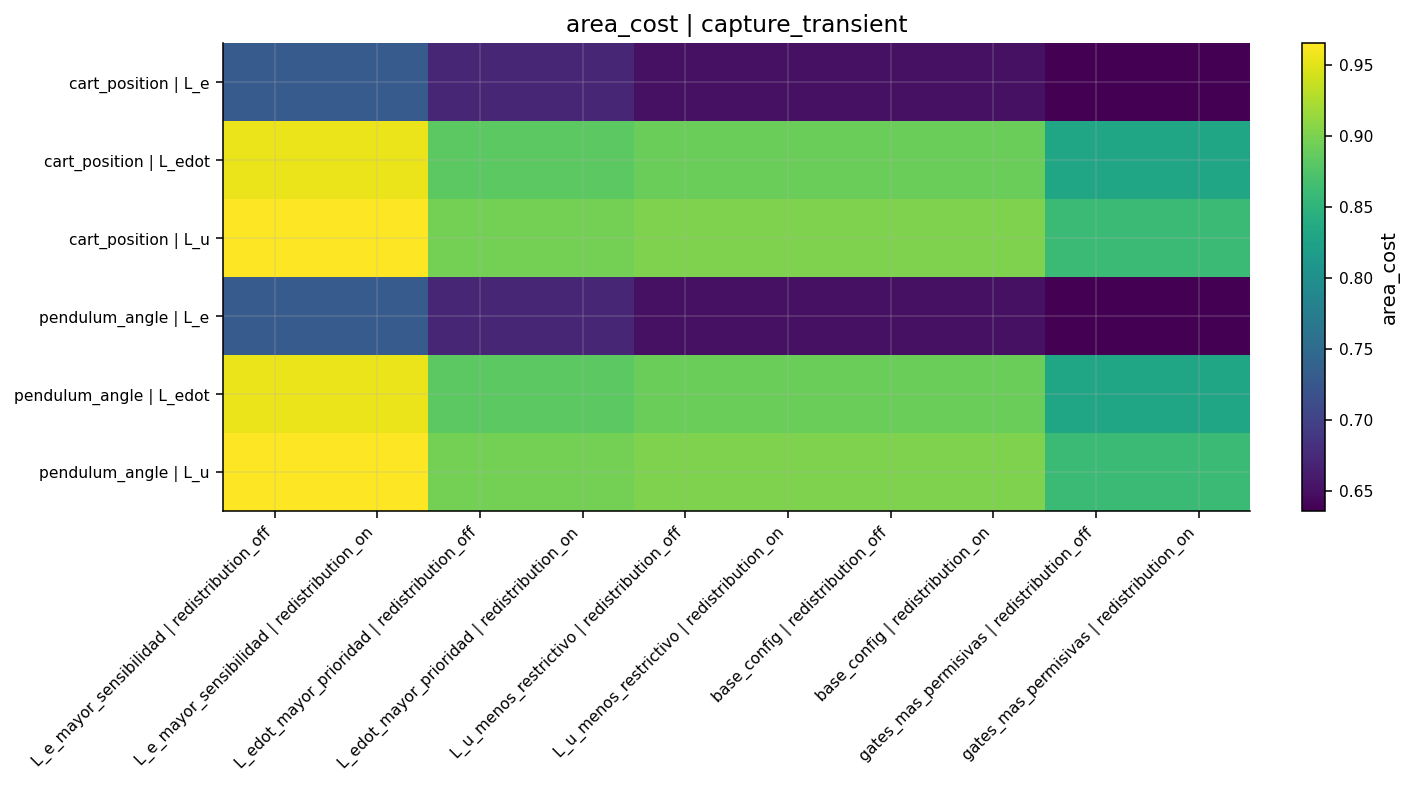

### Matriz usada en el heatmap

col_label,L_e_mayor_sensibilidad | redistribution_off,L_e_mayor_sensibilidad | redistribution_on,L_edot_mayor_prioridad | redistribution_off,L_edot_mayor_prioridad | redistribution_on,L_u_menos_restrictivo | redistribution_off,L_u_menos_restrictivo | redistribution_on,base_config | redistribution_off,base_config | redistribution_on,gates_mas_permisivas | redistribution_off,gates_mas_permisivas | redistribution_on
row_label,,,,,,,,,,
cart_position | L_e,0.73007,0.73007,0.67195,0.67195,0.65055,0.65055,0.65118,0.65118,0.63615,0.63615
cart_position | L_edot,0.95476,0.95476,0.88228,0.88228,0.89127,0.89127,0.89127,0.89127,0.82897,0.82897
cart_position | L_u,0.96499,0.96499,0.89573,0.89573,0.90151,0.90151,0.90151,0.90151,0.86013,0.86013
pendulum_angle | L_e,0.73007,0.73007,0.67195,0.67195,0.65055,0.65055,0.65118,0.65118,0.63615,0.63615
pendulum_angle | L_edot,0.95476,0.95476,0.88228,0.88228,0.89127,0.89127,0.89127,0.89127,0.82897,0.82897
pendulum_angle | L_u,0.96499,0.96499,0.89573,0.89573,0.90151,0.90151,0.90151,0.90151,0.86013,0.86013


In [23]:
# ---------------------------------------------------------------------
# 1.8 Parametros editables del heatmap de sensibilidad
# ---------------------------------------------------------------------

section1_sensitivity_physical_regime = "capture_transient"
section1_sensitivity_metric_name = "area_cost"

fig, ax, section1_sensitivity_matrix_df = section1_plot_sensitivity_heatmap(
    metrics_df=section1_sensitivity_df,
    physical_regime_name=section1_sensitivity_physical_regime,
    metric_name=section1_sensitivity_metric_name,
)
save_figure("fig_01D_sensitivity_heatmap.png")
plt.show()

display(Markdown("### Matriz usada en el heatmap"))
display(section1_sensitivity_matrix_df.round(5))

## 2. Bonus coordinativo puro

Objetivo: ver el comportamiento de la parte `R_coord`, antes de sumar progreso local y antes de restar deuda.

### Variables editables de esta seccion

| Variable | Significado |
|---|---|
| `coordination_reward_inputs_by_scenario.*.task_progress_delta_min/max` | Rango de `coordination_task_progress_delta = Phi(k-1)-Phi(k)`. |
| `coordination_reward_inputs_by_scenario.*.coordination_credit_raw_by_var` | Credito bruto `C_v` por lazo. Se transforma en `coordination_credit_share_<var_obj>`. |
| `coordination_reward_inputs_by_scenario.*.local_error_abs_by_var` | Valor de `abs(error_<var_obj>)` usado para calcular `coordination_error_decay_<var_obj>`. |
| `coordination_reward_config_by_scenario` | Copias editables de `coordination_reward`; aqui se modifican `coordination_bonus_clip`, `local_error_decay`, etc. |

In [24]:
# ---------------------------------------------------------------------
# 2.1 Parametros editables de coordination_reward: bonus puro
# ---------------------------------------------------------------------

coordination_reward_inputs_by_scenario = {
    "base_config": {
        "task_progress_delta_min": -0.02,
        "task_progress_delta_max": 0.05,
        "n_points": N_POINTS,
        "coordination_credit_raw_by_var": {
            "pendulum_angle": 0.35,
            "cart_position": 0.20,
        },
        "local_error_abs_by_var": {
            "pendulum_angle": 0.05,
            "cart_position": 0.05,
        },
    },
    "progreso_sin_clip": {
        "task_progress_delta_min": -0.02,
        "task_progress_delta_max": 0.05,
        "n_points": N_POINTS,
        "coordination_credit_raw_by_var": {
            "pendulum_angle": 0.35,
            "cart_position": 0.20,
        },
        "local_error_abs_by_var": {
            "pendulum_angle": 0.05,
            "cart_position": 0.05,
        },
    },
    "error_local_alto": {
        "task_progress_delta_min": -0.02,
        "task_progress_delta_max": 0.05,
        "n_points": N_POINTS,
        "coordination_credit_raw_by_var": {
            "pendulum_angle": 0.35,
            "cart_position": 0.20,
        },
        "local_error_abs_by_var": {
            "pendulum_angle": 0.30,
            "cart_position": 0.25,
        },
    },
}

coordination_reward_config_by_scenario = {
    "base_config": copy.deepcopy(coordination_reward_config_base),
    "progreso_sin_clip": copy.deepcopy(coordination_reward_config_base),
    "error_local_alto": copy.deepcopy(coordination_reward_config_base),
}

coordination_reward_config_by_scenario["progreso_sin_clip"]["coordination_bonus_clip"]["enabled"] = False
coordination_reward_config_by_scenario["error_local_alto"]["local_error_decay"]["method"] = "linear"

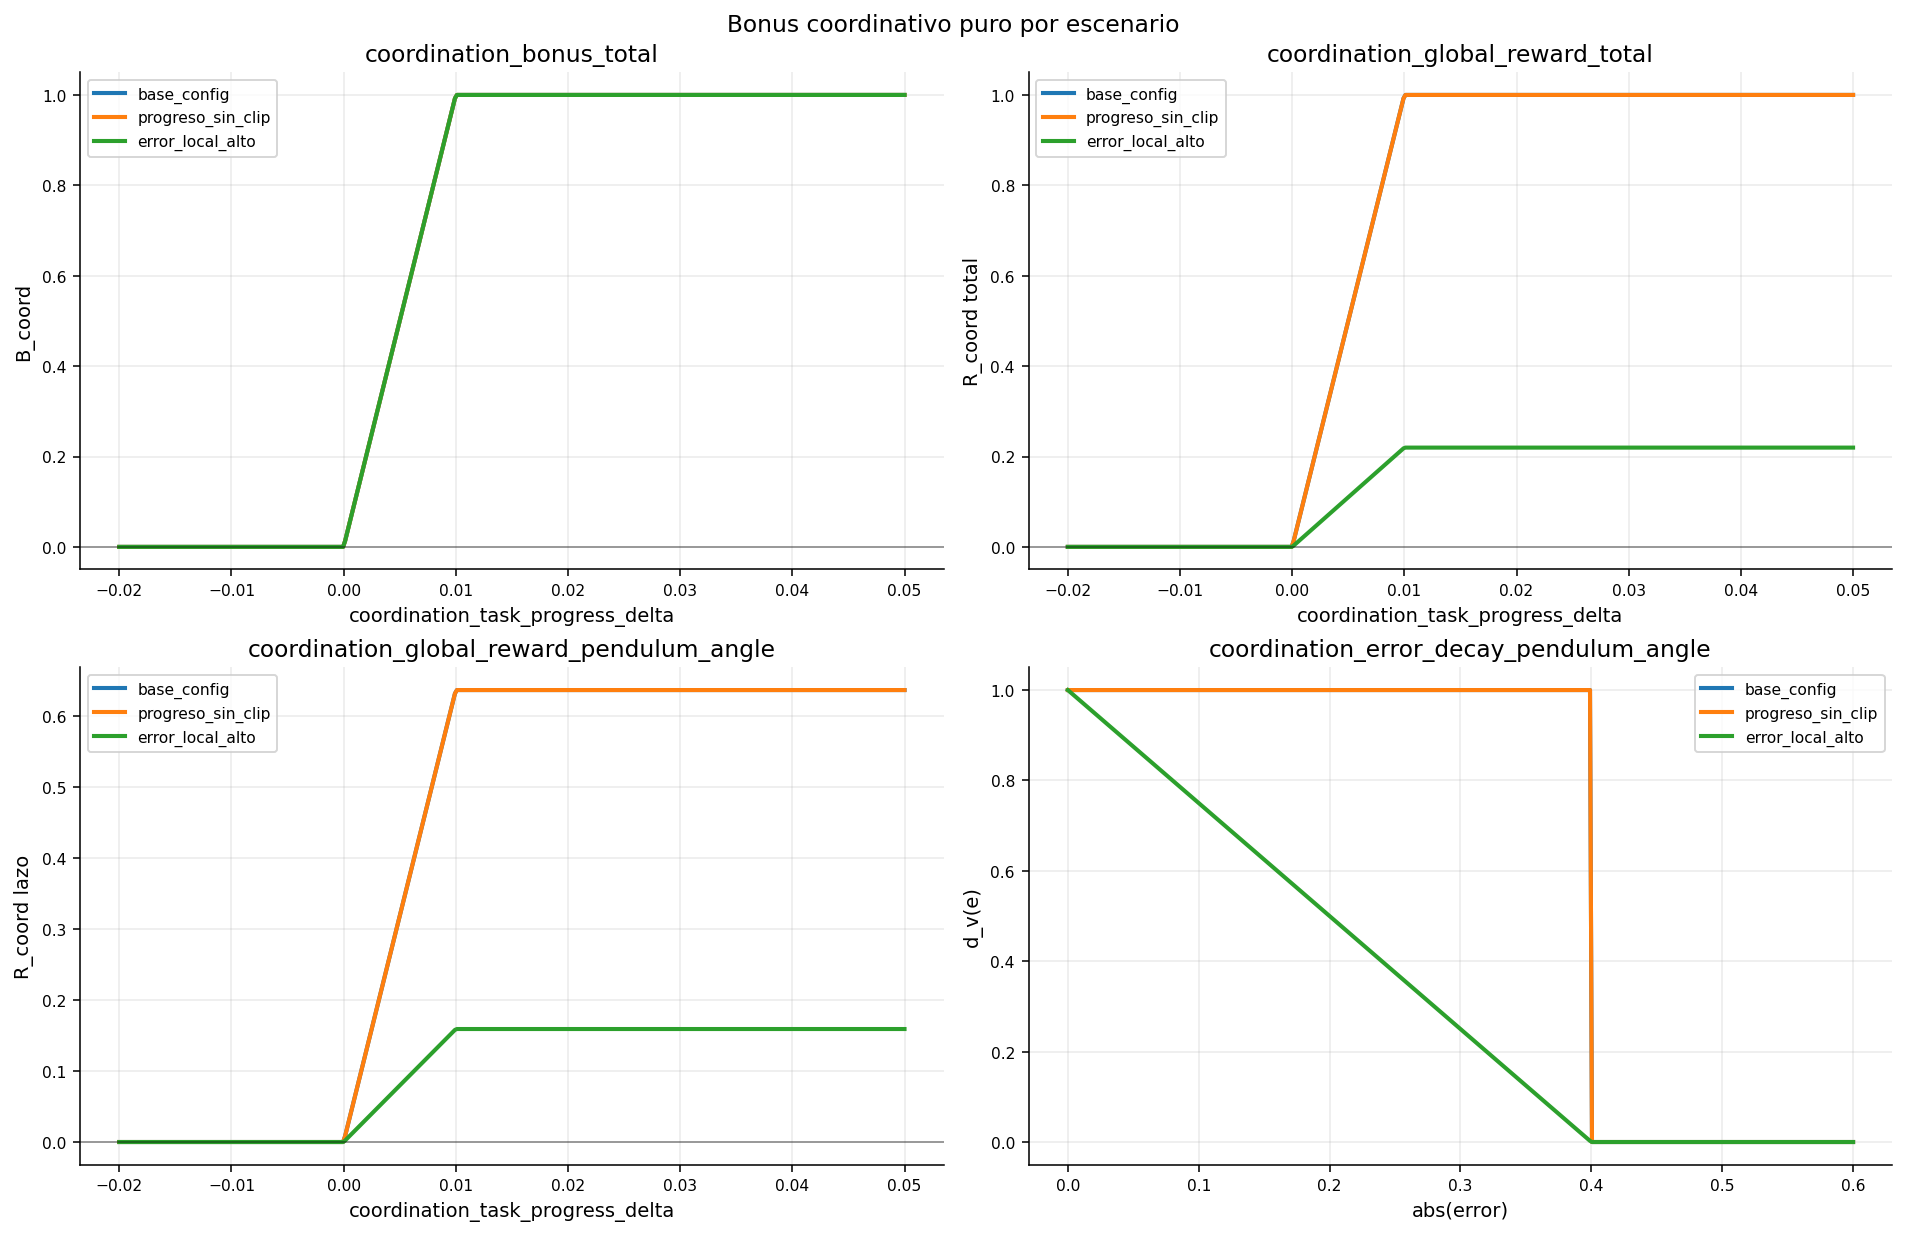

### Muestra de coordination_profile_df

,scenario_name,coordination_task_progress_delta,coordination_task_progress_positive,coordination_task_progress_01,coordination_bonus_total,coordination_credit_share_pendulum_angle,coordination_error_decay_pendulum_angle,coordination_global_reward_pendulum_angle,coordination_credit_share_cart_position,coordination_error_decay_cart_position,coordination_global_reward_cart_position,coordination_global_reward_total
0,base_config,-0.020,0.000,0.0,0.0,0.63636,1.00,0.00000,0.36364,1.00000,0.00000,0.0000
200,base_config,0.015,0.015,1.0,1.0,0.63636,1.00,0.63636,0.36364,1.00000,0.36364,1.0000
400,base_config,0.050,0.050,1.0,1.0,0.63636,1.00,0.63636,0.36364,1.00000,0.36364,1.0000
401,progreso_sin_clip,-0.020,0.000,0.0,0.0,0.63636,1.00,0.00000,0.36364,1.00000,0.00000,0.0000
601,progreso_sin_clip,0.015,0.015,1.0,1.0,0.63636,1.00,0.63636,0.36364,1.00000,0.36364,1.0000
801,progreso_sin_clip,0.050,0.050,1.0,1.0,0.63636,1.00,0.63636,0.36364,1.00000,0.36364,1.0000
802,error_local_alto,-0.020,0.000,0.0,0.0,0.63636,0.25,0.00000,0.36364,0.16667,0.00000,0.0000
1002,error_local_alto,0.015,0.015,1.0,1.0,0.63636,0.25,0.15909,0.36364,0.16667,0.06061,0.2197
1202,error_local_alto,0.050,0.050,1.0,1.0,0.63636,0.25,0.15909,0.36364,0.16667,0.06061,0.2197


In [25]:
coordination_profile_df = pd.concat(
    [
        build_coordination_reward_profile(
            scenario_name=scenario_name,
            scenario_inputs=coordination_reward_inputs_by_scenario[scenario_name],
            coordination_cfg=coordination_reward_config_by_scenario[scenario_name],
            var_objs=VAR_OBJS,
        )
        for scenario_name in coordination_reward_inputs_by_scenario.keys()
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.5))
axes = axes.ravel()

for idx, (scenario_name, frame) in enumerate(coordination_profile_df.groupby("scenario_name", sort=False)):
    color = scenario_color(idx)
    axes[0].plot(frame["coordination_task_progress_delta"], frame["coordination_bonus_total"], label=scenario_name, color=color, linewidth=2.1)
    axes[1].plot(frame["coordination_task_progress_delta"], frame["coordination_global_reward_total"], label=scenario_name, color=color, linewidth=2.1)
    axes[2].plot(
        frame["coordination_task_progress_delta"],
        frame[f"coordination_global_reward_{NAME_OBJECTIVE_VAR_FOCUS}"],
        label=scenario_name,
        color=color,
        linewidth=2.1,
    )

format_axis(axes[0], "coordination_bonus_total", "coordination_task_progress_delta", "B_coord", zero_line=True)
format_axis(axes[1], "coordination_global_reward_total", "coordination_task_progress_delta", "R_coord total", zero_line=True)
format_axis(axes[2], f"coordination_global_reward_{NAME_OBJECTIVE_VAR_FOCUS}", "coordination_task_progress_delta", "R_coord lazo", zero_line=True)

local_error_abs_axis = np.linspace(0.0, 0.60, N_POINTS)
for idx, (scenario_name, cfg) in enumerate(coordination_reward_config_by_scenario.items()):
    axes[3].plot(
        local_error_abs_axis,
        error_decay_curve(local_error_abs_axis, cfg, NAME_OBJECTIVE_VAR_FOCUS),
        label=scenario_name,
        color=scenario_color(idx),
        linewidth=2.1,
    )
format_axis(axes[3], f"coordination_error_decay_{NAME_OBJECTIVE_VAR_FOCUS}", "abs(error)", "d_v(e)")

for ax in axes:
    ax.legend(loc="best")

fig.suptitle("Bonus coordinativo puro por escenario", y=1.02)
save_figure("fig_02_coordination_reward_profile.png")
plt.show()

display(Markdown("### Muestra de coordination_profile_df"))
display(coordination_profile_df.groupby("scenario_name", sort=False).nth([0, 200, -1]).round(5))

## 3. Progreso local `R_progress`

Objetivo: observar cuando el modulo coordinativo premia el retorno local hacia el setpoint.

### Variables editables de esta seccion

| Variable | Significado |
|---|---|
| `local_progress_inputs_by_scenario.*.local_progress_delta_min/max` | Rango de `coordination_local_progress_delta_<var_obj>`. |
| `local_progress_inputs_by_scenario.*.coordination_task_progress_delta` | Mejora global usada si `condition_mode` depende del progreso global. |
| `local_progress_inputs_by_scenario.*.other_local_progress_delta_by_var` | Progreso de los otros lazos para condiciones tipo `all_local_progress_positive`. |
| `coordination_reward_config_for_local_progress.*.local_progress` | Copias editables de `coordination_reward.local_progress`. |

In [26]:
# ---------------------------------------------------------------------
# 3.1 Parametros editables de local_progress
# ---------------------------------------------------------------------

local_progress_inputs_by_scenario = {
    "always": {
        "local_progress_delta_min": -0.05,
        "local_progress_delta_max": 0.05,
        "n_points": N_POINTS,
        "coordination_task_progress_delta": 0.02,
        "other_local_progress_delta_by_var": {
            "pendulum_angle": 0.02,
            "cart_position": 0.02,
        },
    },
    "global_progress_positive": {
        "local_progress_delta_min": -0.05,
        "local_progress_delta_max": 0.05,
        "n_points": N_POINTS,
        "coordination_task_progress_delta": 0.02,
        "other_local_progress_delta_by_var": {
            "pendulum_angle": 0.02,
            "cart_position": 0.02,
        },
    },
    "global_progress_negative": {
        "local_progress_delta_min": -0.05,
        "local_progress_delta_max": 0.05,
        "n_points": N_POINTS,
        "coordination_task_progress_delta": -0.02,
        "other_local_progress_delta_by_var": {
            "pendulum_angle": 0.02,
            "cart_position": 0.02,
        },
    },
}

coordination_reward_config_for_local_progress = {
    scenario_name: copy.deepcopy(coordination_reward_config_base)
    for scenario_name in local_progress_inputs_by_scenario.keys()
}

coordination_reward_config_for_local_progress["always"]["local_progress"]["condition_mode"] = "always"
coordination_reward_config_for_local_progress["global_progress_positive"]["local_progress"]["condition_mode"] = "global_progress_positive"
coordination_reward_config_for_local_progress["global_progress_negative"]["local_progress"]["condition_mode"] = "global_progress_positive"

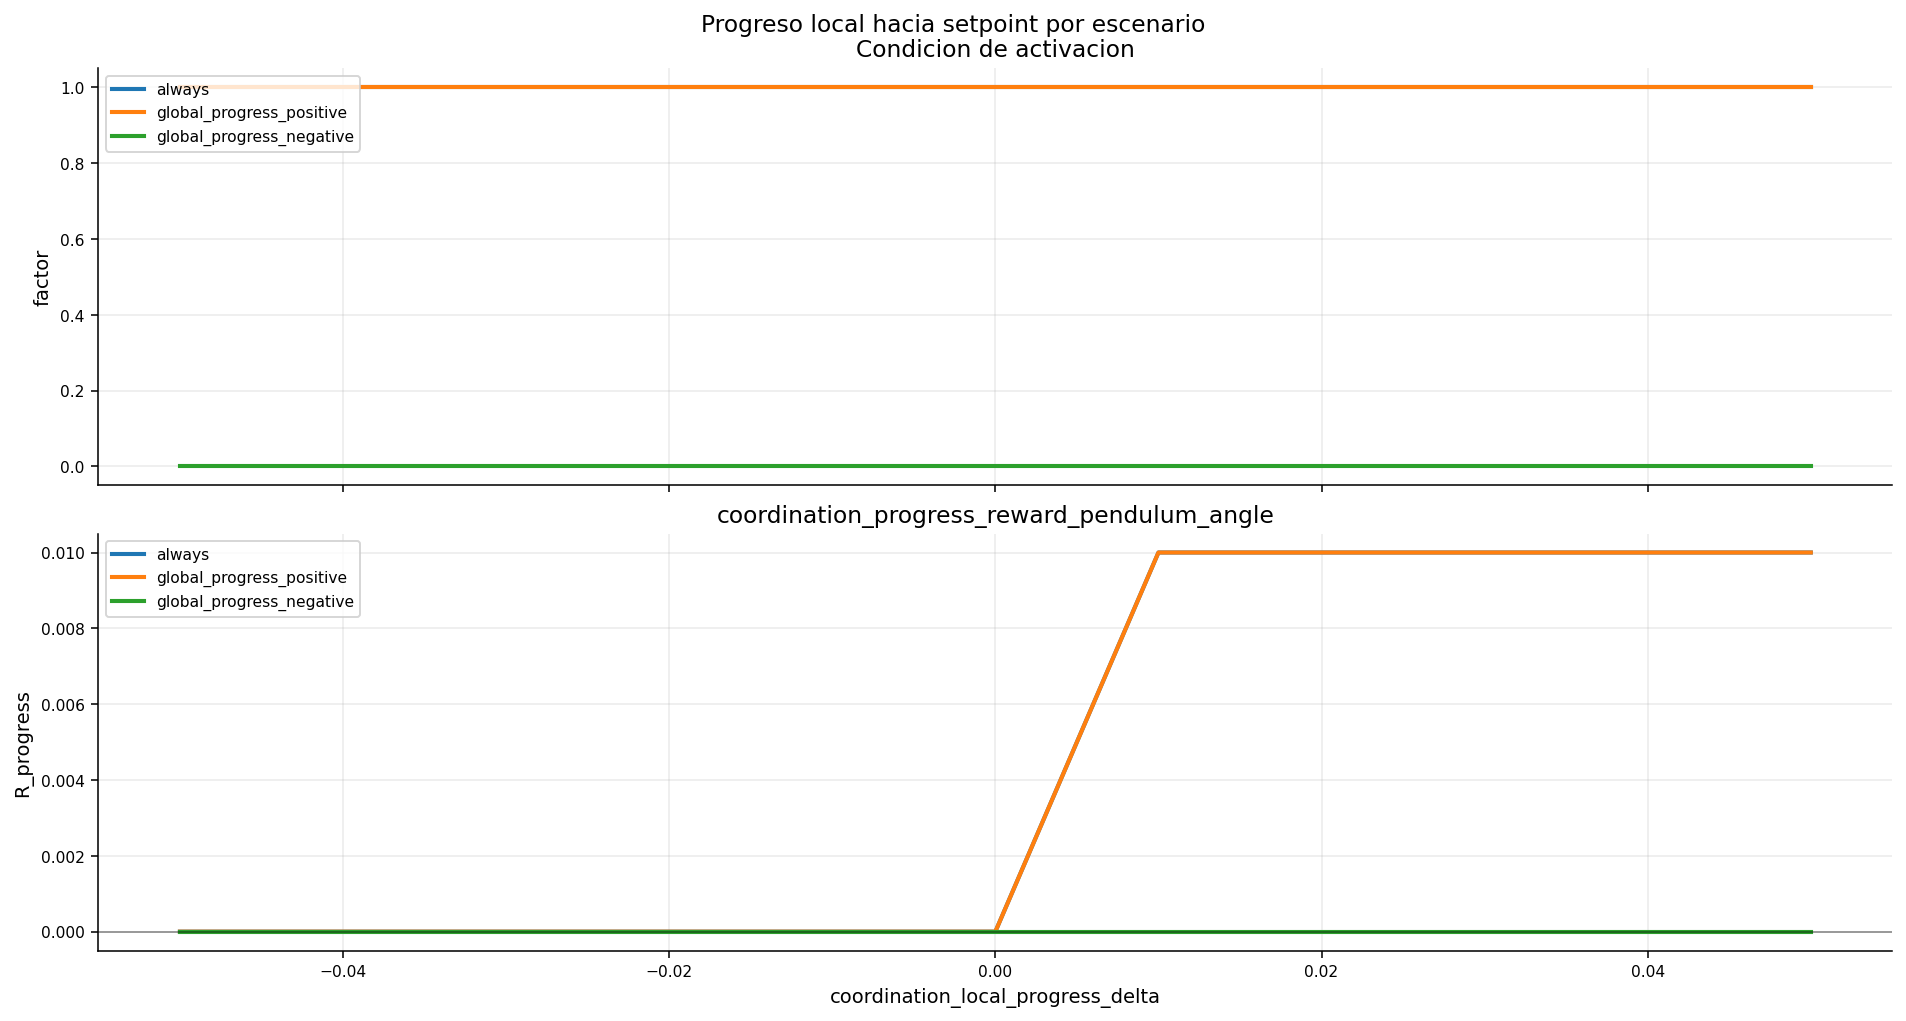

### Muestra de local_progress_profile_df

,scenario_name,coordination_local_progress_delta,coordination_progress_condition_pendulum_angle,coordination_progress_reward_pendulum_angle,coordination_progress_condition_cart_position,coordination_progress_reward_cart_position,coordination_progress_reward_total
0,always,-0.05,1.0,0.00,1.0,0.00,0.00
200,always,0.00,1.0,0.00,1.0,0.00,0.00
400,always,0.05,1.0,0.01,1.0,0.01,0.02
401,global_progress_positive,-0.05,1.0,0.00,1.0,0.00,0.00
601,global_progress_positive,0.00,1.0,0.00,1.0,0.00,0.00
801,global_progress_positive,0.05,1.0,0.01,1.0,0.01,0.02
802,global_progress_negative,-0.05,0.0,0.00,0.0,0.00,0.00
1002,global_progress_negative,0.00,0.0,0.00,0.0,0.00,0.00
1202,global_progress_negative,0.05,0.0,0.00,0.0,0.00,0.00


In [27]:
local_progress_profile_df = pd.concat(
    [
        build_local_progress_profile(
            scenario_name=scenario_name,
            scenario_inputs=local_progress_inputs_by_scenario[scenario_name],
            coordination_cfg=coordination_reward_config_for_local_progress[scenario_name],
            var_objs=VAR_OBJS,
        )
        for scenario_name in local_progress_inputs_by_scenario.keys()
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(2, 1, figsize=(13.5, 7.0), sharex=True)

for idx, (scenario_name, frame) in enumerate(local_progress_profile_df.groupby("scenario_name", sort=False)):
    color = scenario_color(idx)
    axes[0].plot(
        frame["coordination_local_progress_delta"],
        frame[f"coordination_progress_condition_{NAME_OBJECTIVE_VAR_FOCUS}"],
        label=scenario_name,
        color=color,
        linewidth=2.1,
    )
    axes[1].plot(
        frame["coordination_local_progress_delta"],
        frame[f"coordination_progress_reward_{NAME_OBJECTIVE_VAR_FOCUS}"],
        label=scenario_name,
        color=color,
        linewidth=2.1,
    )

format_axis(axes[0], "Condicion de activacion", ylabel="factor")
format_axis(axes[1], f"coordination_progress_reward_{NAME_OBJECTIVE_VAR_FOCUS}", "coordination_local_progress_delta", "R_progress", zero_line=True)
axes[0].legend(loc="upper left")
axes[1].legend(loc="upper left")

fig.suptitle("Progreso local hacia setpoint por escenario", y=1.02)
save_figure("fig_03_local_progress_profile.png")
plt.show()

display(Markdown("### Muestra de local_progress_profile_df"))
display(local_progress_profile_df.groupby("scenario_name", sort=False).nth([0, 200, -1]).round(5))

## 4. Deuda local `R_debt`

Objetivo: observar como `coordination_debt_<var_obj>` acumula memoria de desviacion y como se traduce en `coordination_debt_penalty_<var_obj>`.

### Variables editables de esta seccion

| Variable | Significado |
|---|---|
| `local_debt_potential_by_scenario` | Series de `coordination_local_potential_<var_obj>` usadas como escenarios de desviacion. |
| `coordination_reward_config_for_debt.*.local_debt.persistence` | Memoria temporal de la deuda. |
| `coordination_reward_config_for_debt.*.local_debt.penalty_weight` | Peso que convierte deuda en penalizacion. |
| `coordination_reward_config_for_debt.*.local_debt.clip_max` | Cota maxima de deuda acumulada si `clip_enabled` esta activo. |

In [ ]:
# ---------------------------------------------------------------------
# 4.1 Parametros editables de local_debt
# ---------------------------------------------------------------------

DEBT_N_INTERVALS = 90
debt_time_01 = np.linspace(0.0, 1.0, DEBT_N_INTERVALS)

local_debt_potential_by_scenario = {
    "desviacion_constante": np.full(DEBT_N_INTERVALS, 0.55),
    "recuperacion_lineal": np.linspace(0.65, 0.05, DEBT_N_INTERVALS),
    "sacrificio_y_retorno": 0.10 + 0.55 * np.exp(-((debt_time_01 - 0.25) / 0.18) ** 2),
}

coordination_reward_config_for_debt = {
    "desviacion_constante": copy.deepcopy(coordination_reward_config_base),
    "recuperacion_lineal": copy.deepcopy(coordination_reward_config_base),
    "sacrificio_y_retorno": copy.deepcopy(coordination_reward_config_base),
}

coordination_reward_config_for_debt["desviacion_constante"]["local_debt"]["persistence"] = 0.95
coordination_reward_config_for_debt["recuperacion_lineal"]["local_debt"]["persistence"] = 0.95
coordination_reward_config_for_debt["sacrificio_y_retorno"]["local_debt"]["persistence"] = 0.80

In [ ]:
debt_profile_df = pd.concat(
    [
        build_debt_profile(
            scenario_name=scenario_name,
            local_potential_values=local_debt_potential_by_scenario[scenario_name],
            coordination_cfg=coordination_reward_config_for_debt[scenario_name],
            name_objective_var=NAME_OBJECTIVE_VAR_FOCUS,
        )
        for scenario_name in local_debt_potential_by_scenario.keys()
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(3, 1, figsize=(13.5, 8.5), sharex=True)

for idx, (scenario_name, frame) in enumerate(debt_profile_df.groupby("scenario_name", sort=False)):
    color = scenario_color(idx)
    axes[0].plot(frame["interval_id"], frame["coordination_local_potential"], label=scenario_name, color=color, linewidth=2.0)
    axes[1].plot(frame["interval_id"], frame["coordination_debt"], label=scenario_name, color=color, linewidth=2.0)
    axes[2].plot(frame["interval_id"], frame["coordination_debt_penalty"], label=scenario_name, color=color, linewidth=2.0)

format_axis(axes[0], "coordination_local_potential usado como entrada", ylabel="Phi_local")
format_axis(axes[1], f"coordination_debt_{NAME_OBJECTIVE_VAR_FOCUS}", ylabel="D_v")
format_axis(axes[2], f"coordination_debt_penalty_{NAME_OBJECTIVE_VAR_FOCUS}", "intervalo", "R_debt", zero_line=True)
axes[0].legend(loc="upper right")

fig.suptitle("Deuda local acumulada por escenario", y=1.02)
save_figure("fig_04_local_debt_profile.png")
plt.show()

display(Markdown("### Ultimo valor por escenario"))
display(debt_profile_df.groupby("scenario_name", sort=False).tail(1).round(5))

## 5. Recompensa final sin extras

Objetivo: ver como los modulos anteriores se convierten en recompensa final usando `reward_composition.block_weights`.

No se usa `extra_rewards`.

### Variables editables de esta seccion

| Variable | Significado |
|---|---|
| `final_reward_scenario.principal_scenario_name` | Escenario de `weighted_exponential_params_by_scenario` usado como `principal_reward`. |
| `final_reward_scenario.coordination_scenario_name` | Escenario de bonus coordinativo puro. |
| `final_reward_scenario.local_progress_scenario_name` | Escenario de `R_progress`. |
| `final_reward_scenario.local_debt_scenario_name` | Escenario de `R_debt`. |
| `final_reward_block_weights` | Pesos de `reward_composition.block_weights`. Aqui `extra_rewards` se fuerza a 0. |

In [ ]:
# ---------------------------------------------------------------------
# 5.1 Parametros editables de reward_composition sin extra_rewards
# ---------------------------------------------------------------------

final_reward_scenario = {
    "name_objective_var": NAME_OBJECTIVE_VAR_FOCUS,
    "principal_scenario_name": "base_config",
    "coordination_scenario_name": "base_config",
    "local_progress_scenario_name": "global_progress_positive",
    "local_debt_scenario_name": "recuperacion_lineal",
    "bar_index_fraction": 0.65,
}

final_reward_block_weights = {
    "principal_reward": block_weights_base["principal_reward"],
    "coordination_reward": block_weights_base["coordination_reward"],
    "extra_rewards": 0.0,
}

In [ ]:
name_objective_var = final_reward_scenario["name_objective_var"]

principal_selected = principal_profile_df.loc[
    principal_profile_df["scenario_name"].eq(final_reward_scenario["principal_scenario_name"])
].reset_index(drop=True)
coordination_selected = coordination_profile_df.loc[
    coordination_profile_df["scenario_name"].eq(final_reward_scenario["coordination_scenario_name"])
].reset_index(drop=True)
progress_selected = local_progress_profile_df.loc[
    local_progress_profile_df["scenario_name"].eq(final_reward_scenario["local_progress_scenario_name"])
].reset_index(drop=True)
debt_selected = debt_profile_df.loc[
    debt_profile_df["scenario_name"].eq(final_reward_scenario["local_debt_scenario_name"])
].reset_index(drop=True)

n = len(principal_selected)
axis_01 = np.linspace(0.0, 1.0, n)
bar_idx = int(round(final_reward_scenario["bar_index_fraction"] * (n - 1)))

principal_reward = principal_selected["principal_reward"].to_numpy()
coordination_global_reward = coordination_selected[f"coordination_global_reward_{name_objective_var}"].to_numpy()
coordination_progress_reward = progress_selected[f"coordination_progress_reward_{name_objective_var}"].to_numpy()
coordination_debt_penalty = np.interp(
    axis_01,
    np.linspace(0.0, 1.0, len(debt_selected)),
    debt_selected["coordination_debt_penalty"].to_numpy(),
)

coordination_module_reward = coordination_global_reward + coordination_progress_reward - coordination_debt_penalty
reward_weighted_principal_reward = final_reward_block_weights["principal_reward"] * principal_reward
reward_weighted_coordination_reward = final_reward_block_weights["coordination_reward"] * coordination_module_reward
final_reward_no_extras = reward_weighted_principal_reward + reward_weighted_coordination_reward

final_reward_profile_df = pd.DataFrame({
    "axis_01": axis_01,
    "principal_reward": principal_reward,
    f"coordination_global_reward_{name_objective_var}": coordination_global_reward,
    f"coordination_progress_reward_{name_objective_var}": coordination_progress_reward,
    f"coordination_debt_penalty_{name_objective_var}": coordination_debt_penalty,
    f"coordination_module_reward_{name_objective_var}": coordination_module_reward,
    "reward_weighted_principal_reward": reward_weighted_principal_reward,
    "reward_weighted_coordination_reward": reward_weighted_coordination_reward,
    "final_reward_no_extras": final_reward_no_extras,
})

fig, axes = plt.subplots(3, 1, figsize=(13.5, 10.0), sharex=True)

axes[0].plot(axis_01, principal_reward, label="principal_reward", color=COLORS["principal"], linewidth=2.3)
axes[0].plot(axis_01, coordination_global_reward, label="coordination_global_reward", color=COLORS["coordination"], linewidth=2.0)
axes[0].plot(axis_01, coordination_progress_reward, label="coordination_progress_reward", color=COLORS["progress"], linewidth=2.0)
axes[0].plot(axis_01, -coordination_debt_penalty, label="-coordination_debt_penalty", color=COLORS["debt"], linewidth=2.0)
axes[0].plot(axis_01, coordination_module_reward, label="coordination_module_reward", color=COLORS["module"], linewidth=2.5)
format_axis(axes[0], "Modulos raw", ylabel="reward raw", zero_line=True)
axes[0].legend(ncol=3, loc="lower left")

axes[1].plot(axis_01, reward_weighted_principal_reward, label="reward_weighted_principal_reward", color=COLORS["principal"], linewidth=2.2)
axes[1].plot(axis_01, reward_weighted_coordination_reward, label="reward_weighted_coordination_reward", color=COLORS["module"], linewidth=2.2)
axes[1].plot(axis_01, final_reward_no_extras, label="final_reward_no_extras", color=COLORS["final"], linewidth=2.8)
format_axis(axes[1], "Composicion ponderada sin extras", ylabel="reward ponderada", zero_line=True)
axes[1].legend(loc="lower left")

bar_values = pd.Series({
    "w_principal * principal": reward_weighted_principal_reward[bar_idx],
    "w_coord * coordination_global": final_reward_block_weights["coordination_reward"] * coordination_global_reward[bar_idx],
    "w_coord * progress": final_reward_block_weights["coordination_reward"] * coordination_progress_reward[bar_idx],
    "w_coord * -debt": -final_reward_block_weights["coordination_reward"] * coordination_debt_penalty[bar_idx],
    "final": final_reward_no_extras[bar_idx],
})
axes[2].bar(
    bar_values.index,
    bar_values.values,
    color=[COLORS["principal"], COLORS["coordination"], COLORS["progress"], COLORS["debt"], COLORS["final"]],
)
format_axis(axes[2], f"Corte interpretativo en axis_01={axis_01[bar_idx]:.2f}", "componente", "valor", zero_line=True)
axes[2].tick_params(axis="x", rotation=20)

fig.suptitle("Reconstruccion de recompensa final sin extra_rewards", y=1.02)
save_figure("fig_05_final_reward_composition.png")
plt.show()

display(Markdown("### Muestra de final_reward_profile_df"))
display(final_reward_profile_df.iloc[[0, bar_idx, -1]].round(5))

## 6. Superficie de respuesta final

Objetivo: observar sensibilidad conjunta entre una feature de recompensa principal y el progreso global coordinativo.

### Variables editables de esta seccion

| Variable | Significado |
|---|---|
| `final_reward_surface.principal_feature_axis_name` | Feature principal del eje x. |
| `final_reward_surface.coordination_task_progress_delta_min/max` | Rango del eje y para progreso global. |
| `final_reward_surface.fixed_coordination_progress_reward` | Valor fijo de `coordination_progress_reward_<var_obj>`. |
| `final_reward_surface.fixed_coordination_debt_penalty` | Valor fijo de `coordination_debt_penalty_<var_obj>`. |
| `final_reward_surface.fixed_local_error_abs` | Error local usado para `coordination_error_decay_<var_obj>`. |

In [ ]:
# ---------------------------------------------------------------------
# 6.1 Parametros editables de superficie final
# ---------------------------------------------------------------------

final_reward_surface = {
    "name_objective_var": NAME_OBJECTIVE_VAR_FOCUS,
    "principal_feature_axis_name": "L_e",
    "principal_feature_axis_min": 0.0,
    "principal_feature_axis_max": 1.0,
    "coordination_task_progress_delta_min": -0.02,
    "coordination_task_progress_delta_max": 0.05,
    "fixed_coordination_progress_reward": 0.004,
    "fixed_coordination_debt_penalty": 0.020,
    "fixed_local_error_abs": 0.05,
    "coordination_credit_raw_by_var": {
        "pendulum_angle": 0.35,
        "cart_position": 0.20,
    },
    "n_x": 220,
    "n_y": 220,
}

In [ ]:
x_feature = np.linspace(
    final_reward_surface["principal_feature_axis_min"],
    final_reward_surface["principal_feature_axis_max"],
    final_reward_surface["n_x"],
)
y_progress = np.linspace(
    final_reward_surface["coordination_task_progress_delta_min"],
    final_reward_surface["coordination_task_progress_delta_max"],
    final_reward_surface["n_y"],
)

surface_axis = copy.deepcopy(principal_reward_profile_axis)
surface_axis["name_objective_var"] = final_reward_surface["name_objective_var"]
surface_axis["feature_axis_name"] = final_reward_surface["principal_feature_axis_name"]
surface_axis["feature_axis_min"] = final_reward_surface["principal_feature_axis_min"]
surface_axis["feature_axis_max"] = final_reward_surface["principal_feature_axis_max"]
surface_axis["n_points"] = final_reward_surface["n_x"]

principal_surface_line = build_principal_reward_profile(
    scenario_name="surface",
    profile_axis=surface_axis,
    weighted_exponential_params=weighted_exponential_params_by_scenario[final_reward_scenario["principal_scenario_name"]],
    normalized_reward_mode=principal_reward_config["normalized_reward_mode"],
)["principal_reward"].to_numpy()

_, _, bonus_surface = coordination_progress_components(
    y_progress,
    coordination_reward_config_by_scenario[final_reward_scenario["coordination_scenario_name"]],
)
share_surface = credit_share_from_raw(
    final_reward_surface["coordination_credit_raw_by_var"],
    coordination_reward_config_by_scenario[final_reward_scenario["coordination_scenario_name"]],
    VAR_OBJS,
)
decay_surface = float(error_decay_curve(
    [final_reward_surface["fixed_local_error_abs"]],
    coordination_reward_config_by_scenario[final_reward_scenario["coordination_scenario_name"]],
    final_reward_surface["name_objective_var"],
)[0])

coordination_global_surface_line = share_surface[final_reward_surface["name_objective_var"]] * bonus_surface * decay_surface
coordination_module_surface_line = (
    coordination_global_surface_line
    + final_reward_surface["fixed_coordination_progress_reward"]
    - final_reward_surface["fixed_coordination_debt_penalty"]
)

Z = (
    final_reward_block_weights["principal_reward"] * principal_surface_line[None, :]
    + final_reward_block_weights["coordination_reward"] * coordination_module_surface_line[:, None]
)

fig, ax = plt.subplots(figsize=(13.5, 7.5))
mesh = ax.pcolormesh(x_feature, y_progress, Z, shading="auto", cmap="coolwarm")
contours = ax.contour(x_feature, y_progress, Z, levels=12, colors="black", linewidths=0.45, alpha=0.45)
ax.clabel(contours, inline=True, fontsize=7, fmt="%.2f")
ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.55)
format_axis(
    ax,
    title=f"Superficie final sin extras | {final_reward_surface['name_objective_var']}",
    xlabel=final_reward_surface["principal_feature_axis_name"],
    ylabel="coordination_task_progress_delta",
)
fig.colorbar(mesh, ax=ax, label="final_reward_no_extras")
save_figure("fig_06_final_reward_surface.png")
plt.show()

display(Markdown("### Resumen de superficie"))
display(pd.DataFrame([
    {"metric": "final_reward_min", "value": float(np.min(Z))},
    {"metric": "final_reward_median", "value": float(np.median(Z))},
    {"metric": "final_reward_max", "value": float(np.max(Z))},
    {"metric": "positive_region_ratio", "value": float(np.mean(Z > 0.0))},
]).round(5))

## 7. Consistencia algebraica

Estas identidades deben permanecer en cero numerico. Sirven para comprobar que la figura final respeta la descomposicion del sistema.

In [ ]:
consistency_df = pd.DataFrame([
    {
        "identity": "coordination_module_reward = coordination_global_reward + coordination_progress_reward - coordination_debt_penalty",
        "max_abs_error": float(np.max(np.abs(
            final_reward_profile_df[f"coordination_module_reward_{final_reward_scenario['name_objective_var']}"]
            - (
                final_reward_profile_df[f"coordination_global_reward_{final_reward_scenario['name_objective_var']}"]
                + final_reward_profile_df[f"coordination_progress_reward_{final_reward_scenario['name_objective_var']}"]
                - final_reward_profile_df[f"coordination_debt_penalty_{final_reward_scenario['name_objective_var']}"]
            )
        ))),
    },
    {
        "identity": "final_reward_no_extras = reward_weighted_principal_reward + reward_weighted_coordination_reward",
        "max_abs_error": float(np.max(np.abs(
            final_reward_profile_df["final_reward_no_extras"]
            - (
                final_reward_profile_df["reward_weighted_principal_reward"]
                + final_reward_profile_df["reward_weighted_coordination_reward"]
            )
        ))),
    },
])

display(consistency_df)